#CONNECT GOOGLE DRIVE

In [ ]:
# CONNECT GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#IMPORT LIBRARIES

In [ ]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("ENVIRONMENT SETUP COMPLETED")

print(f"Random Seed : {SEED}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")

ENVIRONMENT SETUP COMPLETED
Random Seed : 42
NumPy       : 2.1.3
Pandas      : 2.2.3


#LOAD DATASET

In [ ]:
# LOAD DATASET

base_path = "/content/drive/MyDrive/Anxiety_Dataset"


#DATASET FILE DISCOVERY

In [ ]:
print("SEARCHING FOR DATASET FILES")

if not os.path.exists(base_path):
    print(f"ERROR: Dataset path does not exist:")
    print(base_path)
else:
    print(f"Dataset path found:")
    print(base_path)

    print("\nFiles and folders:")

    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, "").count(os.sep)
        indent = "    " * level

        print(f"{indent}{os.path.basename(root)}/")

        for file in files:
            print(f"{indent}    └── {file}")

SEARCHING FOR DATASET FILES
Dataset path found:
/content/drive/MyDrive/Anxiety_Dataset

Files and folders:
Anxiety_Dataset/
    └── demographic.csv
    └── gad7.csv
    └── isi.csv
    └── phq9.csv
    └── pss.csv
    └── leakage_safe_preprocessor.pkl
    └── master_mental_health_dataset.csv
    └── baseline_logistic_anxiety.pkl
    └── baseline_logistic_depression.pkl
    └── final_model_test_results.csv


# Automatically identify CSV files

In [ ]:
csv_files = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV FILES FOUND")

if len(csv_files) == 0:
    print("No CSV files found.")
else:
    for i, file_path in enumerate(csv_files, 1):
        size_mb = os.path.getsize(file_path) / (1024 ** 2)

        print(f"{i}. {os.path.basename(file_path)}")
        print(f"   Path : {file_path}")
        print(f"   Size : {size_mb:.2f} MB")

print(f"\nTotal CSV files: {len(csv_files)}")

CSV FILES FOUND
1. demographic.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/demographic.csv
   Size : 1.72 MB
2. gad7.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/gad7.csv
   Size : 1.31 MB
3. isi.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/isi.csv
   Size : 1.31 MB
4. phq9.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/phq9.csv
   Size : 1.64 MB
5. pss.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/pss.csv
   Size : 2.47 MB
6. master_mental_health_dataset.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/master_mental_health_dataset.csv
   Size : 3.62 MB
7. final_model_test_results.csv
   Path : /content/drive/MyDrive/Anxiety_Dataset/final_model_test_results.csv
   Size : 0.00 MB

Total CSV files: 7


# DATASET STRUCTURE INSPECTION

In [ ]:
print("DATASET STRUCTURE")

dataset_info = []

for file_path in csv_files:

    file_name = os.path.basename(file_path)

    try:
        df_temp = pd.read_csv(file_path)

        dataset_info.append({
            "File": file_name,
            "Rows": df_temp.shape[0],
            "Columns": df_temp.shape[1],
            "Missing Values": int(df_temp.isna().sum().sum())
        })

        print(f"FILE: {file_name}")

        print(f"Rows    : {df_temp.shape[0]:,}")
        print(f"Columns : {df_temp.shape[1]:,}")

        print("\nColumns:")
        print(df_temp.columns.tolist())

        print("\nFirst 3 rows:")
        display(df_temp.head(3))

    except Exception as e:
        print(f"Could not read {file_name}")
        print("Error:", e)

dataset_info_df = pd.DataFrame(dataset_info)

print("SUMMARY")

display(dataset_info_df)

DATASET STRUCTURE
FILE: demographic.csv
Rows    : 24,292
Columns : 6

Columns:
['export_id', 'gender', 'age', 'edu', 'smoke', 'drink']

First 3 rows:


,export_id,gender,age,edu,smoke,drink
0,61793,female,19.0,bachelor's degree,never smokes,never drinks
1,61809,female,18.0,bachelor's degree,never smokes,never drinks
2,61737,male,40.0,master's degree,never smokes,drinks occasionally (less than once a week)


FILE: gad7.csv
Rows    : 24,292
Columns : 16

Columns:
['export_id', 'score', 'question1', 'time1', 'question2', 'time2', 'question3', 'time3', 'question4', 'time4', 'question5', 'time5', 'question6', 'time6', 'question7', 'time7']

First 3 rows:


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7
0,61793,0,0,2.19,0,8.10,0,0.95,0,0.81,0,0.72,0,0.80,0,3.28
1,61809,0,0,5.96,0,3.84,0,1.53,0,1.26,0,1.16,0,0.91,0,2.64
2,61737,0,0,5.03,0,1.72,0,3.47,0,1.85,0,2.38,0,1.84,0,7.37


FILE: isi.csv
Rows    : 24,292
Columns : 16

Columns:
['export_id', 'score', 'question1', 'time1', 'question2', 'time2', 'question3', 'time3', 'question4', 'time4', 'question5', 'time5', 'question6', 'time6', 'question7', 'time7']

First 3 rows:


...

,export_id,phq9_q1,phq9_q2,phq9_q3,phq9_q4,phq9_q5,phq9_q6,phq9_q7,phq9_q8,phq9_q9,...,pss_q6,pss_q7,pss_q8,pss_q9,pss_q10,pss_q11,pss_q12,pss_q13,pss_q14,stratify_label
0,61793,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,3,1,1,0_0
1,61809,0,0,0,0,0,0,0,0,0,...,2,4,2,2,5,1,2,2,1,0_0
2,61737,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,5,1,1,0_0


FILE: final_model_test_results.csv
Rows    : 8
Columns : 11

Columns:
['Model', 'Target', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'ROC_AUC', 'PR_AUC', 'Brier_Score']

First 3 rows:


,Model,Target,Threshold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Logistic Regression,Anxiety,NaN,0.915752,0.193460,0.865854,0.316258,NaN,0.957156,0.548276,0.063604
1,Optimized XGBoost,Anxiety,0.9,0.975851,0.471698,0.609756,0.531915,0.984278,0.960058,0.565043,0.054188
2,Random Forest,Anxiety,0.5,0.980516,0.582090,0.475610,0.523490,0.992139,0.956732,0.529502,0.015496


SUMMARY


,File,Rows,Columns,Missing Values
0,demographic.csv,24292,6,0
1,gad7.csv,24292,16,0
2,isi.csv,24292,16,0
3,phq9.csv,24292,20,0
4,pss.csv,24292,30,0
5,master_mental_health_dataset.csv,24292,46,0
6,final_model_test_results.csv,8,11,4


# Check the important target variables

In [ ]:
# IDENTIFY PHQ-9 AND GAD-7 FILES

print("SEARCHING FOR PHQ-9 AND GAD-7 DATA")

phq_file = None
gad_file = None

for file_path in csv_files:

    filename = os.path.basename(file_path).lower()

    if "phq" in filename:
        phq_file = file_path

    if "gad" in filename:
        gad_file = file_path

print("PHQ-9 file:", phq_file)
print("GAD-7 file:", gad_file)

if phq_file is None:
    print("\nWARNING: PHQ-9 file was not automatically detected.")

if gad_file is None:
    print("\nWARNING: GAD-7 file was not automatically detected.")

SEARCHING FOR PHQ-9 AND GAD-7 DATA
PHQ-9 file: /content/drive/MyDrive/Anxiety_Dataset/phq9.csv
GAD-7 file: /content/drive/MyDrive/Anxiety_Dataset/gad7.csv


# Load the two target datasets

In [ ]:
# LOAD PHQ-9 AND GAD-7

phq9_df = pd.read_csv(phq_file)
gad7_df = pd.read_csv(gad_file)

print("TARGET DATA LOADED")

print(f"PHQ-9 shape : {phq9_df.shape}")
print(f"GAD-7 shape : {gad7_df.shape}")

print("\nPHQ-9 columns:")
print(phq9_df.columns.tolist())

print("\nGAD-7 columns:")
print(gad7_df.columns.tolist())

print("\nPHQ-9 preview:")
display(phq9_df.head())

print("\nGAD-7 preview:")
display(gad7_df.head())

TARGET DATA LOADED
PHQ-9 shape : (24292, 20)
GAD-7 shape : (24292, 16)

PHQ-9 columns:
['export_id', 'score', 'question1', 'time1', 'question2', 'time2', 'question3', 'time3', 'question4', 'time4', 'question5', 'time5', 'question6', 'time6', 'question7', 'time7', 'question8', 'time8', 'question9', 'time9']

GAD-7 columns:
['export_id', 'score', 'question1', 'time1', 'question2', 'time2', 'question3', 'time3', 'question4', 'time4', 'question5', 'time5', 'question6', 'time6', 'question7', 'time7']

PHQ-9 preview:


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7,question8,time8,question9,time9
0,61793,0,0,2.47,0,1.23,0,1.12,0,1.73,0,4.74,0,1.32,0,0.16,0,12.99,0,4.00
1,61809,0,0,8.22,0,7.08,0,1.24,0,1.08,0,1.77,0,1.26,0,1.05,0,2.07,0,3.76
2,61737,0,0,1.88,0,1.65,0,1.00,0,1.18,0,0.81,0,1.29,0,4.17,0,1.29,0,4.58
3,61738,0,0,1.74,0,2.02,0,2.26,0,0.76,0,0.59,0,0.62,0,0.54,0,0.71,0,3.37
4,61739,2,1,5.54,0,2.57,0,1.30,0,2.19,0,1.08,1,3.33,0,3.13,0,3.63,0,4.31



GAD-7 preview:


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7
0,61793,0,0,2.19,0,8.10,0,0.95,0,0.81,0,0.72,0,0.80,0,3.28
1,61809,0,0,5.96,0,3.84,0,1.53,0,1.26,0,1.16,0,0.91,0,2.64
2,61737,0,0,5.03,0,1.72,0,3.47,0,1.85,0,2.38,0,1.84,0,7.37
3,61738,0,0,1.91,0,0.83,0,0.46,0,0.41,0,0.45,0,0.41,0,6.51
4,61739,0,0,1.51,0,2.37,0,0.89,0,0.50,0,0.51,0,0.54,0,2.57


# Merge PHQ-9 and GAD-7 Data

In [ ]:
print("MERGING PHQ-9 AND GAD-7 DATA")

# Keep only columns needed from each questionnaire
phq9 = phq9_df.copy()
gad7 = gad7_df.copy()

# Rename score columns before merging
phq9 = phq9.rename(columns={"score": "phq9_score"})
gad7 = gad7.rename(columns={"score": "gad7_score"})

# Rename questionnaire response columns
phq9_question_cols = [
    f"question{i}" for i in range(1, 10)
]

gad7_question_cols = [
    f"question{i}" for i in range(1, 8)
]

phq9 = phq9[
    ["export_id", "phq9_score"] + phq9_question_cols
]

gad7 = gad7[
    ["export_id", "gad7_score"] + gad7_question_cols
]

# Rename question columns so they don't collide
phq9 = phq9.rename(
    columns={
        f"question{i}": f"phq9_q{i}"
        for i in range(1, 10)
    }
)

gad7 = gad7.rename(
    columns={
        f"question{i}": f"gad7_q{i}"
        for i in range(1, 8)
    }
)

# Merge using participant ID
mental_health_df = pd.merge(
    phq9,
    gad7,
    on="export_id",
    how="inner",
    validate="one_to_one"
)

print(f"PHQ-9 records : {len(phq9):,}")
print(f"GAD-7 records : {len(gad7):,}")
print(f"Merged records: {len(mental_health_df):,}")

print("\nMerged dataset shape:")
print(mental_health_df.shape)

print("\nFirst 5 records:")
display(mental_health_df.head())


MERGING PHQ-9 AND GAD-7 DATA
PHQ-9 records : 24,292
GAD-7 records : 24,292
Merged records: 24,292

Merged dataset shape:
(24292, 19)

First 5 records:


,export_id,phq9_score,phq9_q1,phq9_q2,phq9_q3,phq9_q4,phq9_q5,phq9_q6,phq9_q7,phq9_q8,phq9_q9,gad7_score,gad7_q1,gad7_q2,gad7_q3,gad7_q4,gad7_q5,gad7_q6,gad7_q7
0,61793,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,61809,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,61737,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,61738,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,61739,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


# Verify participant matching

In [ ]:
print("PARTICIPANT MATCHING VERIFICATION")

print("Unique PHQ-9 participants:",
      phq9["export_id"].nunique())

print("Unique GAD-7 participants:",
      gad7["export_id"].nunique())

print("Unique merged participants:",
      mental_health_df["export_id"].nunique())

print("\nDuplicate participant IDs:")
print(mental_health_df["export_id"].duplicated().sum())

print("\nMissing participant IDs:")
print(mental_health_df["export_id"].isna().sum())

PARTICIPANT MATCHING VERIFICATION
Unique PHQ-9 participants: 24292
Unique GAD-7 participants: 24292
Unique merged participants: 24292

Duplicate participant IDs:
0

Missing participant IDs:
0


# Understand the questionnaire values

In [ ]:
phq9_question_cols = [
    f"phq9_q{i}" for i in range(1, 10)
]

gad7_question_cols = [
    f"gad7_q{i}" for i in range(1, 8)
]

question_cols = phq9_question_cols + gad7_question_cols

print("QUESTIONNAIRE RESPONSE VALUE AUDIT")

for col in question_cols:

    values = sorted(
        mental_health_df[col]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"{col:12s} -> {values}")

QUESTIONNAIRE RESPONSE VALUE AUDIT
phq9_q1      → [0, 1, 2, 3]
phq9_q2      → [0, 1, 2, 3]
phq9_q3      → [0, 1, 2, 3]
phq9_q4      → [0, 1, 2, 3]
phq9_q5      → [0, 1, 2, 3]
phq9_q6      → [0, 1, 2, 3]
phq9_q7      → [0, 1, 2, 3]
phq9_q8      → [0, 1, 2, 3]
phq9_q9      → [0, 1, 2, 3]
gad7_q1      → [0, 1, 2, 3]
gad7_q2      → [0, 1, 2, 3]
gad7_q3      → [0, 1, 2, 3]
gad7_q4      → [0, 1, 2, 3]
gad7_q5      → [0, 1, 2, 3]
gad7_q6      → [0, 1, 2, 3]
gad7_q7      → [0, 1, 2, 3]


# Check missing values

In [ ]:
print("MISSING VALUE ANALYSIS")

missing_summary = pd.DataFrame({
    "Missing_Count": mental_health_df[question_cols].isna().sum(),
    "Missing_Percentage": (
        mental_health_df[question_cols].isna().mean() * 100
    )
})

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)

print("\nTotal missing questionnaire values:",
      mental_health_df[question_cols].isna().sum().sum())

MISSING VALUE ANALYSIS


,Missing_Count,Missing_Percentage
phq9_q1,0,0.0
phq9_q2,0,0.0
phq9_q3,0,0.0
phq9_q4,0,0.0
phq9_q5,0,0.0
phq9_q6,0,0.0
phq9_q7,0,0.0
phq9_q8,0,0.0
phq9_q9,0,0.0
gad7_q1,0,0.0



Total missing questionnaire values: 0


In [ ]:
# Check target scores

In [ ]:
# TARGET SCORE ANALYSIS

print("PHQ-9 AND GAD-7 SCORE DISTRIBUTION")

print("\nPHQ-9 score statistics:")
display(
    mental_health_df["phq9_score"].describe()
)

print("\nGAD-7 score statistics:")
display(
    mental_health_df["gad7_score"].describe()
)

print("\nUnique PHQ-9 scores:")
print(
    sorted(
        mental_health_df["phq9_score"]
        .dropna()
        .unique()
    )
)

print("\nUnique GAD-7 scores:")
print(
    sorted(
        mental_health_df["gad7_score"]
        .dropna()
        .unique()
    )
)

PHQ-9 AND GAD-7 SCORE DISTRIBUTION

PHQ-9 score statistics:


,phq9_score
count,24292.000000
mean,3.265808
std,3.708496
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,27.000000



GAD-7 score statistics:


,gad7_score
count,24292.000000
mean,1.914128
std,2.919028
min,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
max,21.000000



Unique PHQ-9 scores:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]

Unique GAD-7 scores:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]


# Verify that the supplied scores agree with the individual responses

In [ ]:
#  VERIFY QUESTIONNAIRE SCORING

print("VERIFYING QUESTIONNAIRE SCORES")

# Calculate scores independently
mental_health_df["phq9_calculated_score"] = (
    mental_health_df[phq9_question_cols]
    .sum(axis=1, min_count=len(phq9_question_cols))
)

mental_health_df["gad7_calculated_score"] = (
    mental_health_df[gad7_question_cols]
    .sum(axis=1, min_count=len(gad7_question_cols))
)

# Differences
mental_health_df["phq9_score_difference"] = (
    mental_health_df["phq9_score"]
    -
    mental_health_df["phq9_calculated_score"]
)

mental_health_df["gad7_score_difference"] = (
    mental_health_df["gad7_score"]
    -
    mental_health_df["gad7_calculated_score"]
)

print("\nPHQ-9 score comparison:")
print(
    "Exact matches:",
    (
        mental_health_df["phq9_score_difference"] == 0
    ).sum()
)

print(
    "Mismatches:",
    (
        mental_health_df["phq9_score_difference"] != 0
    ).sum()
)

print("\nGAD-7 score comparison:")
print(
    "Exact matches:",
    (
        mental_health_df["gad7_score_difference"] == 0
    ).sum()
)

print(
    "Mismatches:",
    (
        mental_health_df["gad7_score_difference"] != 0
    ).sum()
)

VERIFYING QUESTIONNAIRE SCORES

PHQ-9 score comparison:
Exact matches: 24292
Mismatches: 0

GAD-7 score comparison:
Exact matches: 24292
Mismatches: 0


# Analyze PHQ-9 and GAD-7 severity distribution

In [ ]:
print("MENTAL HEALTH TARGET DISTRIBUTION")

# PHQ-9 severity categories
# 0-4   : Minimal
# 5-9   : Mild
# 10-14 : Moderate
# 15-19 : Moderately Severe
# 20-27 : Severe
def phq9_severity(score):

    if pd.isna(score):
        return np.nan

    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    elif score <= 19:
        return "Moderately Severe"
    else:
        return "Severe"


# GAD-7 severity categories
# 0-4   : Minimal
# 5-9   : Mild
# 10-14 : Moderate
# 15-21 : Severe
def gad7_severity(score):

    if pd.isna(score):
        return np.nan

    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    else:
        return "Severe"


mental_health_df["phq9_severity"] = (
    mental_health_df["phq9_score"]
    .apply(phq9_severity)
)

mental_health_df["gad7_severity"] = (
    mental_health_df["gad7_score"]
    .apply(gad7_severity)
)


print("\nPHQ-9 SEVERITY DISTRIBUTION")

phq9_distribution = (
    mental_health_df["phq9_severity"]
    .value_counts()
)

display(phq9_distribution.to_frame("Count"))

print("\nPHQ-9 PERCENTAGE DISTRIBUTION")
display(
    (
        mental_health_df["phq9_severity"]
        .value_counts(normalize=True)
        * 100
    ).round(2).to_frame("Percentage")
)


print("\nGAD-7 SEVERITY DISTRIBUTION")

gad7_distribution = (
    mental_health_df["gad7_severity"]
    .value_counts()
)

display(gad7_distribution.to_frame("Count"))

print("\nGAD-7 PERCENTAGE DISTRIBUTION")
display(
    (
        mental_health_df["gad7_severity"]
        .value_counts(normalize=True)
        * 100
    ).round(2).to_frame("Percentage")
)

MENTAL HEALTH TARGET DISTRIBUTION

PHQ-9 SEVERITY DISTRIBUTION


,Count
phq9_severity,
Minimal,16886
Mild,6090
Moderate,957
Moderately Severe,262
Severe,97



PHQ-9 PERCENTAGE DISTRIBUTION


,Percentage
phq9_severity,
Minimal,69.51
Mild,25.07
Moderate,3.94
Moderately Severe,1.08
Severe,0.40



GAD-7 SEVERITY DISTRIBUTION


,Count
gad7_severity,
Minimal,20170
Mild,3576
Moderate,386
Severe,160



GAD-7 PERCENTAGE DISTRIBUTION


,Percentage
gad7_severity,
Minimal,83.03
Mild,14.72
Moderate,1.59
Severe,0.66


# Visualize the target distributions

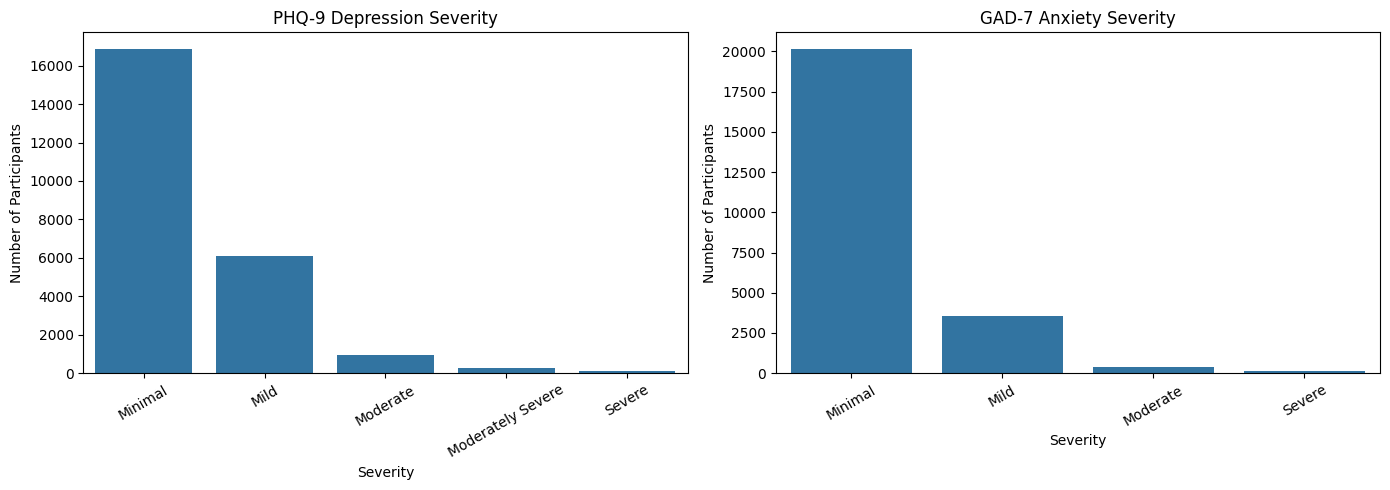

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# PHQ-9

phq9_order = [
    "Minimal",
    "Mild",
    "Moderate",
    "Moderately Severe",
    "Severe"
]

phq9_counts = (
    mental_health_df["phq9_severity"]
    .value_counts()
    .reindex(phq9_order)
    .fillna(0)
)

sns.barplot(
    x=phq9_counts.index,
    y=phq9_counts.values,
    ax=axes[0]
)

axes[0].set_title("PHQ-9 Depression Severity")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Number of Participants")

axes[0].tick_params(axis="x", rotation=30)


# GAD-7

gad7_order = [
    "Minimal",
    "Mild",
    "Moderate",
    "Severe"
]

gad7_counts = (
    mental_health_df["gad7_severity"]
    .value_counts()
    .reindex(gad7_order)
    .fillna(0)
)

sns.barplot(
    x=gad7_counts.index,
    y=gad7_counts.values,
    ax=axes[1]
)

axes[1].set_title("GAD-7 Anxiety Severity")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Number of Participants")

axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Create the two prediction targets

In [ ]:
print("CREATING Binary PREDICTION TARGETS")

# Depression target
mental_health_df["depression_target"] = (
    mental_health_df["phq9_score"] >= 10
).astype(int)

# Anxiety target
mental_health_df["anxiety_target"] = (
    mental_health_df["gad7_score"] >= 10
).astype(int)


print("\nDEPRESSION TARGET")

print(
    mental_health_df["depression_target"]
    .value_counts()
    .sort_index()
)

print("\nPercentage:")
print(
    (
        mental_health_df["depression_target"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)


print("\nANXIETY TARGET")

print(
    mental_health_df["anxiety_target"]
    .value_counts()
    .sort_index()
)

print("\nPercentage:")
print(
    (
        mental_health_df["anxiety_target"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)


CREATING Binary PREDICTION TARGETS

DEPRESSION TARGET
depression_target
0    22976
1     1316
Name: count, dtype: int64

Percentage:
depression_target
0    94.58
1     5.42
Name: proportion, dtype: float64

ANXIETY TARGET
anxiety_target
0    23746
1      546
Name: count, dtype: int64

Percentage:
anxiety_target
0    97.75
1     2.25
Name: proportion, dtype: float64


In [ ]:
# CREATE LEAKAGE-FREE MODELING DATASET

In [ ]:
print("CREATING LEAKAGE-FREE MODELING DATASET")

feature_columns = (
    phq9_question_cols +
    gad7_question_cols
)

target_columns = [
    "anxiety_target",
    "depression_target"
]

model_df = mental_health_df[
    ["export_id"] +
    feature_columns +
    target_columns
].copy()

print("Feature count :", len(feature_columns))
print("Target count  :", len(target_columns))
print("Dataset shape :", model_df.shape)

print("\nFeatures:")
print(feature_columns)

print("\nTargets:")
print(target_columns)

print("\nPreview:")
display(model_df.head())

CREATING LEAKAGE-FREE MODELING DATASET
Feature count : 16
Target count  : 2
Dataset shape : (24292, 19)

Features:
['phq9_q1', 'phq9_q2', 'phq9_q3', 'phq9_q4', 'phq9_q5', 'phq9_q6', 'phq9_q7', 'phq9_q8', 'phq9_q9', 'gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7']

Targets:
['anxiety_target', 'depression_target']

Preview:


,export_id,phq9_q1,phq9_q2,phq9_q3,phq9_q4,phq9_q5,phq9_q6,phq9_q7,phq9_q8,phq9_q9,gad7_q1,gad7_q2,gad7_q3,gad7_q4,gad7_q5,gad7_q6,gad7_q7,anxiety_target,depression_target
0,61793,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,61809,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,61737,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,61738,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,61739,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


# Analyze the two targets together

In [ ]:
# MULTI-TARGET DISTRIBUTION AND OVERLAP

print("ANXIETY + DEPRESSION TARGET OVERLAP")

# Create combination label
model_df["target_combination"] = (
    model_df["anxiety_target"].astype(str)
    + "_"
    + model_df["depression_target"].astype(str)
)

combination_counts = (
    model_df["target_combination"]
    .value_counts()
    .sort_index()
)

print("\nTarget combinations:")
display(combination_counts.to_frame("Count"))

print("\nPercentage:")
display(
    (
        combination_counts
        / len(model_df)
        * 100
    ).round(2).to_frame("Percentage")
)

# Cross-tabulation
print("\nCross-tabulation:")
target_crosstab = pd.crosstab(
    model_df["anxiety_target"],
    model_df["depression_target"]
)

display(target_crosstab)

ANXIETY + DEPRESSION TARGET OVERLAP

Target combinations:


,Count
target_combination,
0_0,22844
0_1,902
1_0,132
1_1,414



Percentage:


,Percentage
target_combination,
0_0,94.04
0_1,3.71
1_0,0.54
1_1,1.70



Cross-tabulation:


depression_target,0,1
anxiety_target,,
0,22844,902
1,132,414


# Check feature quality

In [ ]:
print("FEATURE QUALITY AUDIT")

feature_quality = pd.DataFrame({
    "Missing": model_df[feature_columns].isna().sum(),
    "Missing_%": (
        model_df[feature_columns].isna().mean() * 100
    ),
    "Unique_Values": (
        model_df[feature_columns].nunique()
    ),
    "Minimum": (
        model_df[feature_columns].min()
    ),
    "Maximum": (
        model_df[feature_columns].max()
    ),
    "Mean": (
        model_df[feature_columns].mean()
    ),
    "Std": (
        model_df[feature_columns].std()
    )
})

display(
    feature_quality.round(3)
)

FEATURE QUALITY AUDIT


,Missing,Missing_%,Unique_Values,Minimum,Maximum,Mean,Std
phq9_q1,0,0.0,4,0,3,0.537,0.641
phq9_q2,0,0.0,4,0,3,0.464,0.577
phq9_q3,0,0.0,4,0,3,0.442,0.673
phq9_q4,0,0.0,4,0,3,0.494,0.631
phq9_q5,0,0.0,4,0,3,0.340,0.594
phq9_q6,0,0.0,4,0,3,0.387,0.606
phq9_q7,0,0.0,4,0,3,0.350,0.610
phq9_q8,0,0.0,4,0,3,0.164,0.433
phq9_q9,0,0.0,4,0,3,0.086,0.321
gad7_q1,0,0.0,4,0,3,0.391,0.574


# Check for duplicate participants and duplicate feature records

In [ ]:
print("DUPLICATE RECORD ANALYSIS")

print(
    "Duplicate export_id:",
    model_df["export_id"].duplicated().sum()
)

print(
    "Duplicate feature rows:",
    model_df[feature_columns]
    .duplicated()
    .sum()
)

print(
    "Duplicate complete records:",
    model_df[
        feature_columns +
        ["anxiety_target", "depression_target"]
    ].duplicated().sum()
)

DUPLICATE RECORD ANALYSIS
Duplicate export_id: 0
Duplicate feature rows: 16438
Duplicate complete records: 16438


# Remove the temporary leakage-related columns

In [ ]:
# FINALIZE INITIAL MODELING DATAFRAME
model_df = model_df.drop(
    columns=["target_combination"]
)

print("INITIAL MODELING DATASET READY")

print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

INITIAL MODELING DATASET READY
Shape: (24292, 19)

Columns:
['export_id', 'phq9_q1', 'phq9_q2', 'phq9_q3', 'phq9_q4', 'phq9_q5', 'phq9_q6', 'phq9_q7', 'phq9_q8', 'phq9_q9', 'gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7', 'anxiety_target', 'depression_target']


# Inspect all original dataset columns

In [ ]:
# SEARCH FOR ADDITIONAL FEATURES
print("SEARCHING FOR ADDITIONAL DEMOGRAPHIC / PSYCHOSOCIAL FEATURES")

print("\nAll CSV files available:")

for i, file_path in enumerate(csv_files, 1):
    print(f"{i}. {os.path.basename(file_path)}")


for file_path in csv_files:

    filename = os.path.basename(file_path)

    try:
        df_temp = pd.read_csv(file_path)

        print(f"\nFILE: {filename}")
        print(f"Shape: {df_temp.shape}")

        print("Columns:")
        for col in df_temp.columns:
            print(f"  - {col}")

    except Exception as e:
        print(f"Could not read {filename}: {e}")

SEARCHING FOR ADDITIONAL DEMOGRAPHIC / PSYCHOSOCIAL FEATURES

All CSV files available:
1. demographic.csv
2. gad7.csv
3. isi.csv
4. phq9.csv
5. pss.csv
6. master_mental_health_dataset.csv
7. final_model_test_results.csv

FILE: demographic.csv
Shape: (24292, 6)
Columns:
  - export_id
  - gender
  - age
  - edu
  - smoke
  - drink

FILE: gad7.csv
Shape: (24292, 16)
Columns:
  - export_id
  - score
  - question1
  - time1
  - question2
  - time2
  - question3
  - time3
  - question4
  - time4
  - question5
  - time5
  - question6
  - time6
  - question7
  - time7

FILE: isi.csv
Shape: (24292, 16)
Columns:
  - export_id
  - score
  - question1
  - time1
  - question2
  - time2
  - question3
  - time3
  - question4
  - time4
  - question5
  - time5
  - question6
  - time6
  - question7
  - time7

FILE: phq9.csv
Shape: (24292, 20)
Columns:
  - export_id
  - score
  - question1
  - time1
  - question2
  - time2
  - question3
  - time3
  - question4
  - time4
  - question5
  - time5
  - questi

# Check whether PHQ-9/GAD-7 IDs match perfectly

In [ ]:
print("PARTICIPANT ID INTEGRITY CHECK")

phq_ids = set(phq9["export_id"])
gad_ids = set(gad7["export_id"])
merged_ids = set(model_df["export_id"])

print("PHQ-9 unique IDs :", len(phq_ids))
print("GAD-7 unique IDs :", len(gad_ids))
print("Merged unique IDs:", len(merged_ids))

print("\nPHQ-9 IDs missing from GAD-7:",
      len(phq_ids - gad_ids))

print("GAD-7 IDs missing from PHQ-9:",
      len(gad_ids - phq_ids))

print("Merged IDs not in PHQ-9:",
      len(merged_ids - phq_ids))

print("Merged IDs not in GAD-7:",
      len(merged_ids - gad_ids))

PARTICIPANT ID INTEGRITY CHECK
PHQ-9 unique IDs : 24292
GAD-7 unique IDs : 24292
Merged unique IDs: 24292

PHQ-9 IDs missing from GAD-7: 0
GAD-7 IDs missing from PHQ-9: 0
Merged IDs not in PHQ-9: 0
Merged IDs not in GAD-7: 0


In [ ]:
# Check target stratification feasibility

In [ ]:
model_df["stratify_label"] = (
    model_df["anxiety_target"].astype(str)
    + "_"
    + model_df["depression_target"].astype(str)
)

print("STRATIFICATION LABEL DISTRIBUTION")

display(
    model_df["stratify_label"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

STRATIFICATION LABEL DISTRIBUTION


,Count
stratify_label,
0_0,22844
0_1,902
1_0,132
1_1,414


# Patient-level train/validation/test split

In [ ]:
# TRAIN / VALIDATION / TEST SPLIT


print("CREATING TRAIN / VALIDATION / TEST SETS")

# First split: 70% train, 30% temporary

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=SEED,
    stratify=model_df["stratify_label"]
)


# Second split: 15% validation, 15% test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["stratify_label"]
)

print("Training set   :", train_df.shape)
print("Validation set :", val_df.shape)
print("Test set       :", test_df.shape)

print("\nExpected proportions:")

print(
    f"Train      : {len(train_df) / len(model_df) * 100:.2f}%"
)

print(
    f"Validation : {len(val_df) / len(model_df) * 100:.2f}%"
)

print(
    f"Test       : {len(test_df) / len(model_df) * 100:.2f}%"
)

CREATING TRAIN / VALIDATION / TEST SETS
Training set   : (17004, 20)
Validation set : (3644, 20)
Test set       : (3644, 20)

Expected proportions:
Train      : 70.00%
Validation : 15.00%
Test       : 15.00%


In [ ]:
# Verify target distribution after splitting

In [ ]:
def target_distribution(df, name):

    print(name)


    print(f"Samples: {len(df):,}")

    for target in ["anxiety_target", "depression_target"]:

        counts = df[target].value_counts().sort_index()
        percentages = (
            df[target]
            .value_counts(normalize=True)
            .sort_index()
            * 100
        )

        print(f"\n{target}")

        result = pd.DataFrame({
            "Count": counts,
            "Percentage": percentages.round(2)
        })

        display(result)

    print("\nTarget combinations:")

    combo = (
        df["stratify_label"]
        .value_counts()
        .sort_index()
    )

    display(combo.to_frame("Count"))


target_distribution(train_df, "TRAINING SET")
target_distribution(val_df, "VALIDATION SET")
target_distribution(test_df, "TEST SET")

TRAINING SET
Samples: 17,004

anxiety_target


,Count,Percentage
anxiety_target,,
0,16622,97.75
1,382,2.25



depression_target


,Count,Percentage
depression_target,,
0,16083,94.58
1,921,5.42



Target combinations:


...

,Count,Percentage
anxiety_target,,
0,3562,97.75
1,82,2.25



depression_target


,Count,Percentage
depression_target,,
0,3447,94.59
1,197,5.41



Target combinations:


,Count
stratify_label,
0_0,3427
0_1,135
1_0,20
1_1,62


# CHECK FOR PARTICIPANT DATA LEAKAGE

In [ ]:
train_ids = set(train_df["export_id"])
val_ids = set(val_df["export_id"])
test_ids = set(test_df["export_id"])

print("PARTICIPANT OVERLAP CHECK")

print("Train ∩ Validation:",
      len(train_ids.intersection(val_ids)))

print("Train ∩ Test:",
      len(train_ids.intersection(test_ids)))

print("Validation ∩ Test:",
      len(val_ids.intersection(test_ids)))


if (
    len(train_ids.intersection(val_ids)) == 0
    and
    len(train_ids.intersection(test_ids)) == 0
    and
    len(val_ids.intersection(test_ids)) == 0
):
    print("✓ NO PARTICIPANT OVERLAP DETECTED")
    print("✓ DATA SPLIT IS LEAKAGE-FREE")
else:
    print("WARNING: PARTICIPANT OVERLAP DETECTED")

PARTICIPANT OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0
✓ NO PARTICIPANT OVERLAP DETECTED
✓ DATA SPLIT IS LEAKAGE-FREE


# LOAD AND MERGE ADDITIONAL FEATURES

In [ ]:
print("LOADING ADDITIONAL PSYCHOSOCIAL DATA")

# Load datasets
demographic = pd.read_csv(
    os.path.join(base_path, "demographic.csv")
)

isi = pd.read_csv(
    os.path.join(base_path, "isi.csv")
)

pss = pd.read_csv(
    os.path.join(base_path, "pss.csv")
)

print("\nDataset shapes:")
print("Demographic :", demographic.shape)
print("ISI         :", isi.shape)
print("PSS         :", pss.shape)

print("DEMOGRAPHIC DATA")

display(demographic.head())

print("ISI DATA")

display(isi.head())

print("PSS DATA")

display(pss.head())

LOADING ADDITIONAL PSYCHOSOCIAL DATA

Dataset shapes:
Demographic : (24292, 6)
ISI         : (24292, 16)
PSS         : (24292, 30)
DEMOGRAPHIC DATA


,export_id,gender,age,edu,smoke,drink
0,61793,female,19.0,bachelor's degree,never smokes,never drinks
1,61809,female,18.0,bachelor's degree,never smokes,never drinks
2,61737,male,40.0,master's degree,never smokes,drinks occasionally (less than once a week)
3,61738,female,23.0,bachelor's degree,never smokes,never drinks
4,61739,female,21.0,bachelor's degree,never smokes,never drinks


ISI DATA


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7
0,61793,0,0,3.08,0,1.81,0,1.48,0,1.78,0,2.48,0,3.92,0,3.76
1,61809,0,0,1.23,0,0.93,0,1.37,0,1.95,0,4.09,0,1.74,0,3.22
2,61737,0,0,2.07,0,1.56,0,2.51,0,1.79,0,4.24,0,5.92,0,4.07
3,61738,0,0,1.34,0,0.42,0,2.20,0,0.76,0,0.82,0,1.22,0,2.20
4,61739,0,0,3.76,0,1.82,0,1.13,0,2.22,0,2.36,0,3.92,0,4.66


PSS DATA


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,...,question10,time10,question11,time11,question12,time12,question13,time13,question14,time14
0,61793,2,1,2.59,1,2.12,1,2.83,1,0.72,...,1,3.88,1,2.80,3,13.29,1,2.50,1,3.92
1,61809,21,2,5.10,1,3.97,1,0.97,5,0.77,...,5,2.78,1,1.91,2,3.29,2,5.04,1,3.62
2,61737,4,1,7.44,1,2.74,1,1.76,1,3.82,...,1,2.73,1,5.56,5,13.30,1,2.90,1,5.98
3,61738,28,1,1.18,1,1.25,1,0.59,5,0.50,...,5,0.55,1,1.04,1,0.34,5,0.48,1,2.15
4,61739,16,1,1.94,1,0.53,2,0.39,2,4.28,...,2,3.91,3,3.58,3,2.79,2,1.94,2,5.74


# Audit demographic variables

In [ ]:
print("DEMOGRAPHIC DATA QUALITY AUDIT")

print("\nMissing values:")
display(
    demographic.isna().sum().to_frame("Missing")
)

print("\nUnique values:")
display(
    demographic.nunique().to_frame("Unique_Values")
)

for column in [
    "gender",
    "edu",
    "smoke",
    "drink"
]:

    print(f"{column.upper()} DISTRIBUTION")

    print(
        demographic[column]
        .value_counts(dropna=False)
    )

print("\nAge statistics:")
display(
    demographic["age"]
    .describe()
    .to_frame("Age")
)

DEMOGRAPHIC DATA QUALITY AUDIT

Missing values:


,Missing
export_id,0
gender,0
age,0
edu,0
smoke,0
drink,0



Unique values:


,Unique_Values
export_id,24292
gender,2
age,43
edu,4
smoke,4
drink,4


GENDER DISTRIBUTION
gender
female    15545
male       8747
Name: count, dtype: int64
EDU DISTRIBUTION
edu
bachelor's degree    22290
associate degree      1285
master's degree        675
doctorate degree        42
Name: count, dtype: int64
SMOKE DISTRIBUTION
smoke
never smokes                                                              22513
occasional smoker (cumulative smoking <10 packs)                           1044
current smoker (cumulative smoking >10 packs)                               542
former smoker (cumulative smoking >10 packs), but not in the past year      193
Name: count, dtype: int64
DRINK DISTRIBUTION
drink
never drinks                                                           16404
drinks occasionally (less than once a week)                             7359
drank in the past (more than once a week), but not in the past year      284
current regular drinker (more than once a week)                          245
Name: count, dtype: int64

Age statistics:


,Age
count,24292.000000
mean,20.655730
std,2.408713
min,1.000000
25%,19.000000
50%,20.000000
75%,22.000000
max,99.000000


# ISI DATA QUALITY AUDIT

In [ ]:
print("INSOMNIA SEVERITY INDEX — DATA AUDIT")

isi_features = [
    f"question{i}"
    for i in range(1, 8)
]

print("\nMissing values:")
display(
    isi[["export_id"] + isi_features]
    .isna()
    .sum()
    .to_frame("Missing")
)

print("\nUnique values:")
display(
    isi[isi_features]
    .nunique()
    .to_frame("Unique_Values")
)

print("\nMinimum values:")
display(
    isi[isi_features]
    .min()
    .to_frame("Minimum")
)

print("\nMaximum values:")
display(
    isi[isi_features]
    .max()
    .to_frame("Maximum")
)

print("\nISI score statistics:")
display(
    isi["score"]
    .describe()
    .to_frame("ISI_Score")
)

INSOMNIA SEVERITY INDEX — DATA AUDIT

Missing values:


,Missing
export_id,0
question1,0
question2,0
question3,0
question4,0
question5,0
question6,0
question7,0



Unique values:


,Unique_Values
question1,5
question2,5
question3,5
question4,5
question5,5
question6,5
question7,5



Minimum values:


,Minimum
question1,0
question2,0
question3,0
question4,0
question5,0
question6,0
question7,0



Maximum values:


,Maximum
question1,4
question2,4
question3,4
question4,4
question5,4
question6,4
question7,4



ISI score statistics:


,ISI_Score
count,24292.000000
mean,2.777581
std,3.437386
min,0.000000
25%,0.000000
50%,2.000000
75%,4.000000
max,28.000000


# PERCEIVED STRESS SCALE DATA AUDIT

In [ ]:
print("PERCEIVED STRESS SCALE — DATA AUDIT")

pss_features = [
    f"question{i}"
    for i in range(1, 15)
]

print("\nMissing values:")
display(
    pss[["export_id"] + pss_features]
    .isna()
    .sum()
    .to_frame("Missing")
)

print("\nUnique values:")
display(
    pss[pss_features]
    .nunique()
    .to_frame("Unique_Values")
)

print("\nMinimum values:")
display(
    pss[pss_features]
    .min()
    .to_frame("Minimum")
)

print("\nMaximum values:")
display(
    pss[pss_features]
    .max()
    .to_frame("Maximum")
)

print("\nPSS score statistics:")
display(
    pss["score"]
    .describe()
    .to_frame("PSS_Score")
)

PERCEIVED STRESS SCALE — DATA AUDIT

Missing values:


,Missing
export_id,0
question1,0
question2,0
question3,0
question4,0
question5,0
question6,0
question7,0
question8,0
question9,0



Unique values:


,Unique_Values
question1,5
question2,5
question3,5
question4,5
question5,5
question6,5
question7,5
question8,5
question9,5
question10,5



Minimum values:


,Minimum
question1,1
question2,1
question3,1
question4,1
question5,1
question6,1
question7,1
question8,1
question9,1
question10,1



Maximum values:


,Maximum
question1,5
question2,5
question3,5
question4,5
question5,5
question6,5
question7,5
question8,5
question9,5
question10,5



PSS score statistics:


,PSS_Score
count,24292.000000
mean,19.991191
std,8.320719
min,0.000000
25%,14.000000
50%,20.000000
75%,27.000000
max,56.000000


# Verify all participant IDs

In [ ]:
print("ADDITIONAL PARTICIPANT ID VERIFICATION")

datasets = {
    "Demographic": demographic,
    "ISI": isi,
    "PSS": pss,
    "PHQ-9": phq9,
    "GAD-7": gad7
}

reference_ids = set(phq9["export_id"])

for name, df in datasets.items():

    current_ids = set(df["export_id"])

    print(f"\n{name}")

    print("Unique IDs :", len(current_ids))
    print(
        "Missing from PHQ-9 :",
        len(reference_ids - current_ids)
    )
    print(
        "Extra IDs          :",
        len(current_ids - reference_ids)
    )

ADDITIONAL PARTICIPANT ID VERIFICATION

Demographic
Unique IDs : 24292
Missing from PHQ-9 : 0
Extra IDs          : 0

ISI
Unique IDs : 24292
Missing from PHQ-9 : 0
Extra IDs          : 0

PSS
Unique IDs : 24292
Missing from PHQ-9 : 0
Extra IDs          : 0

PHQ-9
Unique IDs : 24292
Missing from PHQ-9 : 0
Extra IDs          : 0

GAD-7
Unique IDs : 24292
Missing from PHQ-9 : 0
Extra IDs          : 0


# Create clean feature tables

In [ ]:
# Demographics

demo_features = demographic[
    [
        "export_id",
        "gender",
        "age",
        "edu",
        "smoke",
        "drink"
    ]
].copy()

# ISI

isi_clean = isi[
    ["export_id"] + isi_features
].copy()

isi_clean.columns = (
    ["export_id"] +
    [f"isi_q{i}" for i in range(1, 8)]
)


# PSS

pss_clean = pss[
    ["export_id"] + pss_features
].copy()

pss_clean.columns = (
    ["export_id"] +
    [f"pss_q{i}" for i in range(1, 15)]
)


print("CLEAN FEATURE TABLES CREATED")

print("Demographic features :", demo_features.shape)
print("ISI features         :", isi_clean.shape)
print("PSS features         :", pss_clean.shape)

CLEAN FEATURE TABLES CREATED
Demographic features : (24292, 6)
ISI features         : (24292, 8)
PSS features         : (24292, 15)


# Create the final PHQ/GAD feature table

In [ ]:
phq_gad_features = model_df[
    ["export_id"] +
    feature_columns +
    ["anxiety_target", "depression_target"]
].copy()

print("PHQ-9 / GAD-7 FEATURE TABLE")

print("Shape:", phq_gad_features.shape)

print("\nFeatures:")
print(feature_columns)

print("\nTargets:")
print([
    "anxiety_target",
    "depression_target"
])

PHQ-9 / GAD-7 FEATURE TABLE
Shape: (24292, 19)

Features:
['phq9_q1', 'phq9_q2', 'phq9_q3', 'phq9_q4', 'phq9_q5', 'phq9_q6', 'phq9_q7', 'phq9_q8', 'phq9_q9', 'gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7']

Targets:
['anxiety_target', 'depression_target']


# Merge all information

In [ ]:
print("CREATING MASTER RESEARCH DATASET")

master_df = (
    phq_gad_features
    .merge(
        demo_features,
        on="export_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        isi_clean,
        on="export_id",
        how="inner",
        validate="one_to_one"
    )
    .merge(
        pss_clean,
        on="export_id",
        how="inner",
        validate="one_to_one"
    )
)

print("\nMASTER DATASET CREATED")

print("Shape:", master_df.shape)

print("\nNumber of participants:",
      master_df["export_id"].nunique())

print("\nNumber of features:",
      master_df.shape[1] - 3)

print("\nColumns:")
print(master_df.columns.tolist())

CREATING MASTER RESEARCH DATASET

MASTER DATASET CREATED
Shape: (24292, 45)

Number of participants: 24292

Number of features: 42

Columns:
['export_id', 'phq9_q1', 'phq9_q2', 'phq9_q3', 'phq9_q4', 'phq9_q5', 'phq9_q6', 'phq9_q7', 'phq9_q8', 'phq9_q9', 'gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7', 'anxiety_target', 'depression_target', 'gender', 'age', 'edu', 'smoke', 'drink', 'isi_q1', 'isi_q2', 'isi_q3', 'isi_q4', 'isi_q5', 'isi_q6', 'isi_q7', 'pss_q1', 'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5', 'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9', 'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13', 'pss_q14']


# Verify the master dataset

In [ ]:
print("MASTER DATASET INTEGRITY CHECK")

print("\nShape:")
print(master_df.shape)

print("\nDuplicate IDs:")
print(
    master_df["export_id"].duplicated().sum()
)

print("\nMissing values:")
total_missing = master_df.isna().sum().sum()
print("Total missing values:", total_missing)

print("\nDuplicate complete rows:")
print(
    master_df.duplicated().sum()
)

print("\nTarget distribution:")

display(
    master_df[
        ["anxiety_target", "depression_target"]
    ].sum()
    .to_frame("Positive_Count")
)

if (
    master_df["export_id"].duplicated().sum() == 0
    and
    total_missing == 0
):
    print("MASTER DATASET PASSED INTEGRITY CHECK")
else:
    print("MASTER DATASET REQUIRES INSPECTION")

MASTER DATASET INTEGRITY CHECK

Shape:
(24292, 45)

Duplicate IDs:
0

Missing values:
Total missing values: 0

Duplicate complete rows:
0

Target distribution:


,Positive_Count
anxiety_target,546
depression_target,1316


MASTER DATASET PASSED INTEGRITY CHECK


# FINAL STRATIFIED DATA SPLIT

In [ ]:
print("FINAL TRAIN / VALIDATION / TEST SPLIT")

# Create stratification label
master_df["stratify_label"] = (
    master_df["anxiety_target"].astype(str)
    + "_"
    + master_df["depression_target"].astype(str)
)

# 70% training / 30% temporary
train_df, temp_df = train_test_split(
    master_df,
    test_size=0.30,
    random_state=SEED,
    stratify=master_df["stratify_label"]
)

# 15% validation / 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["stratify_label"]
)

print("Training   :", train_df.shape)
print("Validation :", val_df.shape)
print("Testing    :", test_df.shape)

print("\nSplit percentages:")
print(
    f"Training   : {len(train_df)/len(master_df)*100:.2f}%"
)
print(
    f"Validation : {len(val_df)/len(master_df)*100:.2f}%"
)
print(
    f"Testing    : {len(test_df)/len(master_df)*100:.2f}%"
)

FINAL TRAIN / VALIDATION / TEST SPLIT
Training   : (17004, 46)
Validation : (3644, 46)
Testing    : (3644, 46)

Split percentages:
Training   : 70.00%
Validation : 15.00%
Testing    : 15.00%


# Remove the temporary stratification column

In [ ]:
for df in [train_df, val_df, test_df]:

    df.drop(
        columns=["stratify_label"],
        inplace=True
    )

print("FINAL SPLITS CLEANED")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

FINAL SPLITS CLEANED
Train: (17004, 45)
Validation: (3644, 45)
Test: (3644, 45)


# Define our four experimental feature sets

In [ ]:
demographic_columns = [
    "gender",
    "age",
    "edu",
    "smoke",
    "drink"
]

isi_columns = [
    f"isi_q{i}"
    for i in range(1, 8)
]

pss_columns = [
    f"pss_q{i}"
    for i in range(1, 15)
]

phq_columns = [
    f"phq9_q{i}"
    for i in range(1, 10)
]

gad_columns = [
    f"gad7_q{i}"
    for i in range(1, 8)
]

# Experiment A

features_demographic = demographic_columns

# Experiment B

features_contextual = (
    demographic_columns +
    isi_columns +
    pss_columns
)

# Experiment C

features_questionnaire = (
    phq_columns +
    gad_columns
)

# Experiment D

features_full = (
    demographic_columns +
    isi_columns +
    pss_columns +
    phq_columns +
    gad_columns
)

print("EXPERIMENTAL FEATURE SETS")

print(
    f"Experiment A — Demographic   : "
    f"{len(features_demographic)} features"
)

print(
    f"Experiment B — Contextual    : "
    f"{len(features_contextual)} features"
)

print(
    f"Experiment C — Questionnaire : "
    f"{len(features_questionnaire)} features"
)

print(
    f"Experiment D — Full          : "
    f"{len(features_full)} features"
)

EXPERIMENTAL FEATURE SETS
Experiment A — Demographic   : 5 features
Experiment B — Contextual    : 26 features
Experiment C — Questionnaire : 16 features
Experiment D — Full          : 42 features


# Exploratory Data Analysis

In [ ]:
print("EXPLORATORY DATA ANALYSIS")

print("\nFINAL DATASET SHAPE")
print(f"Total participants : {len(master_df):,}")
print(f"Total features     : {len(features_full)}")


# Target distributions

print("\nANXIETY TARGET DISTRIBUTION")

anxiety_counts = master_df["anxiety_target"].value_counts()
anxiety_percent = (
    master_df["anxiety_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(
    pd.DataFrame({
        "Count": anxiety_counts,
        "Percentage": anxiety_percent
    })
)

print("\nDEPRESSION TARGET DISTRIBUTION")

depression_counts = master_df["depression_target"].value_counts()
depression_percent = (
    master_df["depression_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(
    pd.DataFrame({
        "Count": depression_counts,
        "Percentage": depression_percent
    })
)

EXPLORATORY DATA ANALYSIS

FINAL DATASET SHAPE
Total participants : 24,292
Total features     : 42

ANXIETY TARGET DISTRIBUTION
                Count  Percentage
anxiety_target                   
0               23746       97.75
1                 546        2.25

DEPRESSION TARGET DISTRIBUTION
                   Count  Percentage
depression_target                   
0                  22976       94.58
1                   1316        5.42


# Visualize target imbalance

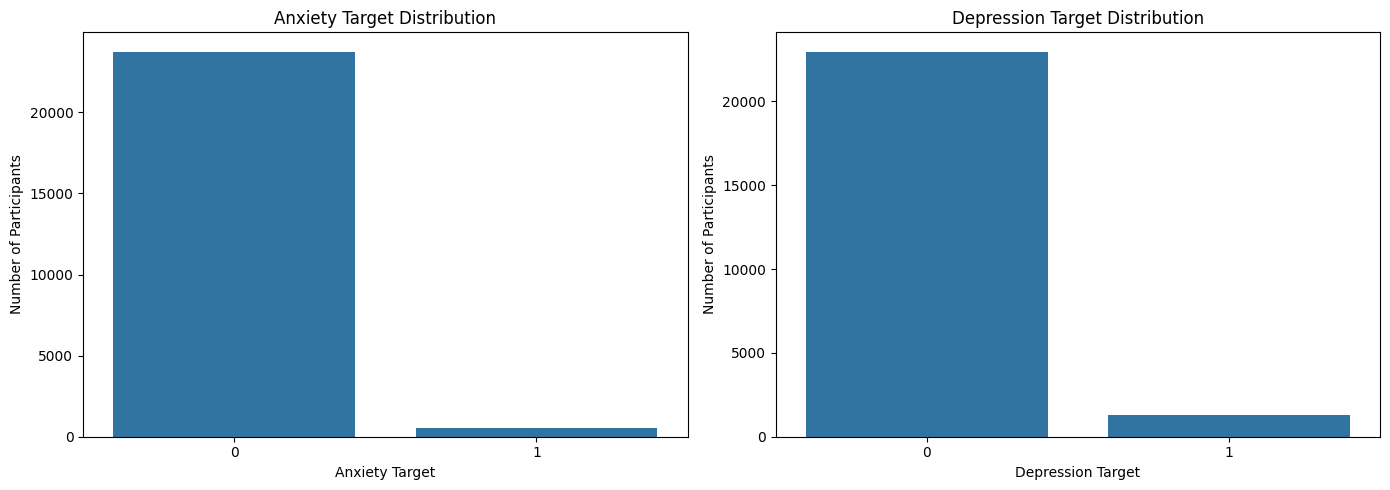

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anxiety
sns.countplot(
    data=master_df,
    x="anxiety_target",
    ax=axes[0]
)

axes[0].set_title("Anxiety Target Distribution")
axes[0].set_xlabel("Anxiety Target")
axes[0].set_ylabel("Number of Participants")

# Depression
sns.countplot(
    data=master_df,
    x="depression_target",
    ax=axes[1]
)

axes[1].set_title("Depression Target Distribution")
axes[1].set_xlabel("Depression Target")
axes[1].set_ylabel("Number of Participants")

plt.tight_layout()
plt.show()

# Analyze questionnaire scores

In [ ]:
print("QUESTIONNAIRE SCORE ANALYSIS")


score_analysis = pd.DataFrame({
    "PHQ9_Score": phq9["phq9_score"],
    "GAD7_Score": gad7["gad7_score"],
    "ISI_Score": isi["score"],
    "PSS_Score": pss["score"]
})

display(
    score_analysis.describe().T
)

QUESTIONNAIRE SCORE ANALYSIS


,count,mean,std,min,25%,50%,75%,max
PHQ9_Score,24292.0,3.265808,3.708496,0.0,0.0,2.0,5.0,27.0
GAD7_Score,24292.0,1.914128,2.919028,0.0,0.0,0.0,3.0,21.0
ISI_Score,24292.0,2.777581,3.437386,0.0,0.0,2.0,4.0,28.0
PSS_Score,24292.0,19.991191,8.320719,0.0,14.0,20.0,27.0,56.0


# Compare scores by target

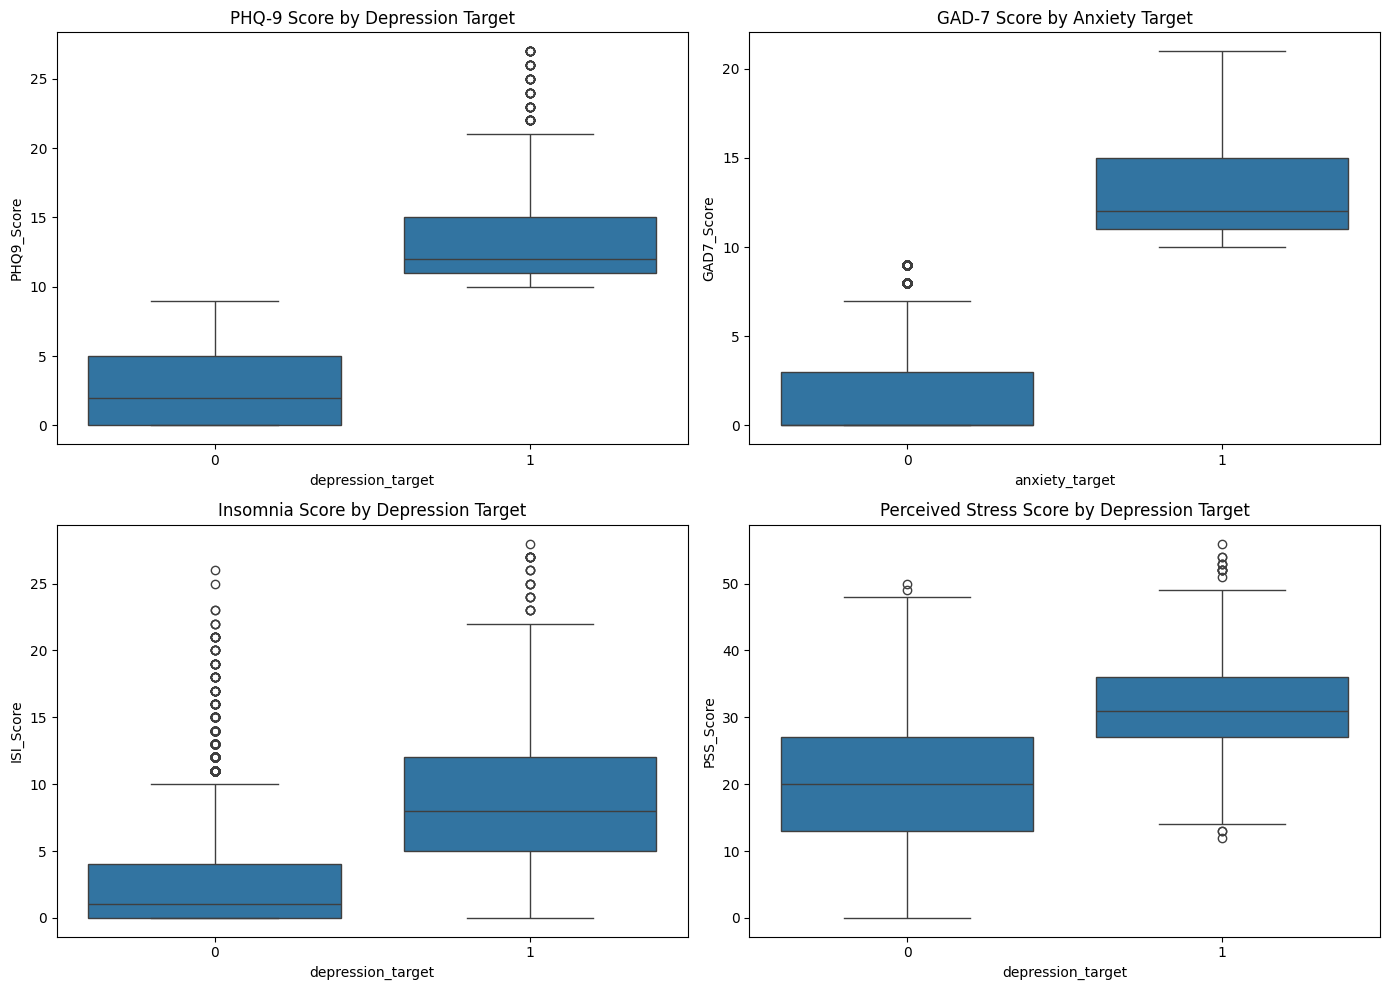

In [ ]:
analysis_df = master_df[
    [
        "export_id",
        "anxiety_target",
        "depression_target"
    ]
].copy()

analysis_df["PHQ9_Score"] = phq9["phq9_score"].values
analysis_df["GAD7_Score"] = gad7["gad7_score"].values
analysis_df["ISI_Score"] = isi["score"].values
analysis_df["PSS_Score"] = pss["score"].values


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(
    data=analysis_df,
    x="depression_target",
    y="PHQ9_Score",
    ax=axes[0, 0]
)

axes[0, 0].set_title("PHQ-9 Score by Depression Target")

sns.boxplot(
    data=analysis_df,
    x="anxiety_target",
    y="GAD7_Score",
    ax=axes[0, 1]
)

axes[0, 1].set_title("GAD-7 Score by Anxiety Target")

sns.boxplot(
    data=analysis_df,
    x="depression_target",
    y="ISI_Score",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Insomnia Score by Depression Target")

sns.boxplot(
    data=analysis_df,
    x="depression_target",
    y="PSS_Score",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Perceived Stress Score by Depression Target")

plt.tight_layout()
plt.show()

# Feature Correlation analysis

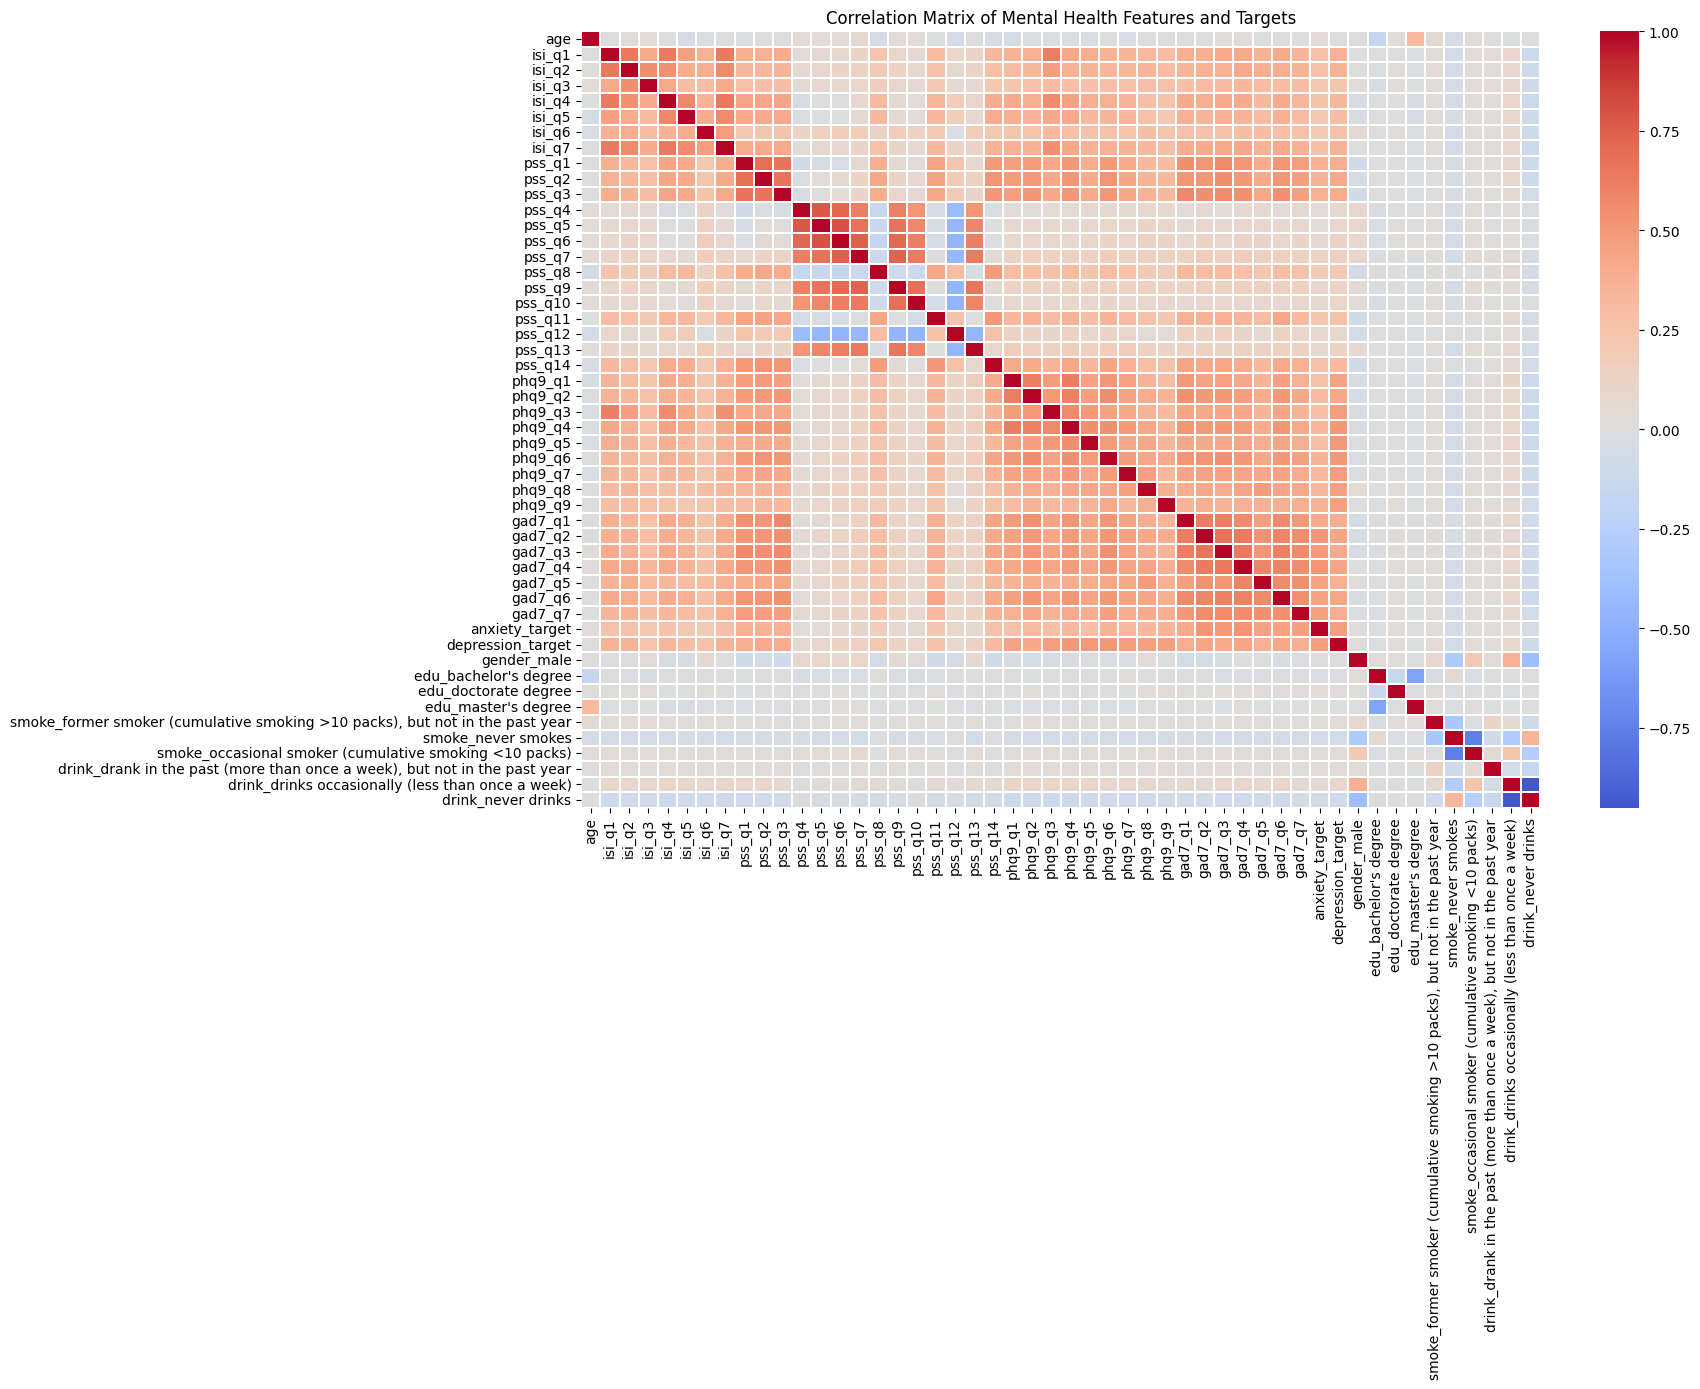

In [ ]:
correlation_df = master_df[
    features_full +
    [
        "anxiety_target",
        "depression_target"
    ]
].copy()

# Identify categorical columns from features_full that are in master_df
categorical_cols = [col for col in demographic_columns if correlation_df[col].dtype == 'object']

# Perform one-hot encoding on categorical columns
correlation_df_encoded = pd.get_dummies(correlation_df, columns=categorical_cols, drop_first=True)

correlation_matrix = correlation_df_encoded.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Correlation Matrix of Mental Health Features and Targets"
)

plt.tight_layout()
plt.show()

# Find the strongest feature-target relationships

In [ ]:
feature_target_corr = correlation_matrix[
    ["anxiety_target", "depression_target"]
].drop(
    index=["anxiety_target", "depression_target"]
)

print("STRONGEST FEATURE-TARGET ASSOCIATIONS")

print("\nANXIETY")

anxiety_rank = (
    feature_target_corr["anxiety_target"]
    .abs()
    .sort_values(ascending=False)
)

display(
    feature_target_corr.loc[
        anxiety_rank.head(10).index,
        ["anxiety_target"]
    ]
)

print("\nDEPRESSION")

depression_rank = (
    feature_target_corr["depression_target"]
    .abs()
    .sort_values(ascending=False)
)

display(
    feature_target_corr.loc[
        depression_rank.head(10).index,
        ["depression_target"]
    ]
)

STRONGEST FEATURE-TARGET ASSOCIATIONS

ANXIETY


,anxiety_target
gad7_q4,0.520776
gad7_q2,0.513189
gad7_q3,0.495036
gad7_q7,0.466091
gad7_q6,0.456609
gad7_q5,0.451303
gad7_q1,0.415628
pss_q1,0.381078
pss_q3,0.376923
pss_q2,0.361297



DEPRESSION


,depression_target
phq9_q6,0.503058
phq9_q4,0.502485
phq9_q5,0.491049
phq9_q3,0.480173
phq9_q7,0.477888
phq9_q9,0.465260
phq9_q8,0.463060
phq9_q1,0.450146
gad7_q4,0.440999
gad7_q2,0.439844


# Demographic distribution

In [ ]:
print("DEMOGRAPHIC DISTRIBUTION")

for col in [
    "gender",
    "edu",
    "smoke",
    "drink"
]:

    print(col.upper())

    distribution = pd.DataFrame({
        "Count": master_df[col].value_counts(dropna=False),
        "Percentage": (
            master_df[col]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )
    })

    display(distribution)

print("\nAGE SUMMARY")

display(
    master_df["age"].describe().to_frame("Age")
)

DEMOGRAPHIC DISTRIBUTION
GENDER


,Count,Percentage
gender,,
female,15545,63.99
male,8747,36.01


EDU


,Count,Percentage
edu,,
bachelor's degree,22290,91.76
associate degree,1285,5.29
master's degree,675,2.78
doctorate degree,42,0.17


SMOKE


,Count,Percentage
smoke,,
never smokes,22513,92.68
occasional smoker (cumulative smoking <10 packs),1044,4.30
current smoker (cumulative smoking >10 packs),542,2.23
"former smoker (cumulative smoking >10 packs), but not in the past year",193,0.79


DRINK


,Count,Percentage
drink,,
never drinks,16404,67.53
drinks occasionally (less than once a week),7359,30.29
"drank in the past (more than once a week), but not in the past year",284,1.17
current regular drinker (more than once a week),245,1.01



AGE SUMMARY


,Age
count,24292.000000
mean,20.655730
std,2.408713
min,1.000000
25%,19.000000
50%,20.000000
75%,22.000000
max,99.000000


# Target prevalence across demographic groups

In [ ]:
print("TARGET PREVALENCE BY DEMOGRAPHIC GROUP")

for col in [
    "gender",
    "edu",
    "smoke",
    "drink"
]:

    print(f"{col.upper()}")

    prevalence = (
        master_df
        .groupby(col)[
            [
                "anxiety_target",
                "depression_target"
            ]
        ]
        .mean()
        .mul(100)
        .round(2)
    )

    display(prevalence)

TARGET PREVALENCE BY DEMOGRAPHIC GROUP
GENDER


,anxiety_target,depression_target
gender,,
female,2.22,5.22
male,2.30,5.77


EDU


,anxiety_target,depression_target
edu,,
associate degree,3.11,6.85
bachelor's degree,2.16,5.32
doctorate degree,19.05,19.05
master's degree,2.52,5.19


SMOKE


,anxiety_target,depression_target
smoke,,
current smoker (cumulative smoking >10 packs),7.38,15.13
"former smoker (cumulative smoking >10 packs), but not in the past year",5.70,16.06
never smokes,2.01,4.91
occasional smoker (cumulative smoking <10 packs),4.12,9.29


DRINK


,anxiety_target,depression_target
drink,,
current regular drinker (more than once a week),9.80,23.27
"drank in the past (more than once a week), but not in the past year",5.63,10.92
drinks occasionally (less than once a week),3.22,8.13
never drinks,1.64,3.84


# Feature Range Validation

In [ ]:
print("FEATURE RANGE VALIDATION")

# Separate numerical and categorical columns from features_full
# Using pd.api.types to robustly identify numeric and object (categorical) columns
numeric_features = [col for col in features_full if pd.api.types.is_numeric_dtype(master_df[col])]
categorical_features = [col for col in features_full if pd.api.types.is_object_dtype(master_df[col])]


# Initialize an empty dictionary to hold the series for the DataFrame
range_data = {}

# Calculate numerical statistics for numeric columns
if numeric_features:
    range_data["Minimum"] = master_df[numeric_features].min()
    range_data["Maximum"] = master_df[numeric_features].max()
    range_data["Mean"] = master_df[numeric_features].mean()
    range_data["Std"] = master_df[numeric_features].std()

# Calculate unique values for all features, both numerical and categorical
range_data["Unique"] = master_df[features_full].nunique()

# Create the DataFrame from the collected data.
# pd.DataFrame will align by index (column names in this case)
range_check = pd.DataFrame(range_data)

display(range_check)

FEATURE RANGE VALIDATION


,Minimum,Maximum,Mean,Std,Unique
age,1.0,99.0,20.655730,2.408713,43
drink,NaN,NaN,NaN,NaN,4
edu,NaN,NaN,NaN,NaN,4
gad7_q1,0.0,3.0,0.391363,0.573534,4
gad7_q2,0.0,3.0,0.279557,0.539209,4
gad7_q3,0.0,3.0,0.350445,0.588881,4
gad7_q4,0.0,3.0,0.251523,0.529917,4
gad7_q5,0.0,3.0,0.160876,0.420410,4
gad7_q6,0.0,3.0,0.286391,0.538065,4
gad7_q7,0.0,3.0,0.193973,0.461252,4


# Save the cleaned master dataset

In [ ]:
save_path = os.path.join(
    base_path,
    "master_mental_health_dataset.csv"
)

master_df.to_csv(
    save_path,
    index=False
)

print("MASTER DATASET SAVED")

print(save_path)
print(f"Rows    : {len(master_df):,}")
print(f"Columns : {len(master_df.columns)}")

MASTER DATASET SAVED
/content/drive/MyDrive/Anxiety_Dataset/master_mental_health_dataset.csv
Rows    : 24,292
Columns : 46


# Investigate demographic coding

In [ ]:
print("DEMOGRAPHIC VARIABLE INVESTIGATION")

# Age distribution

print("\nAGE DISTRIBUTION")

print(master_df["age"].describe())

print("\nLowest 30 ages:")
print(
    master_df["age"]
    .value_counts()
    .sort_index()
    .head(30)
)

print("\nHighest 20 ages:")
print(
    master_df["age"]
    .value_counts()
    .sort_index()
    .tail(20)
)

# Gender

print("\nGENDER CODES")

print(
    master_df["gender"]
    .value_counts(dropna=False)
    .sort_index()
)

# Education

print("\nEDUCATION CODES")

print(
    master_df["edu"]
    .value_counts(dropna=False)
    .sort_index()
)

# Smoking

print("\nSMOKING CODES")

print(
    master_df["smoke"]
    .value_counts(dropna=False)
    .sort_index()
)

# Drinking

print("\nDRINKING CODES")

print(
    master_df["drink"]
    .value_counts(dropna=False)
    .sort_index()
)

DEMOGRAPHIC VARIABLE INVESTIGATION

AGE DISTRIBUTION
count    24292.000000
mean        20.655730
std          2.408713
min          1.000000
25%         19.000000
50%         20.000000
75%         22.000000
max         99.000000
Name: age, dtype: float64

Lowest 30 ages:
age
1.0        5
5.0        1
10.0       4
12.0       5
13.0       2
14.0       2
15.0       3
16.0      10
17.0     183
18.0    2609
19.0    4641
20.0    5716
21.0    4419
22.0    2938
23.0    1721
24.0    1020
25.0     536
26.0     197
27.0      93
28.0      43
29.0      33
30.0      29
31.0      10
32.0      18
33.0       8
34.0       6
35.0       6
36.0       2
37.0       4
38.0       3
Name: count, dtype: int64

Highest 20 ages:
age
32.0    18
33.0     8
34.0     6
35.0     6
36.0     2
37.0     4
38.0     3
39.0     5
40.0     2
42.0     2
44.0     1
46.0     2
48.0     2
49.0     2
50.0     1
55.0     2
61.0     1
80.0     1
81.0     1
99.0     3
Name: count, dtype: int64

GENDER CODES
gender
female    15545
mal

# Check suspicious ages

In [ ]:
# AGE QUALITY CHECK

print("AGE QUALITY CHECK")

age_checks = {
    "Age < 10": (master_df["age"] < 10).sum(),
    "Age 10-17": (
        (master_df["age"] >= 10) &
        (master_df["age"] < 18)
    ).sum(),
    "Age 18-25": (
        (master_df["age"] >= 18) &
        (master_df["age"] <= 25)
    ).sum(),
    "Age 26-40": (
        (master_df["age"] > 25) &
        (master_df["age"] <= 40)
    ).sum(),
    "Age 41-60": (
        (master_df["age"] > 40) &
        (master_df["age"] <= 60)
    ).sum(),
    "Age > 60": (
        master_df["age"] > 60
    ).sum()
}

for category, count in age_checks.items():
    print(f"{category:<15}: {count:,}")

AGE QUALITY CHECK
Age < 10       : 6
Age 10-17      : 209
Age 18-25      : 23,600
Age 26-40      : 459
Age 41-60      : 12
Age > 60       : 6


# Visualize age distribution

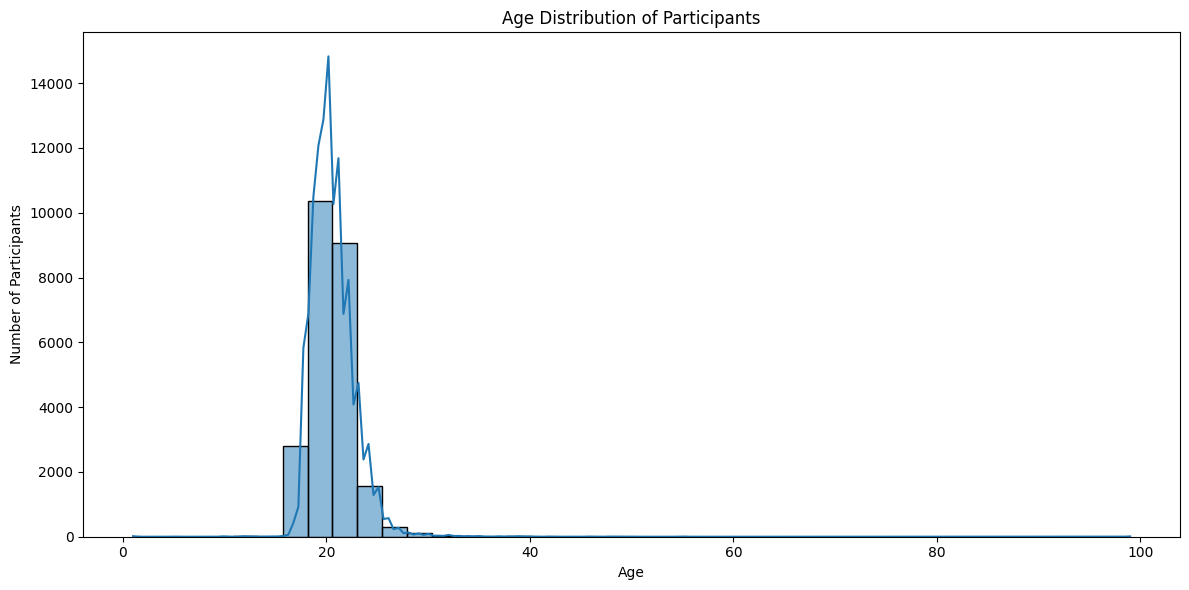

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    master_df["age"],
    bins=40,
    kde=True
)

plt.title("Age Distribution of Participants")
plt.xlabel("Age")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()

# DEMOGRAPHIC MISSING VALUE ANALYSIS

In [ ]:
print("DEMOGRAPHIC MISSING VALUE ANALYSIS")

demographic_columns = [
    "gender",
    "age",
    "edu",
    "smoke",
    "drink"
]

missing_demo = pd.DataFrame({
    "Missing": master_df[demographic_columns].isna().sum(),
    "Missing_%": (
        master_df[demographic_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

display(missing_demo)

DEMOGRAPHIC MISSING VALUE ANALYSIS


,Missing,Missing_%
gender,0,0.0
age,0,0.0
edu,0,0.0
smoke,0,0.0
drink,0,0.0


# Check whether categorical values are encoded numerically

In [ ]:
categorical_columns = [
    "gender",
    "edu",
    "smoke",
    "drink"
]

print("CATEGORICAL CODE INSPECTION")

for col in categorical_columns:

    print(f"{col.upper()}")

    print(
        "Data type:",
        master_df[col].dtype
    )

    print(
        "Values:",
        sorted(
            master_df[col]
            .dropna()
            .unique()
            .tolist()
        )
    )

CATEGORICAL CODE INSPECTION
GENDER
Data type: object
Values: ['female', 'male']
EDU
Data type: object
Values: ['associate degree', "bachelor's degree", 'doctorate degree', "master's degree"]
SMOKE
Data type: object
Values: ['current smoker (cumulative smoking >10 packs)', 'former smoker (cumulative smoking >10 packs), but not in the past year', 'never smokes', 'occasional smoker (cumulative smoking <10 packs)']
DRINK
Data type: object
Values: ['current regular drinker (more than once a week)', 'drank in the past (more than once a week), but not in the past year', 'drinks occasionally (less than once a week)', 'never drinks']


# DEMOGRAPHIC PREPROCESSING PLAN

In [ ]:
print("DEMOGRAPHIC PREPROCESSING PLAN")

categorical_features = [
    "gender",
    "edu",
    "smoke",
    "drink"
]

numeric_features = [
    "age"
]

print("\nCategorical features:")
for col in categorical_features:
    print(f"  {col}")

print("\nNumeric features:")
for col in numeric_features:
    print(f"  {col}")

print("\nEncoding strategy:")
print("  Categorical : One-Hot Encoding")
print("  Age         : Standard Scaling")

DEMOGRAPHIC PREPROCESSING PLAN

Categorical features:
  gender
  edu
  smoke
  drink

Numeric features:
  age

Encoding strategy:
  Categorical : One-Hot Encoding
  Age         : Standard Scaling


# Check age more carefully

In [ ]:
print("FINAL AGE VALIDATION")

print("\nAge statistics:")
print(master_df["age"].describe())

print("\nParticipants with age < 18:")
print(
    (master_df["age"] < 18).sum()
)

print("\nParticipants with age < 10:")
print(
    (master_df["age"] < 10).sum()
)

print("\nParticipants with age > 60:")
print(
    (master_df["age"] > 60).sum()
)

print("\nExact ages below 18:")
print(
    sorted(
        master_df.loc[
            master_df["age"] < 18,
            "age"
        ].unique()
    )
)

FINAL AGE VALIDATION

Age statistics:
count    24292.000000
mean        20.655730
std          2.408713
min          1.000000
25%         19.000000
50%         20.000000
75%         22.000000
max         99.000000
Name: age, dtype: float64

Participants with age < 18:
215

Participants with age < 10:
6

Participants with age > 60:
6

Exact ages below 18:
[np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0)]


# Identify missing demographic values

In [ ]:
print("FINAL DEMOGRAPHIC MISSING-VALUE CHECK")

demo_cols = [
    "age",
    "gender",
    "edu",
    "smoke",
    "drink"
]

demo_missing = pd.DataFrame({
    "Missing": master_df[demo_cols].isna().sum(),
    "Missing_%": (
        master_df[demo_cols]
        .isna()
        .mean()
        .mul(100)
        .round(3)
    )
})

display(demo_missing)

total_demo_missing = demo_missing["Missing"].sum()

print(
    f"\nTotal demographic missing values: "
    f"{total_demo_missing}"
)

FINAL DEMOGRAPHIC MISSING-VALUE CHECK


,Missing,Missing_%
age,0,0.0
gender,0,0.0
edu,0,0.0
smoke,0,0.0
drink,0,0.0



Total demographic missing values: 0


# FINAL FEATURE GROUP DEFINITIONS

In [ ]:
demographic_features = [
    "age",
    "gender",
    "edu",
    "smoke",
    "drink"
]

isi_features_clean = [
    f"isi_q{i}"
    for i in range(1, 8)
]

pss_features_clean = [
    f"pss_q{i}"
    for i in range(1, 15)
]

phq_features_clean = [
    f"phq9_q{i}"
    for i in range(1, 10)
]

gad_features_clean = [
    f"gad7_q{i}"
    for i in range(1, 8)
]

print("FINAL FEATURE GROUPS")

print(
    "Demographic :",
    len(demographic_features)
)

print(
    "ISI         :",
    len(isi_features_clean)
)

print(
    "PSS         :",
    len(pss_features_clean)
)

print(
    "PHQ-9       :",
    len(phq_features_clean)
)

print(
    "GAD-7       :",
    len(gad_features_clean)
)

FINAL FEATURE GROUPS
Demographic : 5
ISI         : 7
PSS         : 14
PHQ-9       : 9
GAD-7       : 7


# FINAL RESEARCH EXPERIMENT CONFIGURATION

In [ ]:
EXPERIMENTS = {

    "A_Demographic": demographic_features,

    "B_Contextual": (
        demographic_features +
        isi_features_clean +
        pss_features_clean
    ),

    "C_Questionnaire": (
        phq_features_clean +
        gad_features_clean
    ),

    "D_Full": (
        demographic_features +
        isi_features_clean +
        pss_features_clean +
        phq_features_clean +
        gad_features_clean
    )
}

print("FINAL RESEARCH EXPERIMENT CONFIGURATION")

for name, features in EXPERIMENTS.items():

    print(
        f"{name:<20} : "
        f"{len(features)} features"
    )

FINAL RESEARCH EXPERIMENT CONFIGURATION
A_Demographic        : 5 features
B_Contextual         : 26 features
C_Questionnaire      : 16 features
D_Full               : 42 features


# Leakage-Safe Preprocessing

In [ ]:
print("FINAL LEAKAGE-SAFE FEATURE SET")

# IMPORTANT:
# PHQ-9 and GAD-7 QUESTION RESPONSES ARE NOT USED AS FEATURES because the targets are derived from these questionnaires.

demographic_features = [
    "age",
    "gender",
    "edu",
    "smoke",
    "drink"
]

isi_features = [
    f"isi_q{i}" for i in range(1, 8)
]

pss_features = [
    f"pss_q{i}" for i in range(1, 15)
]

# Final predictors
safe_features = (
    demographic_features
    + isi_features
    + pss_features
)

targets = [
    "anxiety_target",
    "depression_target"
]

print("Demographic features :", len(demographic_features))
print("ISI features         :", len(isi_features))
print("PSS features         :", len(pss_features))


print("TOTAL SAFE FEATURES  :", len(safe_features))
print("TARGETS              :", targets)

print("\nSAFE FEATURES:")
for feature in safe_features:
    print(" ", feature)

print("\nPHQ-9 features excluded : YES")
print("GAD-7 features excluded : YES")

FINAL LEAKAGE-SAFE FEATURE SET
Demographic features : 5
ISI features         : 7
PSS features         : 14
TOTAL SAFE FEATURES  : 26
TARGETS              : ['anxiety_target', 'depression_target']

SAFE FEATURES:
  age
  gender
  edu
  smoke
  drink
  isi_q1
  isi_q2
  isi_q3
  isi_q4
  isi_q5
  isi_q6
  isi_q7
  pss_q1
  pss_q2
  pss_q3
  pss_q4
  pss_q5
  pss_q6
  pss_q7
  pss_q8
  pss_q9
  pss_q10
  pss_q11
  pss_q12
  pss_q13
  pss_q14

PHQ-9 features excluded : YES
GAD-7 features excluded : YES


# CREATE LEAKAGE-SAFE X AND y

In [ ]:
X = master_df[safe_features].copy()

y = master_df[targets].copy()

print("LEAKAGE-SAFE MODELING DATA")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny columns:")
print(y.columns.tolist())

LEAKAGE-SAFE MODELING DATA
X shape: (24292, 26)
y shape: (24292, 2)

X columns:
['age', 'gender', 'edu', 'smoke', 'drink', 'isi_q1', 'isi_q2', 'isi_q3', 'isi_q4', 'isi_q5', 'isi_q6', 'isi_q7', 'pss_q1', 'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5', 'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9', 'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13', 'pss_q14']

y columns:
['anxiety_target', 'depression_target']


# BUILD X/Y FOR EXISTING SPLITS

In [ ]:
X_train = train_df[safe_features].copy()
X_val   = val_df[safe_features].copy()
X_test  = test_df[safe_features].copy()

y_train = train_df[targets].copy()
y_val   = val_df[targets].copy()
y_test  = test_df[targets].copy()

print("SPLIT DATA READY")

print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

SPLIT DATA READY
X_train : (17004, 26)
X_val   : (3644, 26)
X_test  : (3644, 26)
y_train : (17004, 2)
y_val   : (3644, 2)
y_test  : (3644, 2)


#LEAKAGE-SAFE PREPROCESSING

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    "gender",
    "edu",
    "smoke",
    "drink"
]

numerical_features = [
    "age"
] + isi_features + pss_features

print("PREPROCESSING CONFIGURATION")

print("Categorical features :", len(categorical_features))
print("Numerical features   :", len(numerical_features))
print("Total features       :",
      len(categorical_features) + len(numerical_features))

PREPROCESSING CONFIGURATION
Categorical features : 4
Numerical features   : 22
Total features       : 26


# CREATE PREPROCESSOR

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("PREPROCESSOR CREATED")

PREPROCESSOR CREATED


# FIT PREPROCESSOR ONLY ON TRAINING DATA

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("PREPROCESSING COMPLETED")

print("Training processed shape   :", X_train_processed.shape)
print("Validation processed shape :", X_val_processed.shape)
print("Test processed shape       :", X_test_processed.shape)

PREPROCESSING COMPLETED
Training processed shape   : (17004, 36)
Validation processed shape : (3644, 36)
Test processed shape       : (3644, 36)


# FINAL LEAKAGE CHECK

In [ ]:
forbidden = (
    [f"phq9_q{i}" for i in range(1, 10)] +
    [f"gad7_q{i}" for i in range(1, 8)]
)

remaining_forbidden = [
    col for col in safe_features
    if col in forbidden
]

print("FINAL LEAKAGE CHECK")

if len(remaining_forbidden) == 0:
    print(" PHQ-9 FEATURES EXCLUDED")
    print(" GAD-7 FEATURES EXCLUDED")
    print(" TARGET LEAKAGE CHECK PASSED")
else:
    print("LEAKAGE DETECTED")
    print(remaining_forbidden)

FINAL LEAKAGE CHECK
 PHQ-9 FEATURES EXCLUDED
 GAD-7 FEATURES EXCLUDED
 TARGET LEAKAGE CHECK PASSED


# Save the preprocessing pipeline

In [ ]:
import joblib

preprocessor_path = os.path.join(
    base_path,
    "leakage_safe_preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

print("PREPROCESSOR SAVED")

print(preprocessor_path)

PREPROCESSOR SAVED
/content/drive/MyDrive/Anxiety_Dataset/leakage_safe_preprocessor.pkl


# LEAKAGE-SAFE LOGISTIC REGRESSION BASELINE

In [ ]:
# Logistic Regression baseline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("LEAKAGE-SAFE LOGISTIC REGRESSION BASELINE")

# Train separate binary models

anxiety_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=SEED
)

depression_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=SEED
)

# Train
anxiety_model.fit(
    X_train_processed,
    y_train["anxiety_target"]
)

depression_model.fit(
    X_train_processed,
    y_train["depression_target"]
)

print(" Anxiety model trained")
print(" Depression model trained")

LEAKAGE-SAFE LOGISTIC REGRESSION BASELINE
 Anxiety model trained
 Depression model trained


# BASELINE EVALUATION

In [ ]:
def evaluate_binary_model(
    model,
    X,
    y,
    dataset_name,
    target_name
):

    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    results = {
        "Model": "Logistic Regression",
        "Dataset": dataset_name,
        "Target": target_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(
            y, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y, y_prob
        ),
        "PR_AUC": average_precision_score(
            y, y_prob
        ),
        "Brier_Score": brier_score_loss(
            y, y_prob
        )
    }

    print(f"{target_name.upper()} — {dataset_name.upper()}")

    for key, value in results.items():
        if isinstance(value, float):
            print(f"{key:<15}: {value:.4f}")
        else:
            print(f"{key:<15}: {value}")

    return results

In [ ]:
# VALIDATION RESULTS

val_anxiety_results = evaluate_binary_model(
    anxiety_model,
    X_val_processed,
    y_val["anxiety_target"],
    "Validation",
    "Anxiety"
)

val_depression_results = evaluate_binary_model(
    depression_model,
    X_val_processed,
    y_val["depression_target"],
    "Validation",
    "Depression"
)


# TEST RESULTS

test_anxiety_results = evaluate_binary_model(
    anxiety_model,
    X_test_processed,
    y_test["anxiety_target"],
    "Test",
    "Anxiety"
)

test_depression_results = evaluate_binary_model(
    depression_model,
    X_test_processed,
    y_test["depression_target"],
    "Test",
    "Depression"
)

ANXIETY — VALIDATION
Model          : Logistic Regression
Dataset        : Validation
Target         : Anxiety
Accuracy       : 0.9256
Precision      : 0.2196
Recall         : 0.9024
F1             : 0.3532
ROC_AUC        : 0.9716
PR_AUC         : 0.6792
Brier_Score    : 0.0585
DEPRESSION — VALIDATION
Model          : Logistic Regression
Dataset        : Validation
Target         : Depression
Accuracy       : 0.8839
Precision      : 0.3009
Recall         : 0.8586
F1             : 0.4456
ROC_AUC        : 0.9434
PR_AUC         : 0.6428
Brier_Score    : 0.0853
ANXIETY — TEST
Model          : Logistic Regression
Dataset        : Test
Target         : Anxiety
Accuracy       : 0.9158
Precision      : 0.1935
Recall         : 0.8659
F1             : 0.3163
ROC_AUC        : 0.9572
PR_AUC         : 0.5483
Brier_Score    : 0.0636
DEPRESSION — TEST
Model          : Logistic Regression
Dataset        : Test
Target         : Depression
Accuracy       : 0.8699
Precision      : 0.2755
Recall         :

In [ ]:
# SAVE BASELINE MODELS

anxiety_model_path = os.path.join(
    base_path,
    "baseline_logistic_anxiety.pkl"
)

depression_model_path = os.path.join(
    base_path,
    "baseline_logistic_depression.pkl"
)

joblib.dump(
    anxiety_model,
    anxiety_model_path
)

joblib.dump(
    depression_model,
    depression_model_path
)

print("BASELINE MODELS SAVED")

print("Anxiety model    :", anxiety_model_path)
print("Depression model :", depression_model_path)

BASELINE MODELS SAVED
Anxiety model    : /content/drive/MyDrive/Anxiety_Dataset/baseline_logistic_anxiety.pkl
Depression model : /content/drive/MyDrive/Anxiety_Dataset/baseline_logistic_depression.pkl


# THRESHOLD ANALYSIS

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("THRESHOLD ANALYSIS")


def threshold_analysis(model, X, y, target_name):

    probabilities = model.predict_proba(X)[:, 1]

    thresholds = np.arange(0.05, 0.96, 0.05)

    results = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y,
            predictions,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y,
            predictions,
            zero_division=0
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )

        results.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Specificity": specificity,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn
        })

    results_df = pd.DataFrame(results)

    print(f"\n{target_name.upper()} — THRESHOLD RESULTS")

    display(
        results_df.round(4)
    )

    # Best F1 threshold
    best_row = results_df.loc[
        results_df["F1"].idxmax()
    ]

    print("BEST F1 THRESHOLD")

    print(
        f"Threshold   : {best_row['Threshold']:.2f}"
    )

    print(
        f"Precision   : {best_row['Precision']:.4f}"
    )

    print(
        f"Recall      : {best_row['Recall']:.4f}"
    )

    print(
        f"F1          : {best_row['F1']:.4f}"
    )

    print(
        f"Specificity : {best_row['Specificity']:.4f}"
    )

    return results_df

# ANXIETY
anxiety_threshold_results = threshold_analysis(
    anxiety_model,
    X_val_processed,
    y_val["anxiety_target"],
    "Anxiety"
)


# DEPRESSION
depression_threshold_results = threshold_analysis(
    depression_model,
    X_val_processed,
    y_val["depression_target"],
    "Depression"
)

THRESHOLD ANALYSIS

ANXIETY — THRESHOLD RESULTS


,Threshold,Precision,Recall,F1,Specificity,TP,FP,TN,FN
0,0.05,0.0606,0.9878,0.1142,0.6474,81,1256,2306,1
1,0.10,0.0823,0.9878,0.1520,0.7465,81,903,2659,1
2,0.15,0.1011,0.9756,0.1833,0.8004,80,711,2851,2
3,0.20,0.1212,0.9634,0.2153,0.8391,79,573,2989,3
4,0.25,0.1385,0.9512,0.2419,0.8638,78,485,3077,4
5,0.30,0.1592,0.9512,0.2727,0.8843,78,412,3150,4
6,0.35,0.1711,0.9390,0.2895,0.8953,77,373,3189,5
7,0.40,0.1881,0.9268,0.3128,0.9079,76,328,3234,6
8,0.45,0.2011,0.9024,0.3289,0.9175,74,294,3268,8
9,0.50,0.2196,0.9024,0.3532,0.9262,74,263,3299,8


BEST F1 THRESHOLD
Threshold   : 0.95
Precision   : 0.5464
Recall      : 0.6463
F1          : 0.5922
Specificity : 0.9876

DEPRESSION — THRESHOLD RESULTS


,Threshold,Precision,Recall,F1,Specificity,TP,FP,TN,FN
0,0.05,0.0911,0.9899,0.1668,0.4324,196,1956,1490,2
1,0.10,0.1230,0.9697,0.2183,0.6027,192,1369,2077,6
2,0.15,0.1514,0.9596,0.2615,0.6909,190,1065,2381,8
3,0.20,0.1759,0.9495,0.2968,0.7443,188,881,2565,10
4,0.25,0.1966,0.9293,0.3245,0.7818,184,752,2694,14
5,0.30,0.2130,0.9091,0.3452,0.8070,180,665,2781,18
6,0.35,0.2381,0.9091,0.3774,0.8328,180,576,2870,18
7,0.40,0.2584,0.8889,0.4005,0.8535,176,505,2941,22
8,0.45,0.2796,0.8838,0.4248,0.8691,175,451,2995,23
9,0.50,0.3009,0.8586,0.4456,0.8854,170,395,3051,28


BEST F1 THRESHOLD
Threshold   : 0.95
Precision   : 0.6950
Recall      : 0.4949
F1          : 0.5782
Specificity : 0.9875


# THRESHOLD PERFORMANCE CURVES

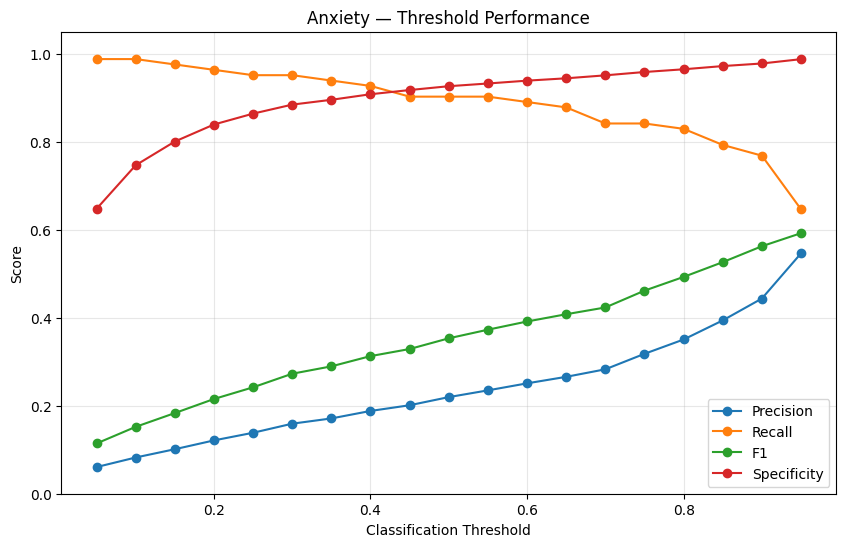

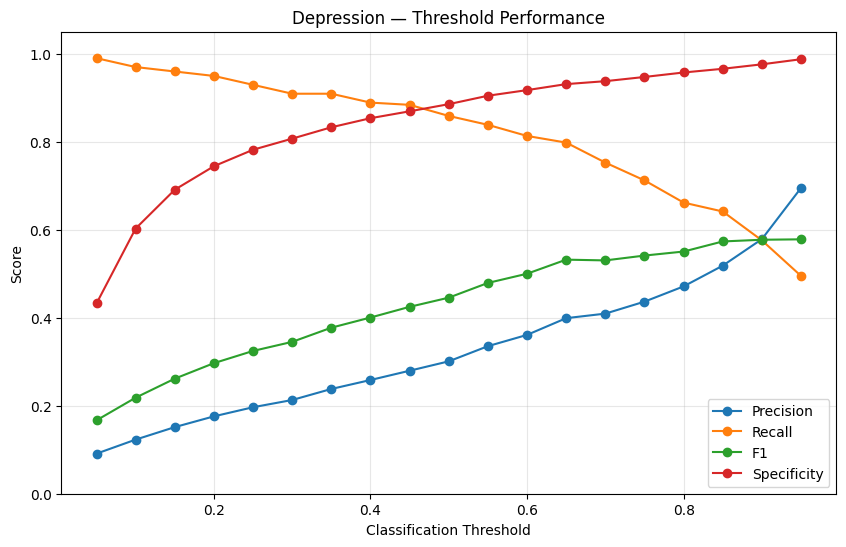

In [ ]:
def plot_threshold_results(
    results_df,
    target_name
):

    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["Threshold"],
        results_df["Precision"],
        marker="o",
        label="Precision"
    )

    plt.plot(
        results_df["Threshold"],
        results_df["Recall"],
        marker="o",
        label="Recall"
    )

    plt.plot(
        results_df["Threshold"],
        results_df["F1"],
        marker="o",
        label="F1"
    )

    plt.plot(
        results_df["Threshold"],
        results_df["Specificity"],
        marker="o",
        label="Specificity"
    )

    plt.xlabel("Classification Threshold")
    plt.ylabel("Score")

    plt.title(
        f"{target_name} — Threshold Performance"
    )

    plt.ylim(0, 1.05)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.show()


plot_threshold_results(
    anxiety_threshold_results,
    "Anxiety"
)

plot_threshold_results(
    depression_threshold_results,
    "Depression"
)

# PROBABILITY CALIBRATION ANALYSIS

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("PROBABILITY CALIBRATION ANALYSIS")


def calibration_analysis(
    model,
    X,
    y,
    target_name,
    n_bins=10
):

    probabilities = model.predict_proba(X)[:, 1]

    fraction_positive, mean_predicted = calibration_curve(
        y,
        probabilities,
        n_bins=n_bins,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y,
        probabilities
    )

    calibration_df = pd.DataFrame({
        "Mean_Predicted_Probability": mean_predicted,
        "Observed_Positive_Rate": fraction_positive
    })

    print(f"\n{target_name.upper()} CALIBRATION")

    print(
        f"Brier Score: {brier:.4f}"
    )

    display(
        calibration_df.round(4)
    )

    return (
        calibration_df,
        probabilities,
        brier
    )


# Anxiety
(
    anxiety_calibration,
    anxiety_val_prob,
    anxiety_brier
) = calibration_analysis(
    anxiety_model,
    X_val_processed,
    y_val["anxiety_target"],
    "Anxiety"
)


# Depression
(
    depression_calibration,
    depression_val_prob,
    depression_brier
) = calibration_analysis(
    depression_model,
    X_val_processed,
    y_val["depression_target"],
    "Depression"
)

PROBABILITY CALIBRATION ANALYSIS

ANXIETY CALIBRATION
Brier Score: 0.0585


,Mean_Predicted_Probability,Observed_Positive_Rate
0,0.0010,0.0000
1,0.0029,0.0000
2,0.0063,0.0000
3,0.0101,0.0027
4,0.0172,0.0000
5,0.0305,0.0000
6,0.0566,0.0000
7,0.1189,0.0027
8,0.2774,0.0165
9,0.7878,0.2027



DEPRESSION CALIBRATION
Brier Score: 0.0853


,Mean_Predicted_Probability,Observed_Positive_Rate
0,0.0018,0.0000
1,0.0068,0.0000
2,0.0166,0.0027
3,0.0337,0.0027
4,0.0619,0.0027
5,0.0943,0.0110
6,0.1489,0.0082
7,0.2689,0.0247
8,0.5157,0.0797
9,0.8901,0.4110


# CALIBRATION CURVES

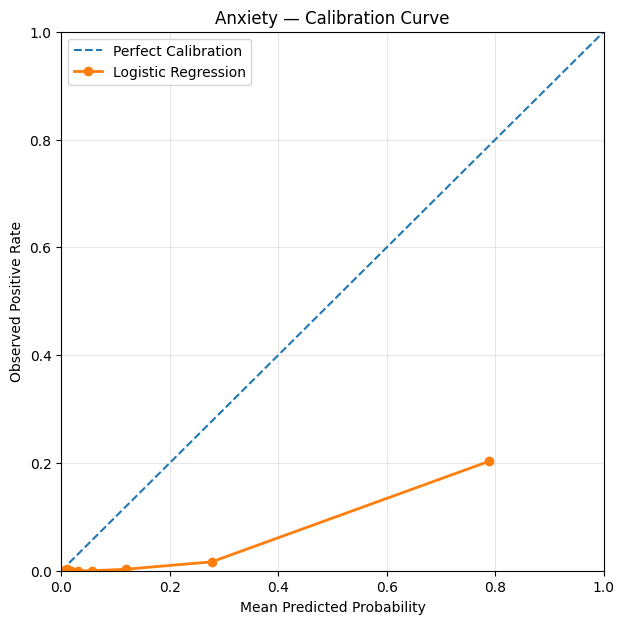

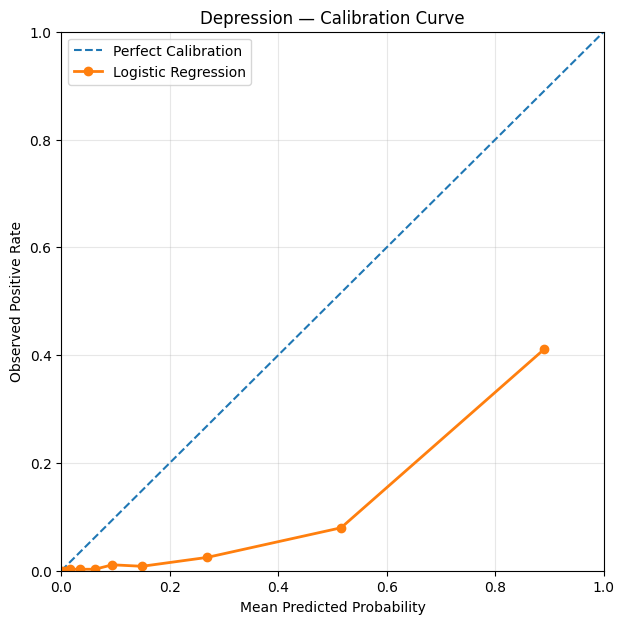

In [ ]:
def plot_calibration_curve(
    calibration_df,
    target_name
):

    plt.figure(figsize=(7, 7))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect Calibration"
    )

    plt.plot(
        calibration_df[
            "Mean_Predicted_Probability"
        ],
        calibration_df[
            "Observed_Positive_Rate"
        ],
        marker="o",
        linewidth=2,
        label="Logistic Regression"
    )

    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Positive Rate")

    plt.title(
        f"{target_name} — Calibration Curve"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()


plot_calibration_curve(
    anxiety_calibration,
    "Anxiety"
)

plot_calibration_curve(
    depression_calibration,
    "Depression"
)

# PROBABILITY CALIBRATION

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("CALIBRATED LOGISTIC REGRESSION")

# SIGMOID / PLATT CALIBRATION
anxiety_calibrated_sigmoid = CalibratedClassifierCV(
    anxiety_model,
    method="sigmoid",
    cv="prefit"
)

depression_calibrated_sigmoid = CalibratedClassifierCV(
    depression_model,
    method="sigmoid",
    cv="prefit"
)


anxiety_calibrated_sigmoid.fit(
    X_val_processed,
    y_val["anxiety_target"]
)

depression_calibrated_sigmoid.fit(
    X_val_processed,
    y_val["depression_target"]
)

print(" Sigmoid calibration completed")

CALIBRATED LOGISTIC REGRESSION
 Sigmoid calibration completed


# PROPER CROSS-VALIDATED CALIBRATION

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

print("CROSS-VALIDATED PROBABILITY CALIBRATION")


# ANXIETY — SIGMOID

anxiety_sigmoid = CalibratedClassifierCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ),
    method="sigmoid",
    cv=5
)

anxiety_sigmoid.fit(
    X_train_processed,
    y_train["anxiety_target"]
)


# DEPRESSION — SIGMOID

depression_sigmoid = CalibratedClassifierCV(
    estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ),
    method="sigmoid",
    cv=5
)

depression_sigmoid.fit(
    X_train_processed,
    y_train["depression_target"]
)


print(" Anxiety calibrated model trained")
print(" Depression calibrated model trained")

CROSS-VALIDATED PROBABILITY CALIBRATION
 Anxiety calibrated model trained
 Depression calibrated model trained


# Evaluate calibration on validation

In [ ]:
def evaluate_calibrated_model(
    model,
    X,
    y,
    target_name
):

    probabilities = model.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    brier = brier_score_loss(
        y,
        probabilities
    )

    roc_auc = roc_auc_score(
        y,
        probabilities
    )

    pr_auc = average_precision_score(
        y,
        probabilities
    )

    print(
        f"{target_name.upper()} — CALIBRATED VALIDATION"
    )

    print(
        f"Brier Score : {brier:.4f}"
    )

    print(
        f"ROC-AUC     : {roc_auc:.4f}"
    )

    print(
        f"PR-AUC      : {pr_auc:.4f}"
    )

    return probabilities


anxiety_calibrated_val_prob = evaluate_calibrated_model(
    anxiety_sigmoid,
    X_val_processed,
    y_val["anxiety_target"],
    "Anxiety"
)


depression_calibrated_val_prob = evaluate_calibrated_model(
    depression_sigmoid,
    X_val_processed,
    y_val["depression_target"],
    "Depression"
)

ANXIETY — CALIBRATED VALIDATION
Brier Score : 0.0118
ROC-AUC     : 0.9716
PR-AUC      : 0.6809
DEPRESSION — CALIBRATED VALIDATION
Brier Score : 0.0301
ROC-AUC     : 0.9434
PR-AUC      : 0.6426


# Random Forest Baseline

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

print("RANDOM FOREST BASELINE")

# RANDOM FOREST — ANXIETY
rf_anxiety = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

rf_anxiety.fit(
    X_train_processed,
    y_train["anxiety_target"]
)

print("✓ Anxiety Random Forest trained")


# RANDOM FOREST — DEPRESSION
rf_depression = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

rf_depression.fit(
    X_train_processed,
    y_train["depression_target"]
)

print(" Depression Random Forest trained")

RANDOM FOREST BASELINE
✓ Anxiety Random Forest trained
 Depression Random Forest trained


# Random Forest Evaluation

In [ ]:
def evaluate_model(
    model,
    X,
    y,
    target_name,
    dataset_name,
    threshold=0.50
):

    probabilities = model.predict_proba(X)[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        predictions,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y,
        predictions
    )

    precision = precision_score(
        y,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y,
        predictions,
        zero_division=0
    )

    specificity = tn / (tn + fp)

    roc_auc = roc_auc_score(
        y,
        probabilities
    )

    pr_auc = average_precision_score(
        y,
        probabilities
    )

    brier = brier_score_loss(
        y,
        probabilities
    )

    results = {
        "Model": "Random Forest",
        "Dataset": dataset_name,
        "Target": target_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Brier_Score": brier
    }

    print(
        f"{target_name.upper()} — {dataset_name.upper()}"
    )

    for key, value in results.items():

        if isinstance(value, float):

            print(
                f"{key:<15}: {value:.4f}"
            )

        else:

            print(
                f"{key:<15}: {value}"
            )

    return results, probabilities

# ANXIETY — VALIDATION
rf_anxiety_val_results, rf_anxiety_val_prob = evaluate_model(
    rf_anxiety,
    X_val_processed,
    y_val["anxiety_target"],
    "Anxiety",
    "Validation"
)

# DEPRESSION — VALIDATION
rf_depression_val_results, rf_depression_val_prob = evaluate_model(
    rf_depression,
    X_val_processed,
    y_val["depression_target"],
    "Depression",
    "Validation"
)


# ANXIETY — TEST
rf_anxiety_test_results, rf_anxiety_test_prob = evaluate_model(
    rf_anxiety,
    X_test_processed,
    y_test["anxiety_target"],
    "Anxiety",
    "Test"
)

# DEPRESSION — TEST
rf_depression_test_results, rf_depression_test_prob = evaluate_model(
    rf_depression,
    X_test_processed,
    y_test["depression_target"],
    "Depression",
    "Test"
)

ANXIETY — VALIDATION
Model          : Random Forest
Dataset        : Validation
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9838
Precision      : 0.6825
Recall         : 0.5244
F1             : 0.5931
Specificity    : 0.9944
ROC_AUC        : 0.9714
PR_AUC         : 0.6227
Brier_Score    : 0.0135
DEPRESSION — VALIDATION
Model          : Random Forest
Dataset        : Validation
Target         : Depression
Threshold      : 0.5000
Accuracy       : 0.9583
Precision      : 0.6513
Recall         : 0.5000
F1             : 0.5657
Specificity    : 0.9846
ROC_AUC        : 0.9388
PR_AUC         : 0.6012
Brier_Score    : 0.0337
ANXIETY — TEST
Model          : Random Forest
Dataset        : Test
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9805
Precision      : 0.5821
Recall         : 0.4756
F1             : 0.5235
Specificity    : 0.9921
ROC_AUC        : 0.9567
PR_AUC         : 0.5295
Brier_Score    : 0.0155
DEPRESSION — TEST
Model          : Random F

# XGBOOST BASELINE

In [ ]:
!pip install -q xgboost

from xgboost import XGBClassifier

print("XGBOOST BASELINE")

XGBOOST BASELINE


In [ ]:
# CLASS IMBALANCE RATIOS

anxiety_neg = (
    y_train["anxiety_target"] == 0
).sum()

anxiety_pos = (
    y_train["anxiety_target"] == 1
).sum()

depression_neg = (
    y_train["depression_target"] == 0
).sum()

depression_pos = (
    y_train["depression_target"] == 1
).sum()


anxiety_scale_pos_weight = (
    anxiety_neg / anxiety_pos
)

depression_scale_pos_weight = (
    depression_neg / depression_pos
)


print(
    f"Anxiety scale_pos_weight    : "
    f"{anxiety_scale_pos_weight:.4f}"
)

print(
    f"Depression scale_pos_weight : "
    f"{depression_scale_pos_weight:.4f}"
)

Anxiety scale_pos_weight    : 43.5131
Depression scale_pos_weight : 17.4625


In [ ]:
from xgboost import XGBClassifier

# XGBOOST — ANXIETY

xgb_anxiety = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=anxiety_scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=SEED,
    n_jobs=-1,

    tree_method="hist"
)

xgb_anxiety.fit(
    X_train_processed,
    y_train["anxiety_target"]
)

print("Anxiety XGBoost trained")

Anxiety XGBoost trained


In [ ]:
# XGBOOST — DEPRESSION

xgb_depression = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=depression_scale_pos_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=SEED,
    n_jobs=-1,

    tree_method="hist"
)

xgb_depression.fit(
    X_train_processed,
    y_train["depression_target"]
)

print("Depression XGBoost trained")

Depression XGBoost trained


# Evaluate XGBoost

In [ ]:
# XGBOOST EVALUATION

xgb_anxiety_val_results, xgb_anxiety_val_prob = evaluate_model(
    xgb_anxiety,
    X_val_processed,
    y_val["anxiety_target"],
    "Anxiety",
    "Validation"
)

xgb_depression_val_results, xgb_depression_val_prob = evaluate_model(
    xgb_depression,
    X_val_processed,
    y_val["depression_target"],
    "Depression",
    "Validation"
)

xgb_anxiety_test_results, xgb_anxiety_test_prob = evaluate_model(
    xgb_anxiety,
    X_test_processed,
    y_test["anxiety_target"],
    "Anxiety",
    "Test"
)

xgb_depression_test_results, xgb_depression_test_prob = evaluate_model(
    xgb_depression,
    X_test_processed,
    y_test["depression_target"],
    "Depression",
    "Test"
)

ANXIETY — VALIDATION
Model          : Random Forest
Dataset        : Validation
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9564
Precision      : 0.3140
Recall         : 0.7927
F1             : 0.4498
Specificity    : 0.9601
ROC_AUC        : 0.9644
PR_AUC         : 0.6255
Brier_Score    : 0.0330
DEPRESSION — VALIDATION
Model          : Random Forest
Dataset        : Validation
Target         : Depression
Threshold      : 0.5000
Accuracy       : 0.8971
Precision      : 0.3205
Recall         : 0.7980
F1             : 0.4573
Specificity    : 0.9028
ROC_AUC        : 0.9393
PR_AUC         : 0.6130
Brier_Score    : 0.0711
ANXIETY — TEST
Model          : Random Forest
Dataset        : Test
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9525
Precision      : 0.2922
Recall         : 0.7805
F1             : 0.4252
Specificity    : 0.9565
ROC_AUC        : 0.9499
PR_AUC         : 0.5630
Brier_Score    : 0.0358
DEPRESSION — TEST
Model          : Random F

# Build the model comparison table

In [ ]:
all_results = []

for variable_name, variable_value in list(globals().items()):

    if (
        variable_name.endswith("_results")
        and isinstance(variable_value, dict)
    ):

        if "Model" in variable_value:

            all_results.append(variable_value)


baseline_comparison = pd.DataFrame(
    all_results
)


comparison_columns = [
    "Model",
    "Dataset",
    "Target",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score"
]

baseline_comparison = baseline_comparison[
    [
        col
        for col in comparison_columns
        if col in baseline_comparison.columns
    ]
]

numeric_columns = baseline_comparison.select_dtypes(
    include=np.number
).columns

baseline_comparison[numeric_columns] = (
    baseline_comparison[numeric_columns]
    .round(4)
)

print("Baseline Model Comparision")

display(baseline_comparison)

Baseline Model Comparision


,Model,Dataset,Target,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Logistic Regression,Validation,Anxiety,0.9256,0.2196,0.9024,0.3532,NaN,0.9716,0.6792,0.0585
1,Logistic Regression,Validation,Depression,0.8839,0.3009,0.8586,0.4456,NaN,0.9434,0.6428,0.0853
2,Logistic Regression,Test,Anxiety,0.9158,0.1935,0.8659,0.3163,NaN,0.9572,0.5483,0.0636
3,Logistic Regression,Test,Depression,0.8699,0.2755,0.8629,0.4177,NaN,0.9374,0.5663,0.0943
4,Random Forest,Validation,Anxiety,0.9838,0.6825,0.5244,0.5931,0.9944,0.9714,0.6227,0.0135
5,Random Forest,Validation,Depression,0.9583,0.6513,0.5000,0.5657,0.9846,0.9388,0.6012,0.0337
6,Random Forest,Test,Anxiety,0.9805,0.5821,0.4756,0.5235,0.9921,0.9567,0.5295,0.0155
7,Random Forest,Test,Depression,0.9468,0.5097,0.4010,0.4489,0.9780,0.9256,0.5235,0.0382
8,Random Forest,Validation,Anxiety,0.9564,0.3140,0.7927,0.4498,0.9601,0.9644,0.6255,0.0330
9,Random Forest,Validation,Depression,0.8971,0.3205,0.7980,0.4573,0.9028,0.9393,0.6130,0.0711


# XGBOOST

In [ ]:
from xgboost import XGBClassifier

print("XGBOOST TRAINING")

# Calculate class weights ONLY from training data

anxiety_neg = (y_train["anxiety_target"] == 0).sum()
anxiety_pos = (y_train["anxiety_target"] == 1).sum()

depression_neg = (y_train["depression_target"] == 0).sum()
depression_pos = (y_train["depression_target"] == 1).sum()

anxiety_weight = anxiety_neg / anxiety_pos
depression_weight = depression_neg / depression_pos

print(
    f"Anxiety class weight    : {anxiety_weight:.4f}"
)

print(
    f"Depression class weight : {depression_weight:.4f}"
)


# ANXIETY
xgb_anxiety = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,

    scale_pos_weight=anxiety_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

xgb_anxiety.fit(
    X_train_processed,
    y_train["anxiety_target"]
)

print(" Anxiety XGBoost trained")


# DEPRESSION

xgb_depression = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,

    scale_pos_weight=depression_weight,

    objective="binary:logistic",
    eval_metric="logloss",

    random_state=SEED,
    n_jobs=-1,
    tree_method="hist"
)

xgb_depression.fit(
    X_train_processed,
    y_train["depression_target"]
)

print(" Depression XGBoost trained")

XGBOOST TRAINING
Anxiety class weight    : 43.5131
Depression class weight : 17.4625
 Anxiety XGBoost trained
 Depression XGBoost trained


# Evaluate XGBoost

In [ ]:
# GENERAL MODEL EVALUATION FUNCTION

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

def evaluate_binary_model(
    model_name,
    dataset_name,
    target_name,
    y_true,
    y_prob,
    threshold=0.50
):

    # Convert probabilities to binary predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    brier = brier_score_loss(
        y_true,
        y_prob
    )

    print(f"{target_name.upper()} — {dataset_name.upper()}")

    print(f"Model          : {model_name}")
    print(f"Dataset        : {dataset_name}")
    print(f"Target         : {target_name}")
    print(f"Threshold      : {threshold:.4f}")

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1             : {f1:.4f}")
    print(f"Specificity    : {specificity:.4f}")
    print(f"ROC_AUC        : {roc_auc:.4f}")
    print(f"PR_AUC         : {pr_auc:.4f}")
    print(f"Brier_Score    : {brier:.4f}")

    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Target": target_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Brier_Score": brier
    }

# XGBOOST — VALIDATION AND TEST EVALUATION

In [ ]:
xgb_results = []

# ANXIETY

# Validation probabilities
xgb_anxiety_val_prob = xgb_anxiety.predict_proba(
    X_val_processed
)[:, 1]

# Test probabilities
xgb_anxiety_test_prob = xgb_anxiety.predict_proba(
    X_test_processed
)[:, 1]


# Validation
result = evaluate_binary_model(
    model_name="XGBoost",
    dataset_name="Validation",
    target_name="Anxiety",
    y_true=y_val["anxiety_target"],
    y_prob=xgb_anxiety_val_prob,
    threshold=0.50
)

xgb_results.append(result)


# Test
result = evaluate_binary_model(
    model_name="XGBoost",
    dataset_name="Test",
    target_name="Anxiety",
    y_true=y_test["anxiety_target"],
    y_prob=xgb_anxiety_test_prob,
    threshold=0.50
)

xgb_results.append(result)


# DEPRESSION

# Validation probabilities
xgb_depression_val_prob = xgb_depression.predict_proba(
    X_val_processed
)[:, 1]

# Test probabilities
xgb_depression_test_prob = xgb_depression.predict_proba(
    X_test_processed
)[:, 1]


# Validation
result = evaluate_binary_model(
    model_name="XGBoost",
    dataset_name="Validation",
    target_name="Depression",
    y_true=y_val["depression_target"],
    y_prob=xgb_depression_val_prob,
    threshold=0.50
)

xgb_results.append(result)


# Test
result = evaluate_binary_model(
    model_name="XGBoost",
    dataset_name="Test",
    target_name="Depression",
    y_true=y_test["depression_target"],
    y_prob=xgb_depression_test_prob,
    threshold=0.50
)

xgb_results.append(result)

ANXIETY — VALIDATION
Model          : XGBoost
Dataset        : Validation
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9569
Precision      : 0.3188
Recall         : 0.8049
F1             : 0.4567
Specificity    : 0.9604
ROC_AUC        : 0.9645
PR_AUC         : 0.6206
Brier_Score    : 0.0334
ANXIETY — TEST
Model          : XGBoost
Dataset        : Test
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9528
Precision      : 0.2917
Recall         : 0.7683
F1             : 0.4228
Specificity    : 0.9570
ROC_AUC        : 0.9514
PR_AUC         : 0.5578
Brier_Score    : 0.0364
DEPRESSION — VALIDATION
Model          : XGBoost
Dataset        : Validation
Target         : Depression
Threshold      : 0.5000
Accuracy       : 0.8971
Precision      : 0.3219
Recall         : 0.8081
F1             : 0.4604
Specificity    : 0.9022
ROC_AUC        : 0.9399
PR_AUC         : 0.6171
Brier_Score    : 0.0716
DEPRESSION — TEST
Model          : XGBoost
Dataset        : T

# XGBOOST HYPERPARAMETER OPTIMIZATION

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

print("XGBOOST HYPERPARAMETER OPTIMIZATION")

# SEARCH SPACE
xgb_param_grid = {

    "n_estimators": [
        100,
        200,
        300,
        500
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10
    ],

    "min_child_weight": [
        1,
        3,
        5,
        10
    ],

    "subsample": [
        0.70,
        0.80,
        0.90,
        1.00
    ],

    "colsample_bytree": [
        0.70,
        0.80,
        0.90,
        1.00
    ],

    "gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda": [
        1,
        2,
        5,
        10
    ]
}


# CROSS-VALIDATION
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)



# ANXIETY OPTIMIZATION
print("OPTIMIZING ANXIETY MODEL")


anxiety_positive_weight = (
    (y_train["anxiety_target"] == 0).sum()
    /
    (y_train["anxiety_target"] == 1).sum()
)

print(
    f"Anxiety scale_pos_weight: "
    f"{anxiety_positive_weight:.4f}"
)


xgb_anxiety_search_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="aucpr",

    scale_pos_weight=anxiety_positive_weight,

    random_state=SEED,

    n_jobs=-1,

    tree_method="hist"
)


anxiety_search = RandomizedSearchCV(

    estimator=xgb_anxiety_search_model,

    param_distributions=xgb_param_grid,

    n_iter=30,

    scoring="average_precision",

    cv=cv_strategy,

    verbose=1,

    random_state=SEED,

    n_jobs=-1,

    refit=True
)


anxiety_search.fit(
    X_train_processed,
    y_train["anxiety_target"]
)


print("\nBEST ANXIETY PARAMETERS")
print(
    anxiety_search.best_params_
)

print(
    f"Best CV PR-AUC: "
    f"{anxiety_search.best_score_:.4f}"
)


# DEPRESSION OPTIMIZATION
print("OPTIMIZING DEPRESSION MODEL")

depression_positive_weight = (
    (y_train["depression_target"] == 0).sum()
    /
    (y_train["depression_target"] == 1).sum()
)

print(
    f"Depression scale_pos_weight: "
    f"{depression_positive_weight:.4f}"
)


xgb_depression_search_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="aucpr",

    scale_pos_weight=depression_positive_weight,

    random_state=SEED,

    n_jobs=-1,

    tree_method="hist"
)


depression_search = RandomizedSearchCV(

    estimator=xgb_depression_search_model,

    param_distributions=xgb_param_grid,

    n_iter=30,

    scoring="average_precision",

    cv=cv_strategy,

    verbose=1,

    random_state=SEED,

    n_jobs=-1,

    refit=True
)


depression_search.fit(
    X_train_processed,
    y_train["depression_target"]
)


print("\nBEST DEPRESSION PARAMETERS")
print(
    depression_search.best_params_
)

print(
    f"Best CV PR-AUC: "
    f"{depression_search.best_score_:.4f}"
)

XGBOOST HYPERPARAMETER OPTIMIZATION
OPTIMIZING ANXIETY MODEL
Anxiety scale_pos_weight: 43.5131
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST ANXIETY PARAMETERS
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV PR-AUC: 0.6010
OPTIMIZING DEPRESSION MODEL
Depression scale_pos_weight: 17.4625
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST DEPRESSION PARAMETERS
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.6278


# Train the optimized XGBoost models

In [ ]:
print("TRAINING OPTIMIZED XGBOOST MODELS")

# BEST PARAMETERS FOUND BY OPTIMIZATION
best_params_anxiety = {
    'subsample': 1.0,
    'reg_lambda': 2,
    'reg_alpha': 0.1,
    'n_estimators': 200,
    'min_child_weight': 10,
    'max_depth': 3,
    'learning_rate': 0.03,
    'gamma': 0.1,
    'colsample_bytree': 0.9
}

best_params_depression = {
    'subsample': 0.9,
    'reg_lambda': 5,
    'reg_alpha': 0,
    'n_estimators': 500,
    'min_child_weight': 3,
    'max_depth': 2,
    'learning_rate': 0.03,
    'gamma': 0,
    'colsample_bytree': 0.8
}

# ANXIETY MODEL
xgb_anxiety_optimized = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=anxiety_scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    **best_params_anxiety
)

xgb_anxiety_optimized.fit(
    X_train_processed,
    y_train["anxiety_target"]
)

print(" Optimized Anxiety XGBoost trained")


# DEPRESSION MODEL
xgb_depression_optimized = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=depression_scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    **best_params_depression
)

xgb_depression_optimized.fit(
    X_train_processed,
    y_train["depression_target"]
)

print(" Optimized Depression XGBoost trained")

TRAINING OPTIMIZED XGBOOST MODELS
 Optimized Anxiety XGBoost trained
 Optimized Depression XGBoost trained


# Evaluate the optimized XGBoost models

In [ ]:
print("VALIDATION AND TEST EVALUATION")


# ANXIETY
anxiety_val_prob_opt = xgb_anxiety_optimized.predict_proba(
    X_val_processed
)[:, 1]

anxiety_test_prob_opt = xgb_anxiety_optimized.predict_proba(
    X_test_processed
)[:, 1]


# DEPRESSION
depression_val_prob_opt = xgb_depression_optimized.predict_proba(
    X_val_processed
)[:, 1]

depression_test_prob_opt = xgb_depression_optimized.predict_proba(
    X_test_processed
)[:, 1]


# Anxiety - Validation
evaluate_binary_model(
    model_name="Optimized XGBoost",
    dataset_name="Validation",
    target_name="Anxiety",
    y_true=y_val["anxiety_target"],
    y_prob=anxiety_val_prob_opt,
    threshold=0.5
)

# Anxiety - Test
evaluate_binary_model(
    model_name="Optimized XGBoost",
    dataset_name="Test",
    target_name="Anxiety",
    y_true=y_test["anxiety_target"],
    y_prob=anxiety_test_prob_opt,
    threshold=0.5
)

# Depression - Validation
evaluate_binary_model(
    model_name="Optimized XGBoost",
    dataset_name="Validation",
    target_name="Depression",
    y_true=y_val["depression_target"],
    y_prob=depression_val_prob_opt,
    threshold=0.5
)

# Depression - Test
evaluate_binary_model(
    model_name="Optimized XGBoost",
    dataset_name="Test",
    target_name="Depression",
    y_true=y_test["depression_target"],
    y_prob=depression_test_prob_opt,
    threshold=0.5
)

VALIDATION AND TEST EVALUATION
ANXIETY — VALIDATION
Model          : Optimized XGBoost
Dataset        : Validation
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9341
Precision      : 0.2401
Recall         : 0.8902
F1             : 0.3782
Specificity    : 0.9351
ROC_AUC        : 0.9702
PR_AUC         : 0.6491
Brier_Score    : 0.0503
ANXIETY — TEST
Model          : Optimized XGBoost
Dataset        : Test
Target         : Anxiety
Threshold      : 0.5000
Accuracy       : 0.9292
Precision      : 0.2215
Recall         : 0.8537
F1             : 0.3518
Specificity    : 0.9309
ROC_AUC        : 0.9601
PR_AUC         : 0.5650
Brier_Score    : 0.0542
DEPRESSION — VALIDATION
Model          : Optimized XGBoost
Dataset        : Validation
Target         : Depression
Threshold      : 0.5000
Accuracy       : 0.8828
Precision      : 0.3002
Recall         : 0.8687
F1             : 0.4462
Specificity    : 0.8836
ROC_AUC        : 0.9447
PR_AUC         : 0.6324
Brier_Score    : 0.0841


{'Model': 'Optimized XGBoost',
 'Dataset': 'Test',
 'Target': 'Depression',
 'Threshold': 0.5,
 'Accuracy': 0.8696487376509331,
 'Precision': 0.272875816993464,
 'Recall': 0.8477157360406091,
 'F1': 0.41285537700865266,
 'Specificity': np.float64(0.8709022338265158),
 'ROC_AUC': np.float64(0.9385826562934885),
 'PR_AUC': np.float64(0.5571471327101127),
 'Brier_Score': np.float64(0.09209151984093494)}

# Optimized XGBoost threshold analysis

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("OPTIMIZED XGBOOST — THRESHOLD OPTIMIZATION")


def threshold_analysis(
    y_true,
    y_prob,
    target_name,
    model_name="Optimized XGBoost"
):

    thresholds = np.arange(0.05, 0.96, 0.05)

    results = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )

        results.append({
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Specificity": specificity,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn
        })

    results_df = pd.DataFrame(results)

    # Best F1 threshold
    best_idx = results_df["F1"].idxmax()

    best_row = results_df.loc[best_idx]

    print(f"{target_name.upper()} — THRESHOLD RESULTS")

    display(
        results_df.style.format({
            "Threshold": "{:.2f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Specificity": "{:.4f}"
        })
    )

    print(f"BEST F1 THRESHOLD — {target_name.upper()}")

    print(f"Threshold   : {best_row['Threshold']:.2f}")
    print(f"Precision   : {best_row['Precision']:.4f}")
    print(f"Recall      : {best_row['Recall']:.4f}")
    print(f"F1          : {best_row['F1']:.4f}")
    print(f"Specificity : {best_row['Specificity']:.4f}")
    print(f"TP          : {int(best_row['TP'])}")
    print(f"FP          : {int(best_row['FP'])}")
    print(f"TN          : {int(best_row['TN'])}")
    print(f"FN          : {int(best_row['FN'])}")

    return results_df, float(best_row["Threshold"])

# VALIDATION PROBABILITIES
anxiety_val_prob_opt = xgb_anxiety_optimized.predict_proba(
    X_val_processed
)[:, 1]

depression_val_prob_opt = xgb_depression_optimized.predict_proba(
    X_val_processed
)[:, 1]


# ANXIETY
anxiety_threshold_results, anxiety_best_threshold = threshold_analysis(
    y_val["anxiety_target"],
    anxiety_val_prob_opt,
    "Anxiety"
)


# DEPRESSION
depression_threshold_results, depression_best_threshold = threshold_analysis(
    y_val["depression_target"],
    depression_val_prob_opt,
    "Depression"
)


print("SELECTED VALIDATION THRESHOLDS")

print(
    f"Anxiety    : {anxiety_best_threshold:.2f}"
)

print(
    f"Depression : {depression_best_threshold:.2f}"
)

OPTIMIZED XGBOOST — THRESHOLD OPTIMIZATION

ANXIETY — THRESHOLD RESULTS


,Threshold,Precision,Recall,F1,Specificity,TP,FP,TN,FN
0,0.05,0.0584,0.9878,0.1104,0.6336,81,1305,2257,1
1,0.10,0.0867,0.9878,0.1594,0.7605,81,853,2709,1
2,0.15,0.1116,0.9756,0.2003,0.8212,80,637,2925,2
3,0.20,0.1310,0.9390,0.2299,0.8565,77,511,3051,5
4,0.25,0.1531,0.9146,0.2622,0.8835,75,415,3147,7
5,0.30,0.1685,0.9146,0.2846,0.8961,75,370,3192,7
6,0.35,0.1897,0.9024,0.3136,0.9113,74,316,3246,8
7,0.40,0.2011,0.9024,0.3289,0.9175,74,294,3268,8
8,0.45,0.2199,0.8902,0.3527,0.9273,73,259,3303,9
9,0.50,0.2401,0.8902,0.3782,0.9351,73,231,3331,9


BEST F1 THRESHOLD — ANXIETY
Threshold   : 0.90
Precision   : 0.5225
Recall      : 0.7073
F1          : 0.6010
Specificity : 0.9851
TP          : 58
FP          : 53
TN          : 3509
FN          : 24

DEPRESSION — THRESHOLD RESULTS


,Threshold,Precision,Recall,F1,Specificity,TP,FP,TN,FN
0,0.05,0.0954,0.9949,0.1741,0.4579,197,1868,1578,1
1,0.10,0.1360,0.9646,0.2385,0.6480,191,1213,2233,7
2,0.15,0.1661,0.9596,0.2832,0.7232,190,954,2492,8
3,0.20,0.1851,0.9545,0.3101,0.7586,189,832,2614,9
4,0.25,0.2051,0.9394,0.3367,0.7908,186,721,2725,12
5,0.30,0.2218,0.9242,0.3578,0.8137,183,642,2804,15
6,0.35,0.2378,0.9091,0.3770,0.8326,180,577,2869,18
7,0.40,0.2595,0.8990,0.4027,0.8526,178,508,2938,20
8,0.45,0.2843,0.8990,0.4320,0.8700,178,448,2998,20
9,0.50,0.3002,0.8687,0.4462,0.8836,172,401,3045,26


BEST F1 THRESHOLD — DEPRESSION
Threshold   : 0.90
Precision   : 0.5924
Recall      : 0.5505
F1          : 0.5707
Specificity : 0.9782
TP          : 109
FP          : 75
TN          : 3371
FN          : 89
SELECTED VALIDATION THRESHOLDS
Anxiety    : 0.90
Depression : 0.90


# Evaluate those thresholds on TEST

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix
)

print("FINAL TEST EVALUATION USING VALIDATION-SELECTED THRESHOLDS")


def evaluate_at_threshold(
    y_true,
    y_prob,
    threshold,
    target_name,
    model_name="Optimized XGBoost"
):

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    brier = brier_score_loss(
        y_true,
        y_prob
    )

    result = {
        "Model": model_name,
        "Dataset": "Test",
        "Target": target_name,
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Brier_Score": brier
    }

    print(f"{target_name.upper()} — TEST")

    for key, value in result.items():

        if isinstance(value, (float, np.floating)):

            print(
                f"{key:<15}: {value:.4f}"
            )

        else:

            print(
                f"{key:<15}: {value}"
            )

    print("\nConfusion Matrix:")
    print(
        pd.DataFrame(
            [[tn, fp], [fn, tp]],
            index=["Actual 0", "Actual 1"],
            columns=["Predicted 0", "Predicted 1"]
        )
    )

    return result


# TEST PROBABILITIES
anxiety_test_prob_opt = xgb_anxiety_optimized.predict_proba(
    X_test_processed
)[:, 1]

depression_test_prob_opt = xgb_depression_optimized.predict_proba(
    X_test_processed
)[:, 1]


# FINAL TEST EVALUATION
optimized_anxiety_final = evaluate_at_threshold(
    y_test["anxiety_target"],
    anxiety_test_prob_opt,
    anxiety_best_threshold,
    "Anxiety"
)

optimized_depression_final = evaluate_at_threshold(
    y_test["depression_target"],
    depression_test_prob_opt,
    depression_best_threshold,
    "Depression"
)

FINAL TEST EVALUATION USING VALIDATION-SELECTED THRESHOLDS
ANXIETY — TEST
Model          : Optimized XGBoost
Dataset        : Test
Target         : Anxiety
Threshold      : 0.9000
Accuracy       : 0.9759
Precision      : 0.4717
Recall         : 0.6098
F1             : 0.5319
Specificity    : 0.9843
ROC_AUC        : 0.9601
PR_AUC         : 0.5650
Brier_Score    : 0.0542

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0         3506           56
Actual 1           32           50
DEPRESSION — TEST
Model          : Optimized XGBoost
Dataset        : Test
Target         : Depression
Threshold      : 0.9000
Accuracy       : 0.9462
Precision      : 0.5025
Recall         : 0.5127
F1             : 0.5075
Specificity    : 0.9710
ROC_AUC        : 0.9386
PR_AUC         : 0.5571
Brier_Score    : 0.0921

Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0         3347          100
Actual 1           96          101


# OPTIMIZED XGBOOST — PROBABILITY CALIBRATION

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score
)

print("OPTIMIZED XGBOOST — PROBABILITY CALIBRATION")


# CALIBRATE ANXIETY MODEL
print("\nCalibrating Anxiety XGBoost...")

calibrated_anxiety_model = CalibratedClassifierCV(
    estimator=xgb_anxiety_optimized,
    method="sigmoid",
    cv="prefit"
)

calibrated_anxiety_model.fit(
    X_val_processed,
    y_val["anxiety_target"]
)


# CALIBRATE DEPRESSION MODEL
print("Calibrating Depression XGBoost...")

calibrated_depression_model = CalibratedClassifierCV(
    estimator=xgb_depression_optimized,
    method="sigmoid",
    cv="prefit"
)

calibrated_depression_model.fit(
    X_val_processed,
    y_val["depression_target"]
)


print("\n Calibration models created")

OPTIMIZED XGBOOST — PROBABILITY CALIBRATION

Calibrating Anxiety XGBoost...
Calibrating Depression XGBoost...

 Calibration models created


# CALIBRATED MODEL EVALUATION

In [ ]:
print("CALIBRATED OPTIMIZED XGBOOST — TEST")


# TEST PROBABILITIES
calibrated_anxiety_test_prob = (
    calibrated_anxiety_model
    .predict_proba(X_test_processed)[:, 1]
)

calibrated_depression_test_prob = (
    calibrated_depression_model
    .predict_proba(X_test_processed)[:, 1]
)


# ANXIETY
anxiety_brier_calibrated = brier_score_loss(
    y_test["anxiety_target"],
    calibrated_anxiety_test_prob
)

anxiety_roc_calibrated = roc_auc_score(
    y_test["anxiety_target"],
    calibrated_anxiety_test_prob
)

anxiety_pr_calibrated = average_precision_score(
    y_test["anxiety_target"],
    calibrated_anxiety_test_prob
)


print("\nANXIETY — CALIBRATED TEST")

print(
    f"Brier Score : {anxiety_brier_calibrated:.4f}"
)

print(
    f"ROC-AUC     : {anxiety_roc_calibrated:.4f}"
)

print(
    f"PR-AUC      : {anxiety_pr_calibrated:.4f}"
)


# DEPRESSION
depression_brier_calibrated = brier_score_loss(
    y_test["depression_target"],
    calibrated_depression_test_prob
)

depression_roc_calibrated = roc_auc_score(
    y_test["depression_target"],
    calibrated_depression_test_prob
)

depression_pr_calibrated = average_precision_score(
    y_test["depression_target"],
    calibrated_depression_test_prob
)


print("\nDEPRESSION — CALIBRATED TEST")

print(
    f"Brier Score : {depression_brier_calibrated:.4f}"
)

print(
    f"ROC-AUC     : {depression_roc_calibrated:.4f}"
)

print(
    f"PR-AUC      : {depression_pr_calibrated:.4f}"
)


CALIBRATED OPTIMIZED XGBOOST — TEST

ANXIETY — CALIBRATED TEST
Brier Score : 0.0151
ROC-AUC     : 0.9601
PR-AUC      : 0.5650

DEPRESSION — CALIBRATED TEST
Brier Score : 0.0355
ROC-AUC     : 0.9386
PR-AUC      : 0.5571


# SHAP Explainability

In [ ]:
import shap

print("SHAP EXPLAINABILITY")

print("SHAP version:", shap.__version__)

SHAP EXPLAINABILITY
SHAP version: 0.52.0


# Create SHAP explainers

In [ ]:
print("\nCreating SHAP explainers...")

anxiety_explainer = shap.TreeExplainer(
    xgb_anxiety_optimized
)

depression_explainer = shap.TreeExplainer(
    xgb_depression_optimized
)

print(" Anxiety SHAP explainer created")
print(" Depression SHAP explainer created")


Creating SHAP explainers...
 Anxiety SHAP explainer created
 Depression SHAP explainer created


# SHAP ANALYSIS SAMPLE

In [ ]:
SHAP_SAMPLE_SIZE = min(1000, len(X_test_processed))

np.random.seed(SEED)

shap_indices = np.random.choice(
    len(X_test_processed),
    size=SHAP_SAMPLE_SIZE,
    replace=False
)

X_shap = X_test_processed[shap_indices]

print("\nSHAP SAMPLE")
print("Total test samples :", len(X_test_processed))
print("SHAP samples       :", len(X_shap))


SHAP SAMPLE
Total test samples : 3644
SHAP samples       : 1000


# Calculate SHAP values

In [ ]:
print("\nCalculating Anxiety SHAP values...")

anxiety_shap_values = anxiety_explainer.shap_values(
    X_shap
)

print(" Anxiety SHAP values calculated")

print("\nCalculating Depression SHAP values...")

depression_shap_values = depression_explainer.shap_values(
    X_shap
)

print(" Depression SHAP values calculated")


Calculating Anxiety SHAP values...
 Anxiety SHAP values calculated

Calculating Depression SHAP values...
 Depression SHAP values calculated


# Get transformed feature names

In [ ]:
# GET FEATURE NAMES
feature_names = preprocessor.get_feature_names_out()

print("\nTRANSFORMED FEATURE INFORMATION")

print("Number of transformed features:", len(feature_names))

print("\nFeature names:")

for i, feature in enumerate(feature_names):
    print(f"{i:3d} : {feature}")


TRANSFORMED FEATURE INFORMATION
Number of transformed features: 36

Feature names:
  0 : numeric__age
  1 : numeric__isi_q1
  2 : numeric__isi_q2
  3 : numeric__isi_q3
  4 : numeric__isi_q4
  5 : numeric__isi_q5
  6 : numeric__isi_q6
  7 : numeric__isi_q7
  8 : numeric__pss_q1
  9 : numeric__pss_q2
 10 : numeric__pss_q3
 11 : numeric__pss_q4
 12 : numeric__pss_q5
 13 : numeric__pss_q6
 14 : numeric__pss_q7
 15 : numeric__pss_q8
 16 : numeric__pss_q9
 17 : numeric__pss_q10
 18 : numeric__pss_q11
 19 : numeric__pss_q12
 20 : numeric__pss_q13
 21 : numeric__pss_q14
 22 : categorical__gender_female
 23 : categorical__gender_male
 24 : categorical__edu_associate degree
 25 : categorical__edu_bachelor's degree
 26 : categorical__edu_doctorate degree
 27 : categorical__edu_master's degree
 28 : categorical__smoke_current smoker (cumulative smoking >10 packs)
 29 : categorical__smoke_former smoker (cumulative smoking >10 packs), but not in the past year
 30 : categorical__smoke_never smokes
 

# Global SHAP Analysis

# Anxiety

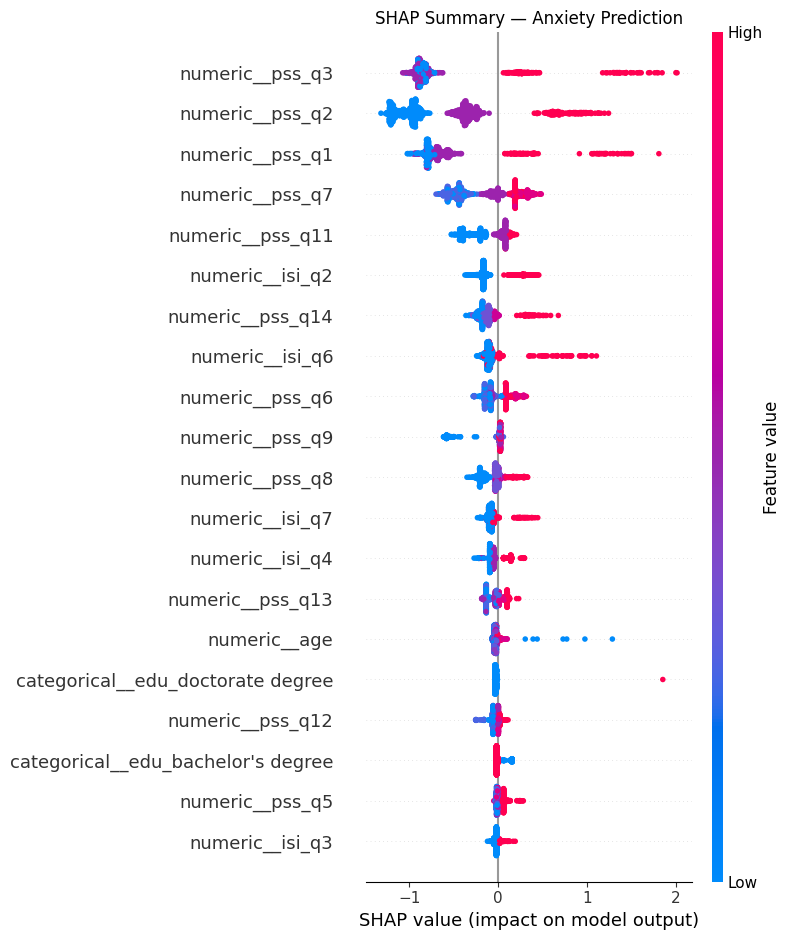

In [ ]:
# SHAP SUMMARY — ANXIETY

plt.figure(figsize=(10, 8))

shap.summary_plot(
    anxiety_shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Summary — Anxiety Prediction"
)

plt.tight_layout()
plt.show()

# Depression

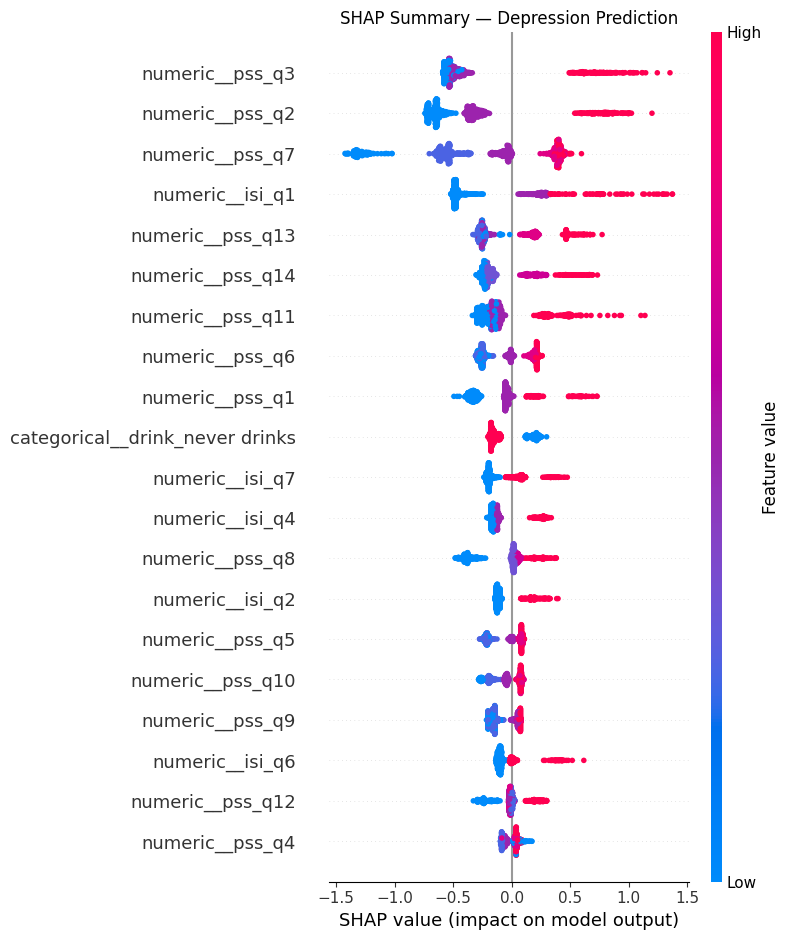

In [ ]:
# SHAP SUMMARY — DEPRESSION

plt.figure(figsize=(10, 8))

shap.summary_plot(
    depression_shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title(
    "SHAP Summary — Depression Prediction"
)

plt.tight_layout()
plt.show()

# Get the actual top features numerically

In [ ]:
# TOP SHAP FEATURES — ANXIETY
anxiety_mean_abs_shap = np.abs(
    anxiety_shap_values
).mean(axis=0)

anxiety_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": anxiety_mean_abs_shap
})

anxiety_feature_importance = (
    anxiety_feature_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("TOP SHAP FEATURES — ANXIETY")

display(
    anxiety_feature_importance.head(20)
)

TOP SHAP FEATURES — ANXIETY


,Feature,Mean_Absolute_SHAP
0,numeric__pss_q3,0.830018
1,numeric__pss_q2,0.751109
2,numeric__pss_q1,0.712445
3,numeric__pss_q7,0.319596
4,numeric__pss_q11,0.194910
5,numeric__isi_q2,0.194582
6,numeric__pss_q14,0.157788
7,numeric__isi_q6,0.129833
8,numeric__pss_q6,0.117829
9,numeric__pss_q9,0.103900


In [ ]:
# TOP SHAP FEATURES — DEPRESSION

depression_mean_abs_shap = np.abs(
    depression_shap_values
).mean(axis=0)

depression_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": depression_mean_abs_shap
})

depression_feature_importance = (
    depression_feature_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("TOP SHAP FEATURES — DEPRESSION")

display(
    depression_feature_importance.head(20)
)

TOP SHAP FEATURES — DEPRESSION


,Feature,Mean_Absolute_SHAP
0,numeric__pss_q3,0.544038
1,numeric__pss_q2,0.543959
2,numeric__pss_q7,0.504343
3,numeric__isi_q1,0.438467
4,numeric__pss_q13,0.273019
5,numeric__pss_q14,0.227951
6,numeric__pss_q11,0.207213
7,numeric__pss_q6,0.202273
8,numeric__pss_q1,0.199238
9,categorical__drink_never drinks,0.168762


# SHAP bar plots

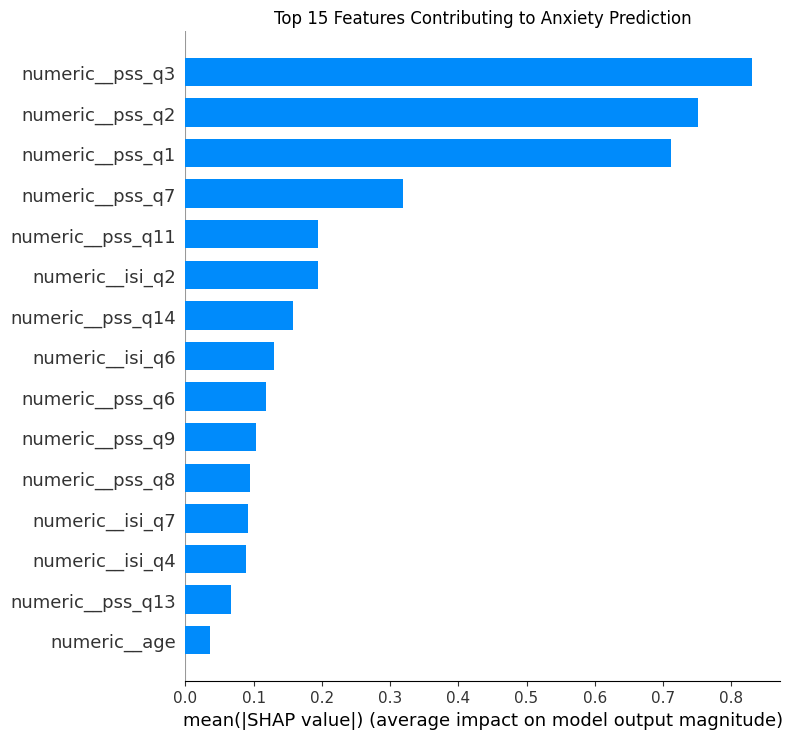

In [ ]:
# SHAP BAR PLOT — ANXIETY

plt.figure(figsize=(10, 7))

shap.summary_plot(
    anxiety_shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Top 15 Features Contributing to Anxiety Prediction"
)

plt.tight_layout()
plt.show()

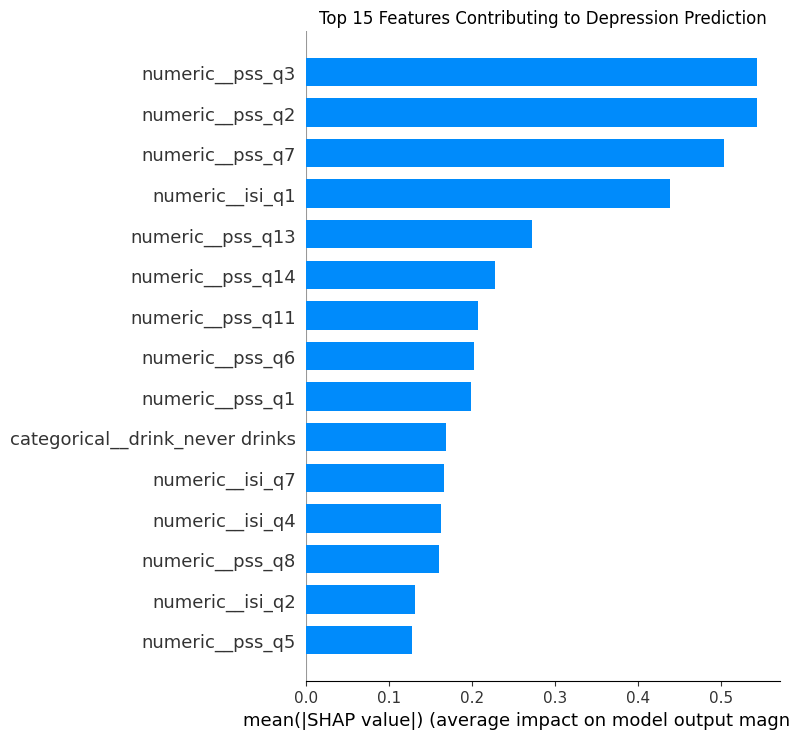

In [ ]:
# SHAP BAR PLOT — DEPRESSION

plt.figure(figsize=(10, 7))

shap.summary_plot(
    depression_shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Top 15 Features Contributing to Depression Prediction"
)

plt.tight_layout()
plt.show()

# LOCAL EXPLAINABILITY

In [ ]:
print("LOCAL SHAP EXPLANATIONS")

# Select a few test participants
sample_indices = X_test.index[:5]

# Transformed test data
X_test_transformed = preprocessor.transform(X_test)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()


# SHAP EXPLAINER
anxiety_explainer = shap.TreeExplainer(xgb_anxiety_optimized)
depression_explainer = shap.TreeExplainer(xgb_depression_optimized)

# SHAP values
anxiety_shap_values = anxiety_explainer.shap_values(
    X_test_transformed
)

depression_shap_values = depression_explainer.shap_values(
    X_test_transformed
)

print(" Anxiety SHAP values generated")
print(" Depression SHAP values generated")


# Check SHAP dimensions
print("\nSHAP dimensions:")
print("Anxiety   :", np.array(anxiety_shap_values).shape)
print("Depression:", np.array(depression_shap_values).shape)


LOCAL SHAP EXPLANATIONS
 Anxiety SHAP values generated
 Depression SHAP values generated

SHAP dimensions:
Anxiety   : (3644, 36)
Depression: (3644, 36)


# Create a local explanation function

In [ ]:
# LOCAL PARTICIPANT EXPLANATION FUNCTION

def explain_participant(
    participant_position,
    target_name,
    shap_values,
    X_transformed,
    feature_names,
    model,
    threshold
):

    # Participant data
    x = X_transformed[participant_position].reshape(1, -1)

    # Prediction probability
    probability = model.predict_proba(x)[0, 1]

    prediction = int(probability >= threshold)

    # SHAP values for participant
    participant_shap = np.array(
        shap_values[participant_position]
    ).flatten()


    # Rank features by absolute SHAP value
    explanation_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP_Value": participant_shap,
        "Absolute_SHAP": np.abs(participant_shap),
        "Feature_Value": X_transformed[
            participant_position
        ]
    })

    explanation_df = explanation_df.sort_values(
        "Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    # Display
    print(f"LOCAL EXPLANATION — {target_name}")

    print(f"Participant position : {participant_position}")
    print(f"Predicted probability : {probability:.4f}")
    print(f"Decision threshold    : {threshold:.4f}")
    print(f"Predicted class       : {prediction}")

    print("\nTop contributing features:")

    display(
        explanation_df[
            [
                "Feature",
                "SHAP_Value",
                "Absolute_SHAP"
            ]
        ].head(10)
    )

    return explanation_df, probability, prediction

# Explain one anxiety participant

In [ ]:
anxiety_local_df, anxiety_probability, anxiety_prediction = explain_participant(
    participant_position=0,
    target_name="Anxiety",
    shap_values=anxiety_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_anxiety_optimized,
    threshold=0.90
)

LOCAL EXPLANATION — Anxiety
Participant position : 0
Predicted probability : 0.0570
Decision threshold    : 0.9000
Predicted class       : 0

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q3,-0.837390,0.837390
1,numeric__pss_q1,-0.667641,0.667641
2,numeric__pss_q7,-0.542738,0.542738
3,numeric__pss_q2,-0.483348,0.483348
4,numeric__isi_q2,0.285484,0.285484
5,numeric__pss_q6,-0.151326,0.151326
6,numeric__pss_q11,0.108111,0.108111
7,numeric__isi_q6,-0.103912,0.103912
8,numeric__isi_q4,-0.088434,0.088434
9,numeric__pss_q14,-0.088062,0.088062


# Explain one depression participant

In [ ]:
depression_local_df, depression_probability, depression_prediction = explain_participant(
    participant_position=0,
    target_name="Depression",
    shap_values=depression_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_depression_optimized,
    threshold=0.90
)

LOCAL EXPLANATION — Depression
Participant position : 0
Predicted probability : 0.2803
Decision threshold    : 0.9000
Predicted class       : 0

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q11,0.451713,0.451713
1,numeric__pss_q7,-0.447994,0.447994
2,numeric__pss_q3,-0.438385,0.438385
3,numeric__pss_q2,-0.305675,0.305675
4,numeric__pss_q6,-0.270893,0.270893
5,numeric__pss_q13,-0.226365,0.226365
6,numeric__isi_q1,0.213478,0.213478
7,numeric__isi_q2,0.200706,0.200706
8,numeric__isi_q5,0.191743,0.191743
9,categorical__drink_never drinks,-0.184671,0.184671


# Generate actual SHAP waterfall plots

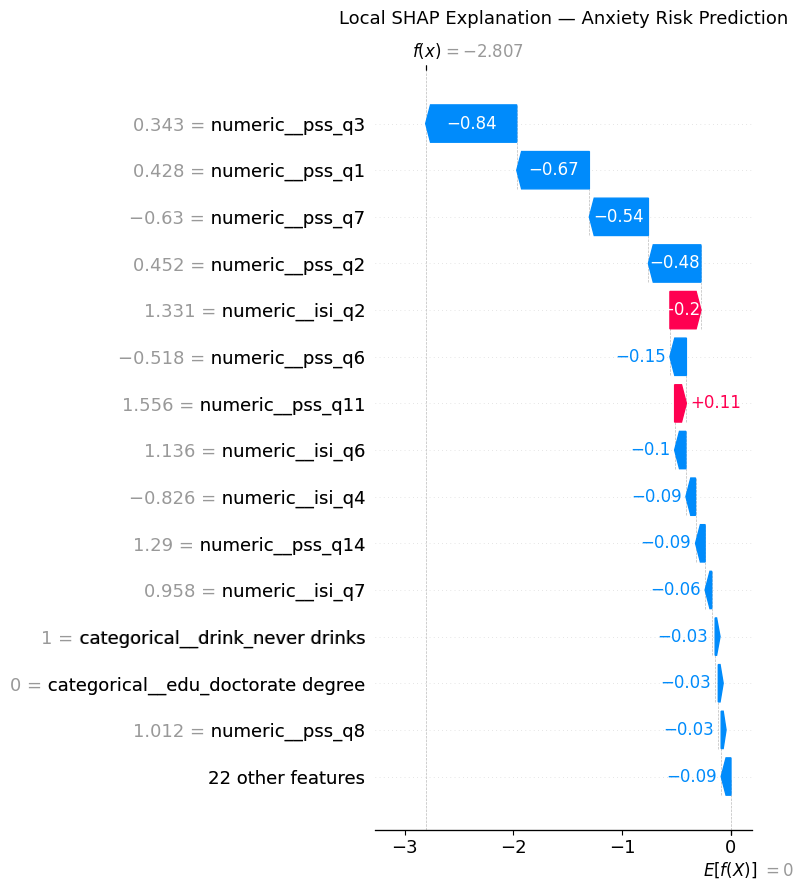

In [ ]:
# ANXIETY — LOCAL WATERFALL EXPLANATION

anxiety_explanation = shap.Explanation(
    values=anxiety_shap_values[0],
    base_values=anxiety_explainer.expected_value,
    data=X_test_transformed[0],
    feature_names=feature_names
)

# Create the waterfall plot
shap.plots.waterfall(
    anxiety_explanation,
    max_display=15,
    show=False
)

# Add title
plt.title(
    "Local SHAP Explanation — Anxiety Risk Prediction",
    fontsize=13,
    pad=12
)

plt.tight_layout()
plt.show()

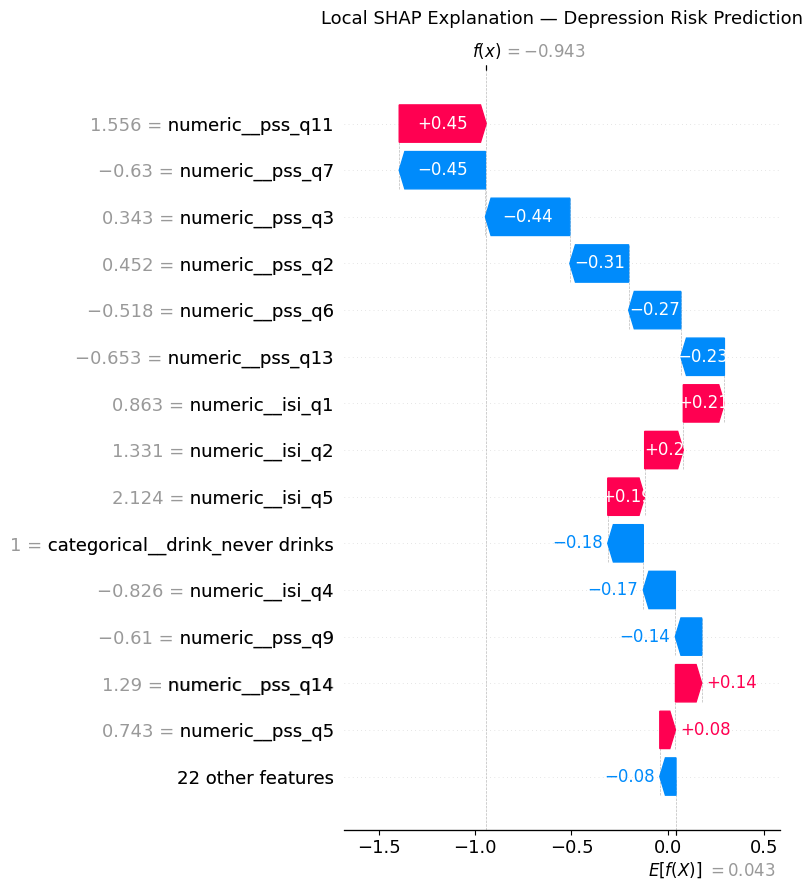

In [ ]:
# DEPRESSION — LOCAL WATERFALL EXPLANATION

depression_explanation = shap.Explanation(
    values=depression_shap_values[0],
    base_values=depression_explainer.expected_value,
    data=X_test_transformed[0],
    feature_names=feature_names
)

# Create the waterfall plot
shap.plots.waterfall(
    depression_explanation,
    max_display=15,
    show=False
)

# Add title
plt.title(
    "Local SHAP Explanation — Depression Risk Prediction",
    fontsize=13,
    pad=12
)

plt.tight_layout()
plt.show()

# SELECT REPRESENTATIVE TEST PARTICIPANTS

In [ ]:
# Get calibrated/final probabilities from the optimized models
anxiety_test_prob = xgb_anxiety_optimized.predict_proba(
    X_test_transformed
)[:, 1]

depression_test_prob = xgb_depression_optimized.predict_proba(
    X_test_transformed
)[:, 1]

# Anxiety
anxiety_negative_idx = np.argmin(anxiety_test_prob)

anxiety_positive_idx = np.argmax(anxiety_test_prob)

anxiety_borderline_idx = np.argmin(
    np.abs(anxiety_test_prob - 0.90)
)


# Depression
depression_negative_idx = np.argmin(depression_test_prob)

depression_positive_idx = np.argmax(depression_test_prob)

depression_borderline_idx = np.argmin(
    np.abs(depression_test_prob - 0.90)
)


print("REPRESENTATIVE PARTICIPANT SELECTION")

print("\nANXIETY")
print("Negative participant :", anxiety_negative_idx,
      "Probability :", round(anxiety_test_prob[anxiety_negative_idx], 4))

print("Positive participant :", anxiety_positive_idx,
      "Probability :", round(anxiety_test_prob[anxiety_positive_idx], 4))

print("Borderline participant :", anxiety_borderline_idx,
      "Probability :", round(anxiety_test_prob[anxiety_borderline_idx], 4))

print("\nDEPRESSION")
print("Negative participant :", depression_negative_idx,
      "Probability :", round(depression_test_prob[depression_negative_idx], 4))

print("Positive participant :", depression_positive_idx,
      "Probability :", round(depression_test_prob[depression_positive_idx], 4))

print("Borderline participant :", depression_borderline_idx,
      "Probability :", round(depression_test_prob[depression_borderline_idx], 4))

REPRESENTATIVE PARTICIPANT SELECTION

ANXIETY
Negative participant : 141 Probability : 0.0043
Positive participant : 2676 Probability : 0.9954
Borderline participant : 1578 Probability : 0.9

DEPRESSION
Negative participant : 1952 Probability : 0.0014
Positive participant : 2676 Probability : 0.9994
Borderline participant : 1371 Probability : 0.8998


# REPRESENTATIVE LOCAL EXPLANATIONS

In [ ]:
# Anxiety — negative
anxiety_negative_explanation = explain_participant(
    participant_position=anxiety_negative_idx,
    target_name="Anxiety — Negative Case",
    shap_values=anxiety_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_anxiety_optimized,
    threshold=0.90
)

# Anxiety — positive
anxiety_positive_explanation = explain_participant(
    participant_position=anxiety_positive_idx,
    target_name="Anxiety — Positive Case",
    shap_values=anxiety_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_anxiety_optimized,
    threshold=0.90
)

# Anxiety — borderline
anxiety_borderline_explanation = explain_participant(
    participant_position=anxiety_borderline_idx,
    target_name="Anxiety — Borderline Case",
    shap_values=anxiety_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_anxiety_optimized,
    threshold=0.90
)

LOCAL EXPLANATION — Anxiety — Negative Case
Participant position : 141
Predicted probability : 0.0043
Decision threshold    : 0.9000
Predicted class       : 0

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q2,-0.971026,0.971026
1,numeric__pss_q3,-0.959868,0.959868
2,numeric__pss_q1,-0.794252,0.794252
3,numeric__pss_q9,-0.589627,0.589627
4,numeric__pss_q7,-0.455851,0.455851
5,numeric__pss_q11,-0.424669,0.424669
6,numeric__pss_q14,-0.220520,0.220520
7,numeric__isi_q2,-0.169762,0.169762
8,numeric__pss_q12,-0.154555,0.154555
9,numeric__pss_q13,-0.134972,0.134972


LOCAL EXPLANATION — Anxiety — Positive Case
Participant position : 2676
Predicted probability : 0.9954
Decision threshold    : 0.9000
Predicted class       : 1

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q3,1.300092,1.300092
1,numeric__pss_q1,1.097205,1.097205
2,numeric__pss_q2,0.888760,0.888760
3,numeric__isi_q6,0.353465,0.353465
4,numeric__pss_q14,0.314000,0.314000
5,numeric__isi_q7,0.257364,0.257364
6,numeric__isi_q2,0.176330,0.176330
7,numeric__pss_q5,0.166826,0.166826
8,numeric__pss_q8,0.161656,0.161656
9,numeric__isi_q1,0.146261,0.146261


LOCAL EXPLANATION — Anxiety — Borderline Case
Participant position : 1578
Predicted probability : 0.9000
Decision threshold    : 0.9000
Predicted class       : 1

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q2,0.962266,0.962266
1,numeric__pss_q14,0.449669,0.449669
2,numeric__pss_q3,0.255242,0.255242
3,numeric__pss_q8,-0.250192,0.250192
4,numeric__isi_q7,0.240744,0.240744
5,numeric__isi_q2,0.227863,0.227863
6,numeric__pss_q1,0.195112,0.195112
7,numeric__pss_q7,0.187493,0.187493
8,numeric__pss_q6,0.098952,0.098952
9,numeric__isi_q6,-0.084456,0.084456


In [ ]:
# Depression — negative
depression_negative_explanation = explain_participant(
    participant_position=depression_negative_idx,
    target_name="Depression — Negative Case",
    shap_values=depression_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_depression_optimized,
    threshold=0.90
)

# Depression — positive
depression_positive_explanation = explain_participant(
    participant_position=depression_positive_idx,
    target_name="Depression — Positive Case",
    shap_values=depression_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_depression_optimized,
    threshold=0.90
)

# Depression — borderline
depression_borderline_explanation = explain_participant(
    participant_position=depression_borderline_idx,
    target_name="Depression — Borderline Case",
    shap_values=depression_shap_values,
    X_transformed=X_test_transformed,
    feature_names=feature_names,
    model=xgb_depression_optimized,
    threshold=0.90
)

LOCAL EXPLANATION — Depression — Negative Case
Participant position : 1952
Predicted probability : 0.0014
Decision threshold    : 0.9000
Predicted class       : 0

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q7,-1.310831,1.310831
1,numeric__pss_q2,-0.653417,0.653417
2,numeric__pss_q3,-0.579231,0.579231
3,numeric__isi_q1,-0.479856,0.479856
4,numeric__pss_q8,-0.398843,0.398843
5,numeric__pss_q1,-0.342411,0.342411
6,numeric__pss_q11,-0.297740,0.297740
7,numeric__pss_q6,-0.281357,0.281357
8,numeric__pss_q10,-0.264217,0.264217
9,numeric__pss_q13,-0.235084,0.235084


LOCAL EXPLANATION — Depression — Positive Case
Participant position : 2676
Predicted probability : 0.9994
Decision threshold    : 0.9000
Predicted class       : 1

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__isi_q1,0.972668,0.972668
1,numeric__pss_q2,0.962607,0.962607
2,numeric__pss_q3,0.939131,0.939131
3,numeric__pss_q13,0.598796,0.598796
4,numeric__pss_q1,0.545512,0.545512
5,numeric__pss_q7,0.446343,0.446343
6,numeric__isi_q6,0.443021,0.443021
7,numeric__isi_q3,0.429212,0.429212
8,numeric__pss_q14,0.419463,0.419463
9,numeric__isi_q7,0.324687,0.324687


LOCAL EXPLANATION — Depression — Borderline Case
Participant position : 1371
Predicted probability : 0.8998
Decision threshold    : 0.9000
Predicted class       : 0

Top contributing features:


,Feature,SHAP_Value,Absolute_SHAP
0,numeric__pss_q2,0.976944,0.976944
1,numeric__pss_q3,0.666230,0.666230
2,numeric__pss_q7,0.401236,0.401236
3,numeric__isi_q1,-0.318960,0.318960
4,numeric__pss_q13,-0.210325,0.210325
5,categorical__drink_never drinks,0.195259,0.195259
6,numeric__pss_q14,0.193108,0.193108
7,numeric__pss_q1,0.187865,0.187865
8,numeric__pss_q6,0.170655,0.170655
9,numeric__isi_q4,-0.130144,0.130144


# COUNTERFACTUAL EXPLANATION — SETUP

In [ ]:
print("COUNTERFACTUAL EXPLANATION SETUP")

COUNTERFACTUAL_THRESHOLD = 0.90

print("Decision threshold :", COUNTERFACTUAL_THRESHOLD)


# Valid questionnaire ranges
feature_ranges = {}

# GAD-7: 0–3
for i in range(1, 8):
    feature_ranges[f"gad7_q{i}"] = (0, 3)

# ISI: 0–4
for i in range(1, 8):
    feature_ranges[f"isi_q{i}"] = (0, 4)

# PSS: 1–5
for i in range(1, 15):
    feature_ranges[f"pss_q{i}"] = (1, 5)

# Age
feature_ranges["age"] = (
    float(master_df["age"].min()),
    float(master_df["age"].max())
)

print("\nVALID FEATURE RANGES")

for feature, bounds in feature_ranges.items():
    print(f"{feature:15s}: {bounds[0]} -> {bounds[1]}")

print("\n Counterfactual range constraints created")

COUNTERFACTUAL EXPLANATION SETUP
Decision threshold : 0.9

VALID FEATURE RANGES
gad7_q1        : 0 → 3
gad7_q2        : 0 → 3
gad7_q3        : 0 → 3
gad7_q4        : 0 → 3
gad7_q5        : 0 → 3
gad7_q6        : 0 → 3
gad7_q7        : 0 → 3
isi_q1         : 0 → 4
isi_q2         : 0 → 4
isi_q3         : 0 → 4
isi_q4         : 0 → 4
isi_q5         : 0 → 4
isi_q6         : 0 → 4
isi_q7         : 0 → 4
pss_q1         : 1 → 5
pss_q2         : 1 → 5
pss_q3         : 1 → 5
pss_q4         : 1 → 5
pss_q5         : 1 → 5
pss_q6         : 1 → 5
pss_q7         : 1 → 5
pss_q8         : 1 → 5
pss_q9         : 1 → 5
pss_q10        : 1 → 5
pss_q11        : 1 → 5
pss_q12        : 1 → 5
pss_q13        : 1 → 5
pss_q14        : 1 → 5
age            : 1.0 → 99.0

 Counterfactual range constraints created


# ROBUST COUNTERFACTUAL SEARCH

In [ ]:
def find_counterfactual(
    participant_position,
    raw_test_df,
    model,
    preprocessor,
    feature_names,
    threshold=0.90
):

    original_row = raw_test_df.iloc[
        participant_position
    ].copy()

    original_transformed = preprocessor.transform(
        pd.DataFrame([original_row])
    )

    original_transformed = pd.DataFrame(
        original_transformed,
        columns=feature_names
    )

    original_probability = model.predict_proba(
        original_transformed
    )[0, 1]

    original_class = int(
        original_probability >= threshold
    )

    target_class = 1 - original_class

    print("COUNTERFACTUAL EXPLANATION")

    print("Participant          :", participant_position)
    print("Original probability :", round(original_probability, 4))
    print("Original class       :", original_class)
    print("Target class         :", target_class)
    print("Threshold            :", threshold)

    # Search only questionnaire variables
    candidate_features = (
        [f"pss_q{i}" for i in range(1, 15)] +
        [f"isi_q{i}" for i in range(1, 8)]
    )

    # Valid ranges
    ranges = {}

    for i in range(1, 15):
        ranges[f"pss_q{i}"] = range(1, 6)

    for i in range(1, 8):
        ranges[f"isi_q{i}"] = range(0, 5)

    candidates = []

    # Search one-feature changes
    for feature in candidate_features:

        original_value = original_row[feature]

        for new_value in ranges[feature]:

            if new_value == original_value:
                continue

            modified_row = original_row.copy()

            modified_row[feature] = new_value

            transformed = preprocessor.transform(
                pd.DataFrame([modified_row])
            )

            transformed = pd.DataFrame(
                transformed,
                columns=feature_names
            )

            probability = model.predict_proba(
                transformed
            )[0, 1]

            predicted_class = int(
                probability >= threshold
            )

            if predicted_class == target_class:

                candidates.append({
                    "feature": feature,
                    "original_value": original_value,
                    "counterfactual_value": new_value,
                    "probability": probability,
                    "change": abs(
                        new_value - original_value
                    )
                })

    # Select smallest change
    if not candidates:

        print("\n No one-feature counterfactual found.")

        return None

    candidates_df = pd.DataFrame(candidates)

    candidates_df = candidates_df.sort_values(
        by=["change"]
    )

    best = candidates_df.iloc[0]

    print("\n COUNTERFACTUAL FOUND")

    print(
        "Feature changed      :",
        best["feature"]
    )

    print(
        "Original value       :",
        best["original_value"]
    )

    print(
        "Counterfactual value :",
        best["counterfactual_value"]
    )

    print(
        "Original probability :",
        round(original_probability, 4)
    )

    print(
        "Counterfactual probability :",
        round(best["probability"], 4)
    )

    print(
        "Original class       :",
        original_class
    )

    print(
        "Counterfactual class :",
        target_class
    )

    print(
        "Decision threshold   :",
        threshold
    )

    return best, candidates_df

# Test it on your strongest positive anxiety case

In [ ]:
anxiety_cf_positive = find_counterfactual(
    participant_position=2676,
    raw_test_df=X_test,
    model=xgb_anxiety_optimized,
    preprocessor=preprocessor,
    feature_names=feature_names,
    threshold=0.90
)

COUNTERFACTUAL EXPLANATION
Participant          : 2676
Original probability : 0.9954
Original class       : 1
Target class         : 0
Threshold            : 0.9

 No one-feature counterfactual found.


# Test the depression positive case

In [ ]:
# DEPRESSION COUNTERFACTUAL — POSITIVE CASE

depression_cf_positive = find_counterfactual(
    participant_position=2676,
    raw_test_df=X_test,
    model=xgb_depression_optimized,
    preprocessor=preprocessor,
    feature_names=feature_names,
    threshold=0.90
)

COUNTERFACTUAL EXPLANATION
Participant          : 2676
Original probability : 0.9994
Original class       : 1
Target class         : 0
Threshold            : 0.9

 No one-feature counterfactual found.


# MULTI-FEATURE COUNTERFACTUAL EXPLANATION

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# VALID FEATURE RANGES
COUNTERFACTUAL_RANGES = {}

# PSS-14: 1 to 5
for i in range(1, 15):
    COUNTERFACTUAL_RANGES[f"pss_q{i}"] = list(range(1, 6))

# ISI-7: 0 to 4
for i in range(1, 8):
    COUNTERFACTUAL_RANGES[f"isi_q{i}"] = list(range(0, 5))


# IMPROVED COUNTERFACTUAL FUNCTION
def improved_counterfactual(
    model,
    raw_test_df,
    participant_idx,
    shap_features,
    preprocessor,
    threshold=0.90,
    max_features=4
):
    """
    Constrained counterfactual search using original questionnaire
    values.

    The search:
    1. Starts from the actual participant.
    2. Uses only important SHAP features.
    3. Changes only PSS/ISI questionnaire responses.
    4. Keeps every change within its valid questionnaire range.
    5. Searches 1, 2, 3 and 4 feature combinations.
    6. Selects the smallest realistic change that crosses the threshold.
    """

    # ORIGINAL PARTICIPANT
    original_row = raw_test_df.iloc[
        participant_idx
    ].copy()


    # ORIGINAL PREDICTION
    transformed_original = preprocessor.transform(
        pd.DataFrame([original_row])
    )

    original_probability = model.predict_proba(
        transformed_original
    )[0, 1]

    original_class = int(
        original_probability >= threshold
    )

    target_class = 1 - original_class

    print("IMPROVED COUNTERFACTUAL EXPLANATION")
    print(
        f"Participant          : {participant_idx}"
    )

    print(
        f"Original probability : "
        f"{original_probability:.4f}"
    )

    print(
        f"Original class       : "
        f"{original_class}"
    )

    print(
        f"Target class         : "
        f"{target_class}"
    )

    print(
        f"Decision threshold   : "
        f"{threshold:.4f}"
    )

    # ONLY SEARCH IF ORIGINAL CLASS IS POSITIVE
    if original_class != 1:

        print()
        print(
            "Participant is already classified as negative."
        )

        return None

    # CLEAN SHAP FEATURE NAMES
    important_features = []

    for feature in shap_features:

        # Remove transformed prefix
        clean_feature = feature.replace(
            "numeric__",
            ""
        )

        # Only questionnaire features
        if clean_feature in COUNTERFACTUAL_RANGES:

            if clean_feature not in important_features:

                important_features.append(
                    clean_feature
                )

    print()
    print("IMPORTANT FEATURES USED:")

    for i, feature in enumerate(
        important_features,
        start=1
    ):
        print(
            f"{i:2d}. {feature}"
        )

    # SEARCH
    best_solution = None

    for number_of_features in range(
        1,
        min(
            max_features,
            len(important_features)
        ) + 1
    ):

        print()

        print(
            f"SEARCHING {number_of_features}-FEATURE "
            f"COUNTERFACTUALS"
        )


        # Feature combinations
        for feature_combination in combinations(
            important_features,
            number_of_features
        ):

            # Generate plausible values
            value_options = []

            for feature in feature_combination:

                current_value = original_row[
                    feature
                ]

                valid_values = []

                for value in COUNTERFACTUAL_RANGES[
                    feature
                ]:

                    if value != current_value:

                        valid_values.append(
                            value
                        )

                value_options.append(
                    valid_values
                )

            # Test every combination
            for replacement_values in product(
                *value_options
            ):

                candidate_row = original_row.copy()

                total_change = 0

                changes = []

                for feature, new_value in zip(
                    feature_combination,
                    replacement_values
                ):

                    old_value = candidate_row[
                        feature
                    ]

                    candidate_row[
                        feature
                    ] = new_value

                    change = abs(
                        new_value -
                        old_value
                    )

                    total_change += change

                    changes.append({
                        "feature": feature,
                        "original": old_value,
                        "counterfactual": new_value,
                        "change": change
                    })

                # Predict candidate
                transformed_candidate = preprocessor.transform(
                    pd.DataFrame([candidate_row])
                )

                candidate_probability = model.predict_proba(
                    transformed_candidate
                )[0, 1]

                candidate_class = int(
                    candidate_probability >= threshold
                )

                # Check whether prediction crossed threshold
                if candidate_class == target_class:

                    solution = {
                        "participant": participant_idx,
                        "original_probability":
                            original_probability,
                        "counterfactual_probability":
                            candidate_probability,
                        "probability_reduction":
                            original_probability -
                            candidate_probability,
                        "original_class":
                            original_class,
                        "counterfactual_class":
                            candidate_class,
                        "threshold":
                            threshold,
                        "number_of_features":
                            number_of_features,
                        "total_change":
                            total_change,
                        "changes":
                            changes
                    }


                    # Select best solution
                    #
                    # Priority:
                    # 1. Fewer features
                    # 2. Smaller total change
                    # 3. Lower final probability

                    if best_solution is None:

                        best_solution = solution

                    else:

                        current_score = (
                            solution[
                                "number_of_features"
                            ],
                            solution[
                                "total_change"
                            ],
                            solution[
                                "counterfactual_probability"
                            ]
                        )

                        best_score = (
                            best_solution[
                                "number_of_features"
                            ],
                            best_solution[
                                "total_change"
                            ],
                            best_solution[
                                "counterfactual_probability"
                            ]
                        )

                        if current_score < best_score:

                            best_solution = solution


        # If a solution exists, stop searching larger combinations.
        if best_solution is not None:

            break

    # DISPLAY RESULT
    print()

    if best_solution is None:

        print("NO FEASIBLE COUNTERFACTUAL FOUND")

        print()
        print(
            "The model prediction could not be moved "
            "across the decision threshold using the "
            "tested important features and valid "
            "questionnaire ranges."
        )

        return None

    print(
        " FEASIBLE COUNTERFACTUAL FOUND"
    )

    print(
        f"Participant                 : "
        f"{best_solution['participant']}"
    )

    print(
        f"Original probability        : "
        f"{best_solution['original_probability']:.4f}"
    )

    print(
        f"Counterfactual probability  : "
        f"{best_solution['counterfactual_probability']:.4f}"
    )

    print(
        f"Probability reduction       : "
        f"{best_solution['probability_reduction']:.4f}"
    )

    print(
        f"Original class              : "
        f"{best_solution['original_class']}"
    )

    print(
        f"Counterfactual class        : "
        f"{best_solution['counterfactual_class']}"
    )

    print(
        f"Decision threshold          : "
        f"{best_solution['threshold']:.4f}"
    )

    print(
        f"Features changed            : "
        f"{best_solution['number_of_features']}"
    )

    print(
        f"Total questionnaire change  : "
        f"{best_solution['total_change']:.0f}"
    )

    print()
    print("FEATURE-LEVEL CHANGES")

    for change in best_solution["changes"]:

        print(
            f"{change['feature']:12s} | "
            f"{change['original']} → "
            f"{change['counterfactual']} | "
            f"Change: {change['change']}"
        )

    return best_solution

In [ ]:
anxiety_shap_features = [
    "numeric__pss_q3",
    "numeric__pss_q2",
    "numeric__pss_q1",
    "numeric__pss_q7",
    "numeric__pss_q11",
    "numeric__isi_q2",
    "numeric__pss_q14",
    "numeric__isi_q6",
    "numeric__pss_q6",
    "numeric__pss_q9"
]

In [ ]:
# ANXIETY — IMPROVED COUNTERFACTUAL
# POSITIVE REPRESENTATIVE PARTICIPANT
anxiety_counterfactual = improved_counterfactual(
    model=xgb_anxiety_optimized,
    raw_test_df=X_test,
    participant_idx=2676,
    shap_features=anxiety_shap_features,
    preprocessor=preprocessor,
    threshold=0.90,
    max_features=4
)

IMPROVED COUNTERFACTUAL EXPLANATION
Participant          : 2676
Original probability : 0.9954
Original class       : 1
Target class         : 0
Decision threshold   : 0.9000

IMPORTANT FEATURES USED:
 1. pss_q3
 2. pss_q2
 3. pss_q1
 4. pss_q7
 5. pss_q11
 6. isi_q2
 7. pss_q14
 8. isi_q6
 9. pss_q6
10. pss_q9

SEARCHING 1-FEATURE COUNTERFACTUALS

SEARCHING 2-FEATURE COUNTERFACTUALS

 FEASIBLE COUNTERFACTUAL FOUND
Participant                 : 2676
Original probability        : 0.9954
Counterfactual probability  : 0.8709
Probability reduction       : 0.1246
Original class              : 1
Counterfactual class        : 0
Decision threshold          : 0.9000
Features changed            : 2
Total questionnaire change  : 7

FEATURE-LEVEL CHANGES
pss_q3       | 5 → 2 | Change: 3
pss_q1       | 5 → 1 | Change: 4


In [ ]:
depression_shap_features = [
    "numeric__pss_q3",
    "numeric__pss_q2",
    "numeric__pss_q7",
    "numeric__isi_q1",
    "numeric__pss_q13",
    "numeric__pss_q14",
    "numeric__pss_q11",
    "numeric__pss_q6",
    "numeric__pss_q1",
    "categorical__drink_never drinks"
]

# DEPRESSION — IMPROVED COUNTERFACTUAL

In [ ]:
# POSITIVE REPRESENTATIVE PARTICIPANT
depression_counterfactual = improved_counterfactual(
    model=xgb_depression_optimized,
    raw_test_df=X_test,
    participant_idx=2676,
    shap_features=depression_shap_features,
    preprocessor=preprocessor,
    threshold=0.90,
    max_features=4
)

IMPROVED COUNTERFACTUAL EXPLANATION
Participant          : 2676
Original probability : 0.9994
Original class       : 1
Target class         : 0
Decision threshold   : 0.9000

IMPORTANT FEATURES USED:
 1. pss_q3
 2. pss_q2
 3. pss_q7
 4. isi_q1
 5. pss_q13
 6. pss_q14
 7. pss_q11
 8. pss_q6
 9. pss_q1

SEARCHING 1-FEATURE COUNTERFACTUALS

SEARCHING 2-FEATURE COUNTERFACTUALS

SEARCHING 3-FEATURE COUNTERFACTUALS

SEARCHING 4-FEATURE COUNTERFACTUALS

 FEASIBLE COUNTERFACTUAL FOUND
Participant                 : 2676
Original probability        : 0.9994
Counterfactual probability  : 0.8771
Probability reduction       : 0.1223
Original class              : 1
Counterfactual class        : 0
Decision threshold          : 0.9000
Features changed            : 4
Total questionnaire change  : 15

FEATURE-LEVEL CHANGES
pss_q3       | 5 → 2 | Change: 3
pss_q2       | 5 → 1 | Change: 4
pss_q7       | 5 → 1 | Change: 4
isi_q1       | 4 → 0 | Change: 4


# SUBGROUP PERFORMANCE / FAIRNESS ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("SUBGROUP PERFORMANCE / FAIRNESS ANALYSIS")

# USE TEST DATA
analysis_df = test_df.copy()

# GET OPTIMIZED XGBOOST TEST PROBABILITIES
anxiety_test_prob = xgb_anxiety_optimized.predict_proba(
    X_test_transformed
)[:, 1]

depression_test_prob = xgb_depression_optimized.predict_proba(
    X_test_transformed
)[:, 1]

# Validation-selected threshold
ANXIETY_THRESHOLD = 0.90
DEPRESSION_THRESHOLD = 0.90

anxiety_test_pred = (
    anxiety_test_prob >= ANXIETY_THRESHOLD
).astype(int)

depression_test_pred = (
    depression_test_prob >= DEPRESSION_THRESHOLD
).astype(int)

# ALIGN DATA
analysis_df = analysis_df.reset_index(drop=True)

analysis_df["anxiety_probability"] = anxiety_test_prob
analysis_df["anxiety_prediction"] = anxiety_test_pred

analysis_df["depression_probability"] = depression_test_prob
analysis_df["depression_prediction"] = depression_test_pred

# AGE GROUPS
analysis_df["age_group"] = pd.cut(
    analysis_df["age"],
    bins=[0, 24, 34, 44, 54, 200],
    labels=[
        "<25",
        "25-34",
        "35-44",
        "45-54",
        "55+"
    ]
)

# SUBGROUP EVALUATION FUNCTION
def evaluate_subgroups(
    df,
    group_column,
    target_column,
    prediction_column,
    probability_column
):

    results = []

    print("\n")
    print(f"GROUP: {group_column}")
    print(f"TARGET: {target_column}")

    for group in df[group_column].dropna().unique():

        subgroup = df[
            df[group_column] == group
        ]

        y_true = subgroup[target_column]
        y_pred = subgroup[prediction_column]
        y_prob = subgroup[probability_column]

        # Need both classes for ROC-AUC
        if len(np.unique(y_true)) < 2:
            roc_auc = np.nan
        else:
            roc_auc = roc_auc_score(
                y_true,
                y_prob
            )

        results.append({

            "Group": group,

            "N": len(subgroup),

            "Positive_Rate": y_true.mean(),

            "Predicted_Positive_Rate": y_pred.mean(),

            "Accuracy": accuracy_score(
                y_true,
                y_pred
            ),

            "Precision": precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            "F1": f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            "ROC_AUC": roc_auc

        })

    result_df = pd.DataFrame(results)

    print(result_df.to_string(index=False))

    return result_df


# ANXIETY SUBGROUP ANALYSIS
print("\n")
print("ANXIETY SUBGROUP ANALYSIS")

anxiety_gender_results = evaluate_subgroups(
    analysis_df,
    "gender",
    "anxiety_target",
    "anxiety_prediction",
    "anxiety_probability"
)

anxiety_education_results = evaluate_subgroups(
    analysis_df,
    "edu",
    "anxiety_target",
    "anxiety_prediction",
    "anxiety_probability"
)

anxiety_smoking_results = evaluate_subgroups(
    analysis_df,
    "smoke",
    "anxiety_target",
    "anxiety_prediction",
    "anxiety_probability"
)

anxiety_drinking_results = evaluate_subgroups(
    analysis_df,
    "drink",
    "anxiety_target",
    "anxiety_prediction",
    "anxiety_probability"
)

anxiety_age_results = evaluate_subgroups(
    analysis_df,
    "age_group",
    "anxiety_target",
    "anxiety_prediction",
    "anxiety_probability"
)


# DEPRESSION SUBGROUP ANALYSIS
print("\n")
print("DEPRESSION SUBGROUP ANALYSIS")

depression_gender_results = evaluate_subgroups(
    analysis_df,
    "gender",
    "depression_target",
    "depression_prediction",
    "depression_probability"
)

depression_education_results = evaluate_subgroups(
    analysis_df,
    "edu",
    "depression_target",
    "depression_prediction",
    "depression_probability"
)

depression_smoking_results = evaluate_subgroups(
    analysis_df,
    "smoke",
    "depression_target",
    "depression_prediction",
    "depression_probability"
)

depression_drinking_results = evaluate_subgroups(
    analysis_df,
    "drink",
    "depression_target",
    "depression_prediction",
    "depression_probability"
)

depression_age_results = evaluate_subgroups(
    analysis_df,
    "age_group",
    "depression_target",
    "depression_prediction",
    "depression_probability"
)

print("\n")
print("SUBGROUP ANALYSIS COMPLETED")

SUBGROUP PERFORMANCE / FAIRNESS ANALYSIS


ANXIETY SUBGROUP ANALYSIS


GROUP: gender
TARGET: anxiety_target
 Group    N  Positive_Rate  Predicted_Positive_Rate  Accuracy  Precision   Recall       F1  ROC_AUC
female 2301       0.020426                 0.031291  0.973490   0.402778 0.617021 0.487395 0.959406
  male 1343       0.026061                 0.025316  0.979896   0.617647 0.600000 0.608696 0.961228


GROUP: edu
TARGET: anxiety_target
            Group    N  Positive_Rate  Predicted_Positive_Rate  Accuracy  Precision   Recall       F1  ROC_AUC
bachelor's degree 3323       0.022570                 0.028890  0.975023   0.458333 0.586667 0.514620 0.958163
  master's degree  106       0.009434                 0.028302  0.962264   0.000000 0.000000 0.000000 0.876190
 associate degree  208       0.028846                 0.033654  0.995192   0.857143 1.000000 0.923077 1.000000
 doctorate degree    7       0.000000                 0.000000  1.000000   0.000000 0.000000 0.000000      NaN



# FINAL MODEL PERFORMANCE SUMMARY

In [ ]:
print("FINAL OPTIMIZED XGBOOST — TEST PERFORMANCE")

final_results = pd.DataFrame([
    {
        "Target": "Anxiety",
        "Threshold": 0.90,
        "Accuracy": 0.9759,
        "Precision": 0.4717,
        "Recall": 0.6098,
        "F1": 0.5319,
        "Specificity": 0.9843,
        "ROC_AUC": 0.9601,
        "PR_AUC": 0.5650,
        "Brier_Score": 0.0151
    },
    {
        "Target": "Depression",
        "Threshold": 0.90,
        "Accuracy": 0.9462,
        "Precision": 0.5025,
        "Recall": 0.5127,
        "F1": 0.5075,
        "Specificity": 0.9710,
        "ROC_AUC": 0.9386,
        "PR_AUC": 0.5571,
        "Brier_Score": 0.0355
    }
])

display(final_results)

FINAL OPTIMIZED XGBOOST — TEST PERFORMANCE


,Target,Threshold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Anxiety,0.9,0.9759,0.4717,0.6098,0.5319,0.9843,0.9601,0.5650,0.0151
1,Depression,0.9,0.9462,0.5025,0.5127,0.5075,0.9710,0.9386,0.5571,0.0355


# FINAL TEST CONFUSION MATRICES

ANXIETY — FINAL TEST CONFUSION MATRIX
[[3506   56]
 [  32   50]]


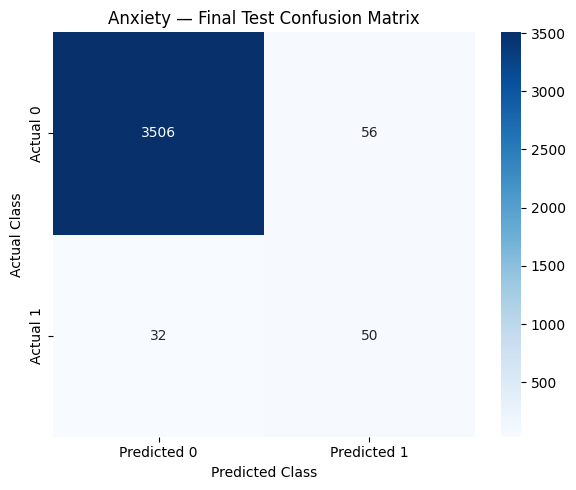

DEPRESSION — FINAL TEST CONFUSION MATRIX
[[3347  100]
 [  96  101]]


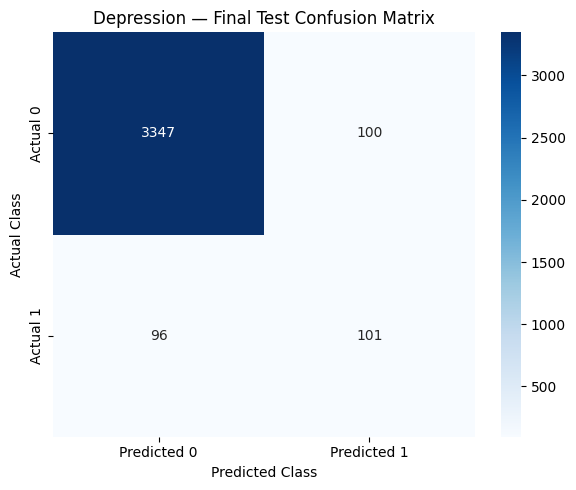

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Final predictions using selected thresholds
anxiety_test_pred_final = (
    anxiety_test_prob >= 0.90
).astype(int)

depression_test_pred_final = (
    depression_test_prob >= 0.90
).astype(int)


# ANXIETY
cm_anxiety = confusion_matrix(
    y_test["anxiety_target"],
    anxiety_test_pred_final
)

print("ANXIETY — FINAL TEST CONFUSION MATRIX")

print(cm_anxiety)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_anxiety,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Anxiety — Final Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()


# DEPRESSION
cm_depression = confusion_matrix(
    y_test["depression_target"],
    depression_test_pred_final
)

print("DEPRESSION — FINAL TEST CONFUSION MATRIX")

print(cm_depression)


plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_depression,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.title("Depression — Final Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

# FINAL ROC-AUC CURVES

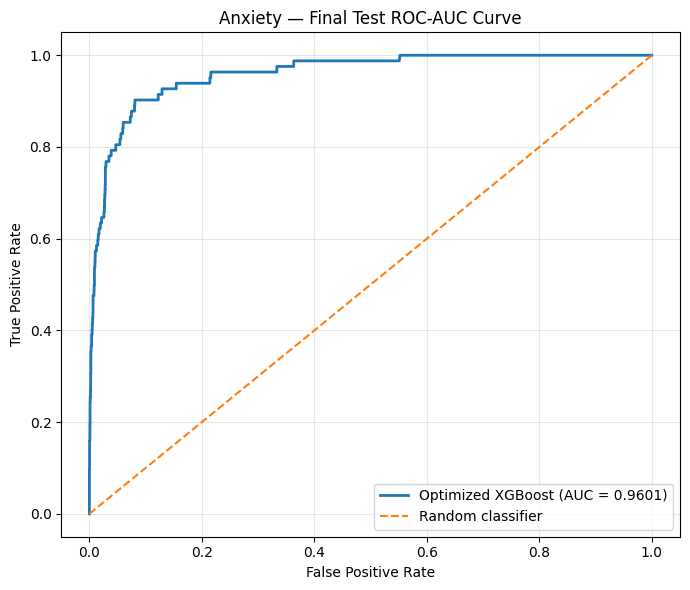

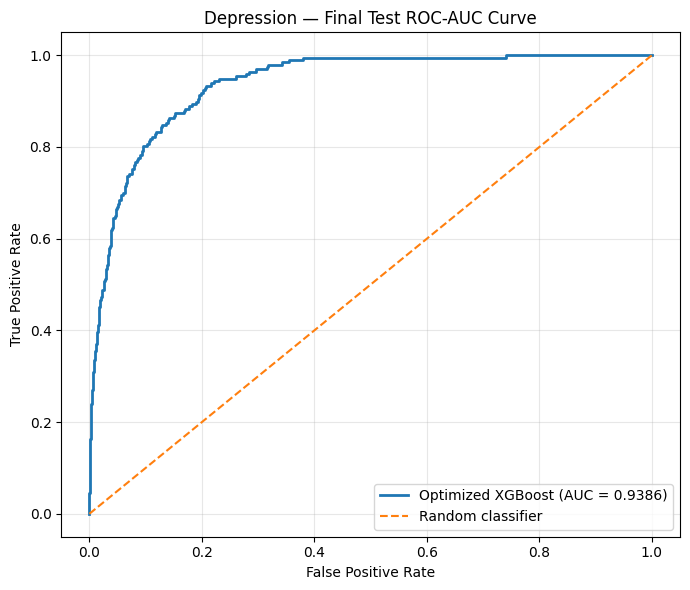

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ANXIETY ROC
fpr_anxiety, tpr_anxiety, _ = roc_curve(
    y_test["anxiety_target"],
    anxiety_test_prob
)

roc_auc_anxiety = auc(
    fpr_anxiety,
    tpr_anxiety
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_anxiety,
    tpr_anxiety,
    linewidth=2,
    label=f"Optimized XGBoost (AUC = {roc_auc_anxiety:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Anxiety — Final Test ROC-AUC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# DEPRESSION ROC
fpr_depression, tpr_depression, _ = roc_curve(
    y_test["depression_target"],
    depression_test_prob
)

roc_auc_depression = auc(
    fpr_depression,
    tpr_depression
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_depression,
    tpr_depression,
    linewidth=2,
    label=f"Optimized XGBoost (AUC = {roc_auc_depression:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Depression — Final Test ROC-AUC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

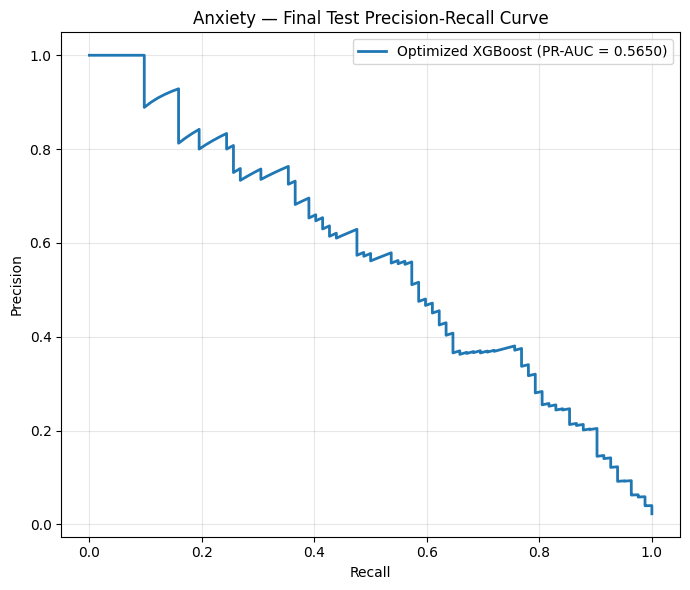

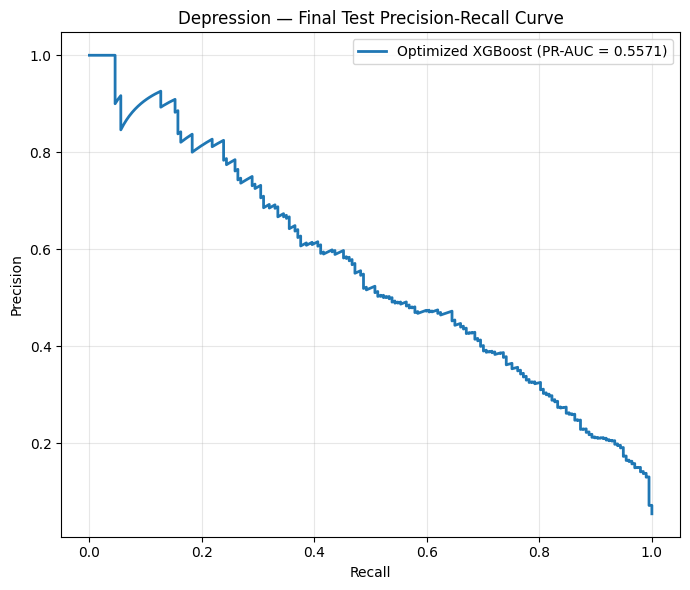

In [ ]:
# FINAL PRECISION-RECALL CURVES
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


# ANXIETY
precision_anxiety, recall_anxiety, _ = precision_recall_curve(
    y_test["anxiety_target"],
    anxiety_test_prob
)

pr_auc_anxiety = average_precision_score(
    y_test["anxiety_target"],
    anxiety_test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_anxiety,
    precision_anxiety,
    linewidth=2,
    label=f"Optimized XGBoost (PR-AUC = {pr_auc_anxiety:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Anxiety — Final Test Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# DEPRESSION
precision_depression, recall_depression, _ = precision_recall_curve(
    y_test["depression_target"],
    depression_test_prob
)

pr_auc_depression = average_precision_score(
    y_test["depression_target"],
    depression_test_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_depression,
    precision_depression,
    linewidth=2,
    label=f"Optimized XGBoost (PR-AUC = {pr_auc_depression:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Depression — Final Test Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# FINAL MODEL COMPARISON — EXTRACTED FROM STORED RESULTS

In [ ]:
print("FINAL TEST MODEL COMPARISON")


# Final decision thresholds used in the final evaluation
FINAL_THRESHOLD = 0.90

# Add optimized XGBoost final test results to all_results
if 'optimized_anxiety_final' in globals() and 'optimized_depression_final' in globals():
    # Ensure these are not duplicated if the cell is run multiple times
    if not any(r.get('Model') == 'Optimized XGBoost' and r.get('Target') == 'Anxiety' for r in all_results):
        all_results.append(optimized_anxiety_final)
    if not any(r.get('Model') == 'Optimized XGBoost' and r.get('Target') == 'Depression' for r in all_results):
        all_results.append(optimized_depression_final)


# Extract TEST results only
test_results = [
    r for r in all_results
    if r.get("Dataset") == "Test"
]


# Keep only the FINAL threshold results
final_test_results = [
    r for r in test_results
    if np.isclose(
        float(r.get("Threshold", 0.5)),
        FINAL_THRESHOLD
    )
]


# Convert extracted results into DataFrame
comparison_df = pd.DataFrame(final_test_results)


# Keep comparison columns
comparison_columns = [
    "Model",
    "Target",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score"
]

# Keep only columns that actually exist
comparison_columns = [
    col for col in comparison_columns
    if col in comparison_df.columns
]

comparison_df = comparison_df[comparison_columns]


# Sort results
comparison_df = comparison_df.sort_values(
    ["Target", "Model"]
).reset_index(drop=True)

# Display
display(comparison_df)

FINAL TEST MODEL COMPARISON


,Model,Target,Threshold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Optimized XGBoost,Anxiety,0.9,0.975851,0.471698,0.609756,0.531915,0.984278,0.960058,0.565043,0.054188
1,Optimized XGBoost,Depression,0.9,0.946213,0.502488,0.512690,0.507538,0.970989,0.938583,0.557147,0.092092


# Check what models are actually stored

In [ ]:
print("MODELS STORED IN all_results")

stored_df = pd.DataFrame(all_results)

display(
    stored_df[
        ["Model", "Dataset", "Target", "Threshold"]
    ].sort_values(
        ["Dataset", "Target", "Model"]
    ).reset_index(drop=True)
)

MODELS STORED IN all_results


,Model,Dataset,Target,Threshold
0,Logistic Regression,Test,Anxiety,NaN
1,Optimized XGBoost,Test,Anxiety,0.9
2,Random Forest,Test,Anxiety,0.5
3,Random Forest,Test,Anxiety,0.5
4,Logistic Regression,Test,Depression,NaN
5,Optimized XGBoost,Test,Depression,0.9
6,Random Forest,Test,Depression,0.5
7,Random Forest,Test,Depression,0.5
8,Logistic Regression,Validation,Anxiety,NaN
9,Random Forest,Validation,Anxiety,0.5


# FINAL MODEL COMPARISON FROM

In [ ]:
print("FINAL TEST MODEL COMPARISON — EXTRACTED FROM all_results")


# Extract all TEST results
test_results = [
    r for r in all_results
    if r.get("Dataset") == "Test"
]

comparison_df = pd.DataFrame(test_results)


# Keep relevant columns
comparison_columns = [
    "Model",
    "Target",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "ROC_AUC",
    "PR_AUC",
    "Brier_Score"
]

# Keep only columns that actually exist
comparison_columns = [
    col for col in comparison_columns
    if col in comparison_df.columns
]

comparison_df = comparison_df[comparison_columns].copy()


# Remove exact duplicate rows
comparison_df = comparison_df.drop_duplicates()


# Sort for easy interpretation
comparison_df = comparison_df.sort_values(
    ["Target", "Model", "Threshold"],
    na_position="last"
).reset_index(drop=True)


# Display extracted results
display(comparison_df)

FINAL TEST MODEL COMPARISON — EXTRACTED FROM all_results


,Model,Target,Threshold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Logistic Regression,Anxiety,NaN,0.915752,0.193460,0.865854,0.316258,NaN,0.957156,0.548276,0.063604
1,Optimized XGBoost,Anxiety,0.9,0.975851,0.471698,0.609756,0.531915,0.984278,0.960058,0.565043,0.054188
2,Random Forest,Anxiety,0.5,0.980516,0.582090,0.475610,0.523490,0.992139,0.956732,0.529502,0.015496
3,Random Forest,Anxiety,0.5,0.952525,0.292237,0.780488,0.425249,0.956485,0.949925,0.563043,0.035807
4,Logistic Regression,Depression,NaN,0.869923,0.275527,0.862944,0.417690,NaN,0.937390,0.566299,0.094254
5,Optimized XGBoost,Depression,0.9,0.946213,0.502488,0.512690,0.507538,0.970989,0.938583,0.557147,0.092092
6,Random Forest,Depression,0.5,0.946762,0.509677,0.401015,0.448864,0.977952,0.925596,0.523519,0.038203
7,Random Forest,Depression,0.5,0.889407,0.301158,0.791878,0.436364,0.894981,0.928208,0.527679,0.079432


# BEST FINAL MODEL PER TARGET

In [ ]:
print("BEST FINAL MODEL PER TARGET")

# Rank primarily by F1, then ROC-AUC, then PR-AUC
best_models = (
    comparison_df
    .sort_values(
        ["Target", "F1", "ROC_AUC", "PR_AUC"],
        ascending=[True, False, False, False]
    )
    .groupby("Target", as_index=False)
    .first()
)

display(best_models)

BEST FINAL MODEL PER TARGET


,Target,Model,Threshold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Anxiety,Optimized XGBoost,0.9,0.975851,0.471698,0.609756,0.531915,0.984278,0.960058,0.565043,0.054188
1,Depression,Optimized XGBoost,0.9,0.946213,0.502488,0.512690,0.507538,0.970989,0.938583,0.557147,0.092092


# Create the final evaluation summary

In [ ]:
print("FINAL SELECTED MODEL PERFORMANCE SUMMARY")

final_summary = best_models[
    [
        "Target",
        "Model",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Specificity",
        "ROC_AUC",
        "PR_AUC",
        "Brier_Score"
    ]
].copy()

# Convert metrics to percentages where appropriate
percentage_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity"
]

for col in percentage_columns:
    final_summary[col] = final_summary[col] * 100

# Round for presentation
final_summary = final_summary.round({
    "Threshold": 3,
    "Accuracy": 2,
    "Precision": 2,
    "Recall": 2,
    "F1": 2,
    "Specificity": 2,
    "ROC_AUC": 4,
    "PR_AUC": 4,
    "Brier_Score": 4
})

display(final_summary)

FINAL SELECTED MODEL PERFORMANCE SUMMARY


,Target,Model,Threshold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC,Brier_Score
0,Anxiety,Optimized XGBoost,0.9,97.59,47.17,60.98,53.19,98.43,0.9601,0.5650,0.0542
1,Depression,Optimized XGBoost,0.9,94.62,50.25,51.27,50.75,97.10,0.9386,0.5571,0.0921


In [ ]:
# SAVE FINAL RESULTS
final_results_path = os.path.join(
    base_path,
    "final_model_test_results.csv"
)

comparison_df.to_csv(
    final_results_path,
    index=False
)

print("FINAL RESULTS SAVED")

print(final_results_path)

FINAL RESULTS SAVED
/content/drive/MyDrive/Anxiety_Dataset/final_model_test_results.csv


# Generate the Final Patient Explanation Report

In [ ]:
# FINAL PATIENT EXPLANATION REPORT
# USING FINAL SELECTED OPTIMIZED XGBOOST MODELS

print("FINAL PATIENT EXPLANATION REPORT")

# PARTICIPANT
participant_idx = 2676

# Final decision thresholds selected using validation data
ANXIETY_THRESHOLD = 0.90
DEPRESSION_THRESHOLD = 0.90


# GET THE PARTICIPANT FEATURES
X_patient = X_test_transformed[participant_idx:participant_idx + 1]


# FINAL MODEL PREDICTIONS
anxiety_probability = xgb_anxiety_optimized.predict_proba(
    X_patient
)[0, 1]

depression_probability = xgb_depression_optimized.predict_proba(
    X_patient
)[0, 1]

# FINAL CLASSIFICATION
anxiety_class = int(
    anxiety_probability >= ANXIETY_THRESHOLD
)

depression_class = int(
    depression_probability >= DEPRESSION_THRESHOLD
)


# PARTICIPANT INFORMATION
print("PARTICIPANT INFORMATION")

print(f"Participant position : {participant_idx}")

# ANXIETY
print("ANXIETY PREDICTION")

print(f"Predicted probability : {anxiety_probability:.4f}")
print(f"Predicted probability : {anxiety_probability * 100:.2f}%")
print(f"Decision threshold    : {ANXIETY_THRESHOLD:.2f}")
print(
    f"Predicted class       : "
    f"{'Positive' if anxiety_class == 1 else 'Negative'}"
)

# DEPRESSION
print("DEPRESSION PREDICTION")

print(f"Predicted probability : {depression_probability:.4f}")
print(f"Predicted probability : {depression_probability * 100:.2f}%")
print(f"Decision threshold    : {DEPRESSION_THRESHOLD:.2f}")
print(
    f"Predicted class       : "
    f"{'Positive' if depression_class == 1 else 'Negative'}"
)

# INTERPRETATION
print("INTERPRETATION")

print("""
These results represent model predictions and should not be
interpreted as a clinical diagnosis.
""")

print(
    f"The final model estimates an anxiety probability of "
    f"{anxiety_probability * 100:.2f}%. "
    f"Using the validation-selected decision threshold of "
    f"{ANXIETY_THRESHOLD:.0%}, the predicted anxiety class is "
    f"{'Positive' if anxiety_class == 1 else 'Negative'}."
)

print(
    f"The final model estimates a depression probability of "
    f"{depression_probability * 100:.2f}%. "
    f"Using the validation-selected decision threshold of "
    f"{DEPRESSION_THRESHOLD:.0%}, the predicted depression class is "
    f"{'Positive' if depression_class == 1 else 'Negative'}."
)

print("REPORT COMPLETED")

FINAL PATIENT EXPLANATION REPORT
PARTICIPANT INFORMATION
Participant position : 2676
ANXIETY PREDICTION
Predicted probability : 0.9954
Predicted probability : 99.54%
Decision threshold    : 0.90
Predicted class       : Positive
DEPRESSION PREDICTION
Predicted probability : 0.9994
Predicted probability : 99.94%
Decision threshold    : 0.90
Predicted class       : Positive
INTERPRETATION

These results represent model predictions and should not be
interpreted as a clinical diagnosis.

The final model estimates an anxiety probability of 99.54%. Using the validation-selected decision threshold of 90%, the predicted anxiety class is Positive.
The final model estimates a depression probability of 99.94%. Using the validation-selected decision threshold of 90%, the predicted depression class is Positive.
REPORT COMPLETED


In [ ]:
print("FINAL DATA SPLIT AUDIT")

print("\nDataset sizes:")
print(f"Training   : {len(X_train)}")
print(f"Validation : {len(X_val)}")
print(f"Testing    : {len(X_test)}")

print("\nTarget distributions:")

print("\nANXIETY")
print("Training:")
print(y_train["anxiety_target"].value_counts(normalize=True))

print("\nValidation:")
print(y_val["anxiety_target"].value_counts(normalize=True))

print("\nTest:")
print(y_test["anxiety_target"].value_counts(normalize=True))

print("\nDEPRESSION")
print("Training:")
print(y_train["depression_target"].value_counts(normalize=True))

print("\nValidation:")
print(y_val["depression_target"].value_counts(normalize=True))

print("\nTest:")
print(y_test["depression_target"].value_counts(normalize=True))

FINAL DATA SPLIT AUDIT

Dataset sizes:
Training   : 17004
Validation : 3644
Testing    : 3644

Target distributions:

ANXIETY
Training:
anxiety_target
0    0.977535
1    0.022465
Name: proportion, dtype: float64

Validation:
anxiety_target
0    0.977497
1    0.022503
Name: proportion, dtype: float64

Test:
anxiety_target
0    0.977497
1    0.022503
Name: proportion, dtype: float64

DEPRESSION
Training:
depression_target
0    0.945836
1    0.054164
Name: proportion, dtype: float64

Validation:
depression_target
0    0.945664
1    0.054336
Name: proportion, dtype: float64

Test:
depression_target
0    0.945939
1    0.054061
Name: proportion, dtype: float64


In [ ]:
# PREPROCESSING LEAKAGE AUDIT

print("PREPROCESSING LEAKAGE AUDIT")


print("\nChecking preprocessing pipeline...")

try:
    print("Pipeline object:", preprocessor)
except NameError:
    print(" preprocessor variable not found.")

PREPROCESSING LEAKAGE AUDIT

Checking preprocessing pipeline...
Pipeline object: ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['age', 'isi_q1', 'isi_q2', 'isi_q3', 'isi_q4',
                                  'isi_q5', 'isi_q6', 'isi_q7', 'pss_q1',
                                  'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5',
                                  'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9',
                                  'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13',
                                  'pss_q14']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'edu', 'smoke', 'drink'])])
